# Regime-Switching Black-Scholes Option Pricing

The notebook estimates Gaussian Hidden Markov Models on S&P 500 log returns, selects the two-state specification as the operational model, and applies a walk-forward regime-switching Black-Scholes PDE to ATM and OTM option pricing.


# 1. Load Dataset & Log-return (PDF Chap.2)

The input file `option_price_atm.csv` contains the cleaned and aligned ATM option dataset used in the thesis. It includes:

- `date`: observation date;
- `spx`: S&P 500 index level;
- `r_3m`: 3-month U.S. Treasury rate;
- `strike`: option strike;
- `expiry_date`: option expiration date;
- `option_price`: SPX call option market price.

The code looks for the file in `dataset/`, in the notebook folder.


## Imports and setup

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import norm
from scipy.linalg import logm
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

try:
    from mpl_bsic.apply_bsic_style import BSIC_COLORS, DEFAULT_COLOR_CYCLE, DEFAULT_TITLE_STYLE
except ImportError:
    # Fallback keeps the notebook executable even when mpl-bsic is not installed.
    BSIC_COLORS = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    DEFAULT_COLOR_CYCLE = plt.rcParams["axes.prop_cycle"]
    DEFAULT_TITLE_STYLE = {}


def apply_bsic_colors_only(fig, ax):
    """Apply the BSIC palette when available, without adding logos or source footers."""
    plt.rcParams["axes.prop_cycle"] = DEFAULT_COLOR_CYCLE
    if isinstance(ax, np.ndarray):
        axes = ax.ravel()
    elif isinstance(ax, (list, tuple)):
        axes = ax
    else:
        axes = [ax]

    for axis in axes:
        axis.set_prop_cycle(DEFAULT_COLOR_CYCLE)
        if axis.get_title():
            axis.set_title(axis.get_title(), **DEFAULT_TITLE_STYLE)
        if BSIC_COLORS:
            for line, color in zip(axis.get_lines(), BSIC_COLORS):
                line.set_color(color)


def find_data_file(filename):
    """Return the first existing location for an uploaded/project data file."""
    candidates = [
        Path("dataset") / filename,
        Path(filename),
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Checked: {candidates}")


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

TRADING_DAYS_PER_YEAR = 252
DATA_FILE = find_data_file("option_price_atm.csv")
PREVIEW_ROWS = 5

print(f"ATM data file: {DATA_FILE}")


ATM data file: dataset/option_price_atm.csv


In [2]:
df_raw = pd.read_csv(
    DATA_FILE,
    sep=";",
    decimal=","
).copy()

print("Raw dataset shape:", df_raw.shape)
print("Raw columns:", list(df_raw.columns))
display(df_raw.head(PREVIEW_ROWS))

Raw dataset shape: (2498, 6)
Raw columns: ['date', 'spx', 'r_3m', 'strike', 'expiry_date', 'option_price']


,date,spx,r_3m,strike,expiry_date,option_price
0,2015-01-05,"2,020.577884",0.000300,"2,020.000000",2015-01-30,35.700000
1,2015-01-06,"2,002.613588",0.000300,"2,005.000000",2015-01-30,34.950000
2,2015-01-07,"2,025.901051",0.000300,"2,025.000000",2015-02-06,36.950000
3,2015-01-08,"2,062.143555",0.000300,"2,060.000000",2015-02-06,33.000000
4,2015-01-09,"2,044.809900",0.000200,"2,045.000000",2015-02-06,32.500000


## Validation and minimal cleaning

The cleaning procedure performs the following steps:

- parse the date column,

- coerce `spx`, `r_3m`, and `option_price` to numeric format,

- drop rows with missing essential values,

- sort observations by date,

- remove duplicate dates if any.

The `option_price` column is kept in the working dataset because it will later be used as the market benchmark against which the regime-switching Black-Scholes PDE price is compared.

In [3]:
required_columns = ["date", "spx", "r_3m", "strike", "expiry_date", "option_price"]
missing_columns = [col for col in required_columns if col not in df_raw.columns]
if missing_columns:
    raise ValueError(f"The dataset is missing the following required columns: {missing_columns}")

df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["expiry_date"] = pd.to_datetime(df["expiry_date"], errors="coerce")

df["spx"] = pd.to_numeric(df["spx"], errors="coerce")
df["r_3m"] = pd.to_numeric(df["r_3m"], errors="coerce")
df["strike"] = pd.to_numeric(df["strike"], errors="coerce")
df["option_price"] = pd.to_numeric(df["option_price"], errors="coerce")

before_rows = len(df)

df = df[["date", "spx", "r_3m", "strike", "expiry_date", "option_price"]].dropna(
    subset=["date", "spx", "r_3m", "strike", "expiry_date", "option_price"]
).copy()

duplicated_dates = int(df["date"].duplicated().sum())
if duplicated_dates > 0:
    df = df.groupby("date", as_index=False)[["spx", "r_3m", "strike", "expiry_date", "option_price"]].last()

df = df.sort_values("date").reset_index(drop=True)

after_rows = len(df)

print(f"Rows before cleaning: {before_rows}")
print(f"Rows after cleaning: {after_rows}")
print(f"Dropped rows: {before_rows - after_rows}")
print(f"Duplicate dates resolved: {duplicated_dates}")

print("\nClean dataset preview:")
display(df.head())

print("\nClean dataset tail:")
display(df.tail())

Rows before cleaning: 2498
Rows after cleaning: 2498
Dropped rows: 0
Duplicate dates resolved: 0

Clean dataset preview:


,date,spx,r_3m,strike,expiry_date,option_price
0,2015-01-05,"2,020.577884",0.000300,"2,020.000000",2015-01-30,35.700000
1,2015-01-06,"2,002.613588",0.000300,"2,005.000000",2015-01-30,34.950000
2,2015-01-07,"2,025.901051",0.000300,"2,025.000000",2015-02-06,36.950000
3,2015-01-08,"2,062.143555",0.000300,"2,060.000000",2015-02-06,33.000000
4,2015-01-09,"2,044.809900",0.000200,"2,045.000000",2015-02-06,32.500000



Clean dataset tail:


,date,spx,r_3m,strike,expiry_date,option_price
2493,2024-12-24,"6,040.035577",0.042800,"6,040.000000",2025-01-23,80.400000
2494,2024-12-26,"6,037.590858",0.042400,"6,040.000000",2025-01-24,84.800000
2495,2024-12-27,"5,970.837644",0.041900,"5,970.000000",2025-01-24,91.900000
2496,2024-12-30,"5,906.935600",0.042300,"5,900.000000",2025-01-29,110.200000
2497,2024-12-31,"5,881.627648",0.042300,"5,890.000000",2025-01-30,96.950000


## Final working dataframe and feature construction

Since the dataset is already aligned, the only remaining construction step is the computation of daily log returns:

$$
R_t = \log\left(\frac{S_t}{S_{t-1}}\right).
$$

The dataframe `final_df` contains the cleaned market data, while `model_df` removes the first missing return and is used for HMM estimation.


In [4]:
df["log_return"] = np.log(df["spx"] / df["spx"].shift(1))

final_df = df.copy()
model_df = final_df.dropna(subset=["log_return"]).reset_index(drop=True)

assert final_df["date"].is_monotonic_increasing
assert final_df["date"].is_unique
assert final_df["spx"].notna().all()
assert final_df["r_3m"].notna().all()

print("Final dataframe summary")
print("-" * 80)
print(f"Rows in final_df: {len(final_df)}")
print(f"Rows in model_df (after dropping the first NaN return): {len(model_df)}")
print(f"Date range: {final_df['date'].min().date()} to {final_df['date'].max().date()}")

print("Head of model_df:")
display(model_df.head())

print("Tail of model_df:")
display(model_df.tail())


Final dataframe summary
--------------------------------------------------------------------------------
Rows in final_df: 2498
Rows in model_df (after dropping the first NaN return): 2497
Date range: 2015-01-05 to 2024-12-31
Head of model_df:


,date,spx,r_3m,strike,expiry_date,option_price,log_return
0,2015-01-06,"2,002.613588",0.000300,"2,005.000000",2015-01-30,34.950000,-0.008930
1,2015-01-07,"2,025.901051",0.000300,"2,025.000000",2015-02-06,36.950000,0.011561
2,2015-01-08,"2,062.143555",0.000300,"2,060.000000",2015-02-06,33.000000,0.017731
3,2015-01-09,"2,044.809900",0.000200,"2,045.000000",2015-02-06,32.500000,-0.008441
4,2015-01-12,"2,028.263822",0.000300,"2,030.000000",2015-02-06,33.250000,-0.008125


Tail of model_df:


,date,spx,r_3m,strike,expiry_date,option_price,log_return
2492,2024-12-24,"6,040.035577",0.042800,"6,040.000000",2025-01-23,80.400000,0.010981
2493,2024-12-26,"6,037.590858",0.042400,"6,040.000000",2025-01-24,84.800000,-0.000405
2494,2024-12-27,"5,970.837644",0.041900,"5,970.000000",2025-01-24,91.900000,-0.011118
2495,2024-12-30,"5,906.935600",0.042300,"5,900.000000",2025-01-29,110.200000,-0.010760
2496,2024-12-31,"5,881.627648",0.042300,"5,890.000000",2025-01-30,96.950000,-0.004294


The final working dataframe contains the variables required for the thesis discussion:

- `date`
- `spx`
- `r_3m`
- `log_return`
- `option_price`


## Exploratory analysis

The figures below provide a first visual check of the data. The rolling volatility uses a 21-trading-day window and is annualized by multiplying the rolling standard deviation of daily log returns by `sqrt(252)`.


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


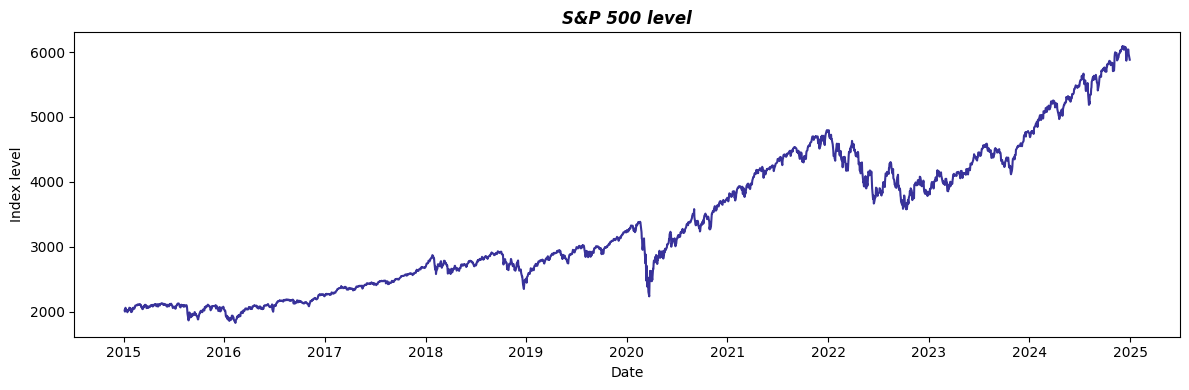

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


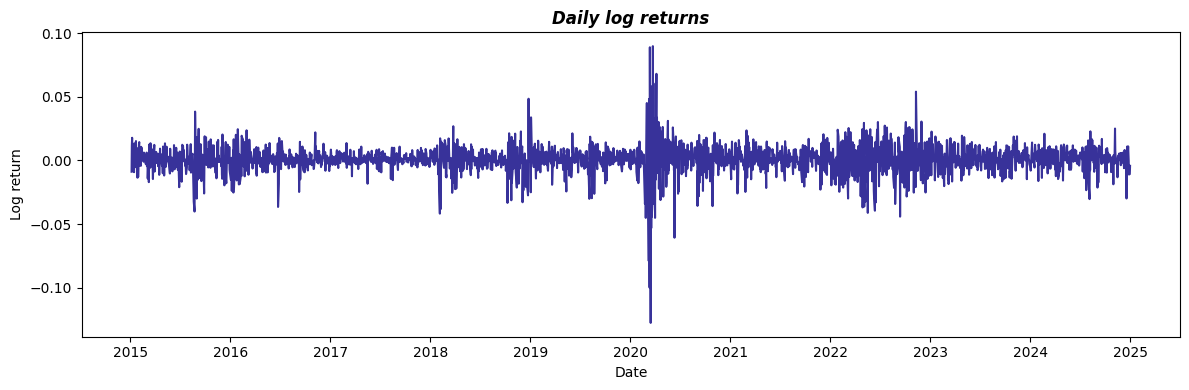

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


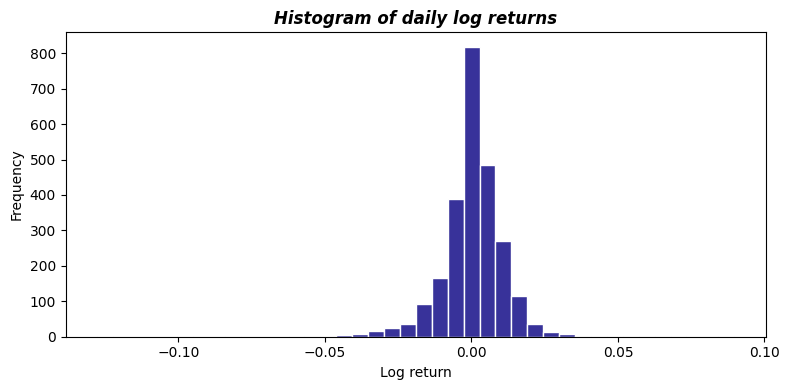

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


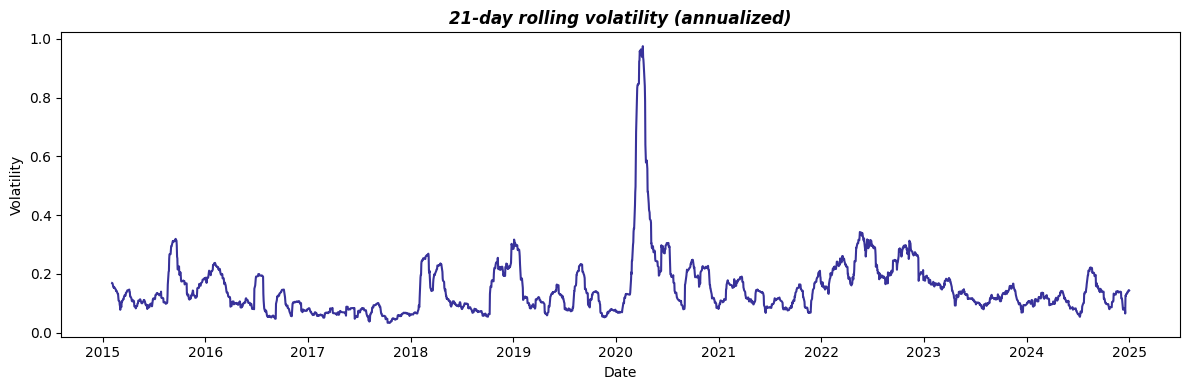

In [5]:
ROLLING_WINDOW = 21

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(final_df["date"], final_df["spx"])
ax.set_title("S&P 500 level")
ax.set_xlabel("Date")
ax.set_ylabel("Index level")
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(model_df["date"], model_df["log_return"])
ax.set_title("Daily log returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(model_df["log_return"], bins=40, color=BSIC_COLORS[0], edgecolor="white")
ax.set_title("Histogram of daily log returns")
ax.set_xlabel("Log return")
ax.set_ylabel("Frequency")
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

rolling_vol_annualized = model_df["log_return"].rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(model_df["date"], rolling_vol_annualized)
ax.set_title(f"{ROLLING_WINDOW}-day rolling volatility (annualized)")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()



# 2. Hidden Markov Models with different numbers of states (PDF Chap.3)

## Parameter estimation

The empirical regime classification is based on daily log returns. Conditional on a latent regime $X_t = i$, returns are assumed to follow

$$
R_t \mid X_t = i \sim \mathcal{N}(\mu_i, \sigma_i^2),
$$

while the latent state follows a discrete Markov chain with transition matrix $P=(p_{ij})$.

Both the two-state and three-state Gaussian HMMs are estimated and compared before selecting the operational specification used in pricing.


In [6]:

def hmm_parameter_count(n_states: int) -> int:
    # Free parameters in a univariate Gaussian HMM:
    # (n_states - 1) for initial state probabilities
    # n_states * (n_states - 1) for the transition matrix
    # n_states means
    # n_states variances
    return n_states ** 2 + 2 * n_states - 1


def sort_result_by_volatility(result):
    order = np.argsort(result["vols"])
    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    sorted_result = dict(result)
    sorted_result["state_order_by_volatility"] = order
    sorted_result["means"] = result["means"][order]
    sorted_result["vols"] = result["vols"][order]
    sorted_result["init_probs"] = result["init_probs"][order]
    sorted_result["transmat"] = result["transmat"][np.ix_(order, order)]
    sorted_result["posterior"] = result["posterior"][:, order]
    sorted_result["states"] = inverse_order[result["states"]]
    return sorted_result


def fit_gaussian_hmm(returns, n_states, random_state=123, n_iter=500, tol=1e-8, n_init=20):
    returns = np.asarray(returns, dtype=float).reshape(-1)
    X = returns.reshape(-1, 1)

    best_model = None
    best_log_likelihood = -np.inf

    for seed in range(random_state, random_state + n_init):
        candidate = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=n_iter,
            tol=tol,
            random_state=seed,
            implementation="scaling",
        )
        candidate.fit(X)
        candidate_log_likelihood = float(candidate.score(X))

        if candidate_log_likelihood > best_log_likelihood:
            best_model = candidate
            best_log_likelihood = candidate_log_likelihood

    means = best_model.means_.reshape(-1)
    covars = np.asarray(best_model.covars_).reshape(n_states, -1)[:, 0]
    posterior = best_model.predict_proba(X)
    states = best_model.predict(X)

    result = {
        "n_states": n_states,
        "log_likelihood": float(best_log_likelihood),
        "init_probs": np.asarray(best_model.startprob_).reshape(-1),
        "transmat": np.asarray(best_model.transmat_),
        "means": means,
        "vols": np.sqrt(np.maximum(covars, 1e-12)),
        "posterior": posterior,
        "states": states,
    }

    result = sort_result_by_volatility(result)
    T = len(returns)
    k = hmm_parameter_count(n_states)
    result["aic"] = 2 * k - 2 * result["log_likelihood"]
    result["bic"] = k * np.log(T) - 2 * result["log_likelihood"]
    result["avg_posterior_confidence"] = float(result["posterior"].max(axis=1).mean())
    result["sample_size"] = T
    return result


def state_summary_table(result):
    transition_diag = np.diag(result["transmat"])
    expected_duration = np.where(np.isclose(1 - transition_diag, 0), np.inf, 1.0 / (1.0 - transition_diag))
    counts = np.bincount(result["states"], minlength=result["n_states"])
    shares = counts / counts.sum()
    summary = pd.DataFrame({
        "state": np.arange(result["n_states"]),
        "mean_daily_return": result["means"],
        "daily_volatility": result["vols"],
        "annualized_volatility": result["vols"] * np.sqrt(TRADING_DAYS_PER_YEAR),
        "count": counts,
        "sample_share": shares,
        "expected_duration_days": expected_duration,
    })
    return summary


def transition_matrix_table(result):
    state_labels = [f"state_{i}" for i in range(result["n_states"])]
    return pd.DataFrame(result["transmat"], index=state_labels, columns=state_labels)


def posterior_preview_table(result, dates, n_rows=5):
    posterior_df = pd.DataFrame(
        result["posterior"],
        columns=[f"posterior_state_{i}" for i in range(result["n_states"])],
    )
    posterior_df.insert(0, "date", pd.Series(dates).reset_index(drop=True))
    posterior_df.insert(1, "most_likely_state", result["states"])
    return posterior_df.head(n_rows)


def plot_hmm_diagnostics(dates, returns, result):
    state_cmap = ListedColormap(BSIC_COLORS[:result["n_states"]])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates, returns, linewidth=0.8, alpha=0.6, label="log return")
    scatter = ax.scatter(dates, returns, c=result["states"], s=12, cmap=state_cmap)
    ax.set_title(f"{result['n_states']}-state HMM: returns coloured by inferred state")
    ax.set_xlabel("Date")
    ax.set_ylabel("Log return")
    handles, _ = scatter.legend_elements()
    ax.legend(handles, [f"State {i}" for i in range(result['n_states'])], loc="upper right")
    apply_bsic_colors_only(fig, ax)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))
    for i in range(result["n_states"]):
        ax.plot(dates, result["posterior"][:, i], linewidth=1.0, label=f"P(state={i} | data)")
    ax.set_title(f"{result['n_states']}-state HMM: posterior state probabilities")
    ax.set_xlabel("Date")
    ax.set_ylabel("Probability")
    ax.set_ylim(-0.02, 1.02)
    apply_bsic_colors_only(fig, ax)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()



In [7]:
HMM_RANDOM_STATE = 123
HMM_MAX_ITER = 500
HMM_TOL = 1e-8
HMM_N_INIT = 20

returns = model_df["log_return"].to_numpy()

hmm_results = {
    n_states: fit_gaussian_hmm(
        returns,
        n_states=n_states,
        random_state=HMM_RANDOM_STATE,
        n_iter=HMM_MAX_ITER,
        tol=HMM_TOL,
        n_init=HMM_N_INIT,
    )
    for n_states in [2, 3]
}

comparison_table = pd.DataFrame([
    {
        "n_states": result["n_states"],  # number of latent regimes in the HMM
        "log_likelihood": result["log_likelihood"],  # higher values indicate better in-sample fit
        "AIC": result["aic"],  # lower values indicate a better fit-complexity tradeoff
        "BIC": result["bic"],  # lower values indicate a better fit-complexity tradeoff, with a stronger penalty than AIC
        "avg_posterior_confidence": result["avg_posterior_confidence"],  # values closer to 1 mean clearer regime classification
        "smallest_regime_share": state_summary_table(result)["sample_share"].min(),  # very small values may indicate a negligible or unstable regime
    }
    for result in hmm_results.values()
]).sort_values("n_states").reset_index(drop=True)

print("Model comparison table")
display(comparison_table)

for n_states, result in hmm_results.items():
    print("\n" + "=" * 80)
    print(f"{n_states}-state Gaussian HMM estimated with hmmlearn")
    print(f"Log-likelihood: {result['log_likelihood']:.6f}")
    print(f"AIC: {result['aic']:.6f}")
    print(f"BIC: {result['bic']:.6f}")
    print("State summary (states are sorted from low to high volatility):")
    display(state_summary_table(result))
    print("Transition matrix:")
    display(transition_matrix_table(result))
    print("Posterior probability preview:")
    display(posterior_preview_table(result, model_df["date"]))

Model is not converging.  Current: 7650.505037929486 is not greater than 7650.532884889844. Delta is -0.027846960358147044
Model is not converging.  Current: 8191.6306272288675 is not greater than 8191.633984048416. Delta is -0.003356819548571366
Model is not converging.  Current: 8295.412249514053 is not greater than 8295.453371484817. Delta is -0.041121970763924764
Model is not converging.  Current: 8193.36590103589 is not greater than 8193.377812814913. Delta is -0.011911779023648705
Model is not converging.  Current: 8300.629721999994 is not greater than 8300.639970249033. Delta is -0.010248249038340873
Model is not converging.  Current: 8193.541050573622 is not greater than 8193.54618136377. Delta is -0.005130790148541564
Model is not converging.  Current: 8300.566321129469 is not greater than 8300.574220155619. Delta is -0.007899026149971178
Model is not converging.  Current: 8193.6105288441 is not greater than 8193.625766598432. Delta is -0.015237754332702025
Model is not conver

Model comparison table


,n_states,log_likelihood,AIC,BIC,avg_posterior_confidence,smallest_regime_share
0,2,"8,191.643441","-16,369.286883","-16,328.526966",0.951229,0.237085
1,3,"8,301.254700","-16,574.509401","-16,492.989567",0.953264,0.012415



2-state Gaussian HMM estimated with hmmlearn
Log-likelihood: 8191.643441
AIC: -16369.286883
BIC: -16328.526966
State summary (states are sorted from low to high volatility):


,state,mean_daily_return,daily_volatility,annualized_volatility,count,sample_share,expected_duration_days
0,0,0.001007,0.007143,0.113388,1905,0.762915,74.823545
1,1,-0.001562,0.020511,0.325608,592,0.237085,21.914261


...

,state,mean_daily_return,daily_volatility,annualized_volatility,count,sample_share,expected_duration_days
0,0,0.001032,0.006659,0.105713,1741,0.697237,76.648596
1,1,-0.000619,0.015067,0.239186,725,0.290348,33.914047
2,2,-0.006119,0.052941,0.840410,31,0.012415,30.604982


Transition matrix:


,state_0,state_1,state_2
state_0,0.986953,0.012386,0.000660
state_1,0.029479,0.970514,0.000008
state_2,0.000000,0.032674,0.967326


Posterior probability preview:


,date,most_likely_state,posterior_state_0,posterior_state_1,posterior_state_2
0,2015-01-06,1,0.000000,1.000000,0.000000
1,2015-01-07,1,0.008223,0.991777,0.000000
2,2015-01-08,1,0.016503,0.983497,0.000001
3,2015-01-09,1,0.057433,0.942567,0.000000
4,2015-01-12,1,0.099546,0.900454,0.000001


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


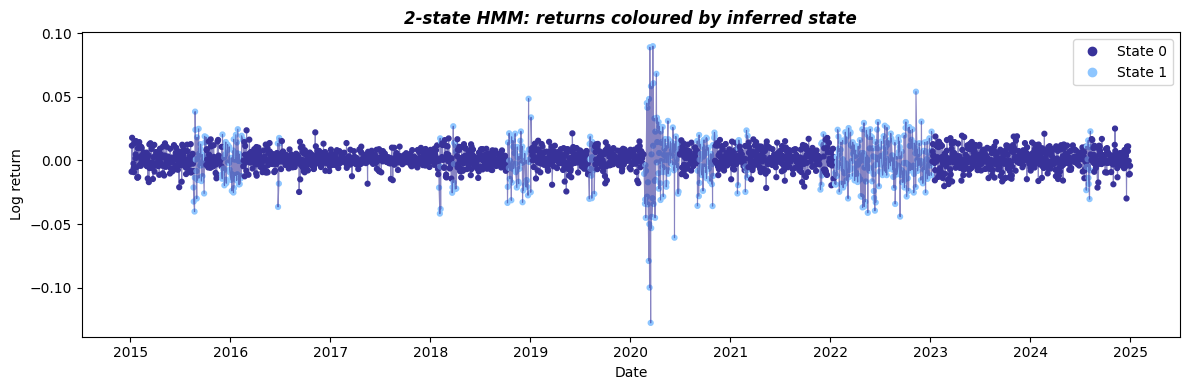

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


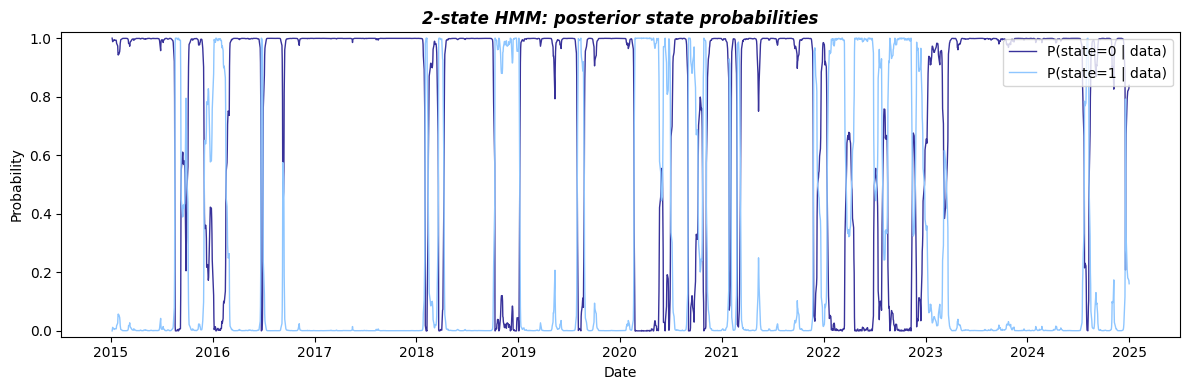

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


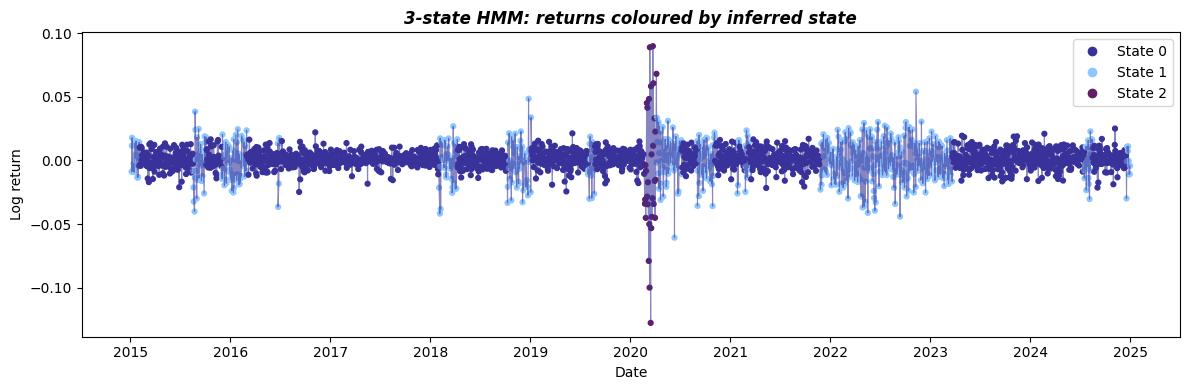

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


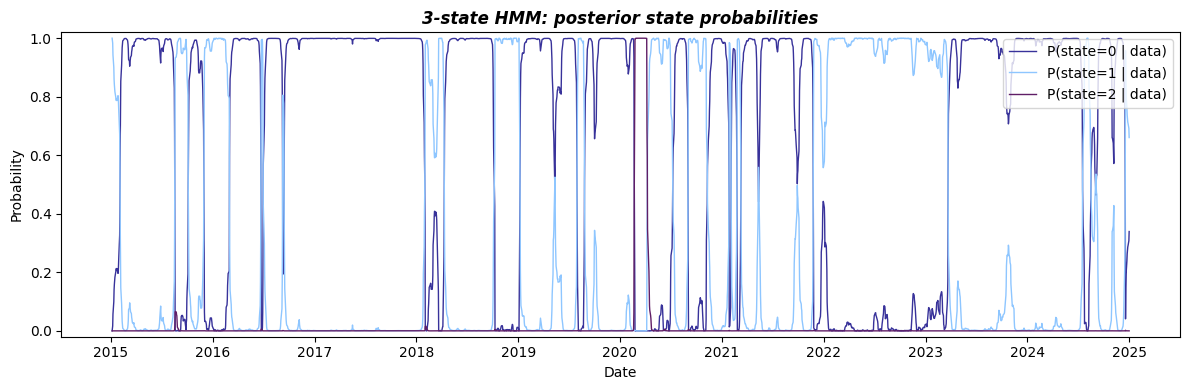

In [8]:

for n_states, result in hmm_results.items():
    plot_hmm_diagnostics(model_df["date"], model_df["log_return"], result)


## Regime interpretation

The hidden states are relabelled by increasing volatility. This gives economically meaningful labels:

- **2 states**: low-volatility, high-volatility;
- **3 states**: low-volatility, medium-volatility, high-volatility.

The labels are based primarily on volatility rather than on the regime-dependent mean returns, because daily mean estimates are typically much noisier than daily volatility estimates.

Although a 3-state model may be statistically preferred on the basis of information criteria, a 2-state model may still remain valuable as a more tractable benchmark for regime-switching option pricing.

,state,regime_label,mean_daily_return,daily_volatility,annualized_volatility,count,sample_share,expected_duration_days
0,0,low-volatility,0.001007,0.007143,0.113388,1905,0.762915,74.823545
1,1,high-volatility,-0.001562,0.020511,0.325608,592,0.237085,21.914261


Preview of model_df with regime labels:


,date,spx,r_3m,strike,expiry_date,option_price,log_return,preferred_state,preferred_regime_label,posterior_low_volatility,posterior_high_volatility
0,2015-01-06,"2,002.613588",0.000300,"2,005.000000",2015-01-30,34.950000,-0.008930,0,low-volatility,1.000000,0.000000
1,2015-01-07,"2,025.901051",0.000300,"2,025.000000",2015-02-06,36.950000,0.011561,0,low-volatility,0.994079,0.005921
2,2015-01-08,"2,062.143555",0.000300,"2,060.000000",2015-02-06,33.000000,0.017731,0,low-volatility,0.988002,0.011998
3,2015-01-09,"2,044.809900",0.000200,"2,045.000000",2015-02-06,32.500000,-0.008441,0,low-volatility,0.990569,0.009431
4,2015-01-12,"2,028.263822",0.000300,"2,030.000000",2015-02-06,33.250000,-0.008125,0,low-volatility,0.992923,0.007077


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


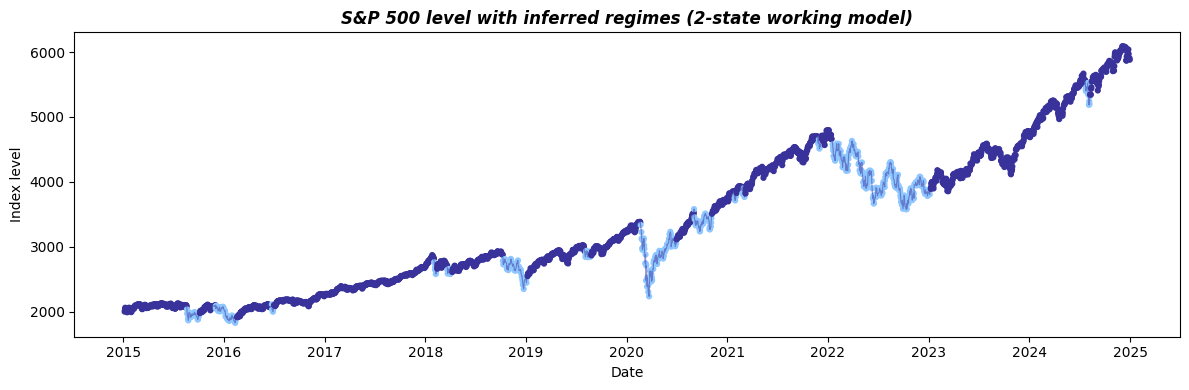

In [9]:
preferred_states = 2
# Choose the working HMM specification directly: set to 2 or 3.

preferred_result = hmm_results[preferred_states]


def volatility_labels(n_states):
    if n_states == 2:
        return ["low-volatility", "high-volatility"]
    if n_states == 3:
        return ["low-volatility", "medium-volatility", "high-volatility"]
    return [f"regime_{i}" for i in range(n_states)]


preferred_summary = state_summary_table(preferred_result).copy()
preferred_summary["regime_label"] = volatility_labels(preferred_states)
preferred_summary = preferred_summary[
    [
        "state",
        "regime_label",
        "mean_daily_return",
        "daily_volatility",
        "annualized_volatility",
        "count",
        "sample_share",
        "expected_duration_days",
    ]
]

display(preferred_summary)

regime_labels = dict(zip(preferred_summary["state"], preferred_summary["regime_label"]))

model_df["preferred_state"] = preferred_result["states"]
model_df["preferred_regime_label"] = model_df["preferred_state"].map(regime_labels)

for state, label in regime_labels.items():
    safe_label = label.replace("-", "_").replace(" ", "_")
    model_df[f"posterior_{safe_label}"] = preferred_result["posterior"][:, state]

print("Preview of model_df with regime labels:")
display(model_df.head())

fig, ax = plt.subplots(figsize=(12, 4))
preferred_cmap = ListedColormap(BSIC_COLORS[:preferred_states])
ax.scatter(model_df["date"], model_df["spx"], c=model_df["preferred_state"], s=12, cmap=preferred_cmap)
ax.plot(model_df["date"], model_df["spx"], linewidth=0.8, alpha=0.5)
ax.set_title(f"S&P 500 level with inferred regimes ({preferred_states}-state working model)")
ax.set_xlabel("Date")
ax.set_ylabel("Index level")
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()




## Transition intensities

If $P$ denotes the estimated one-step transition matrix from daily data and $\Delta t = 1/252$ years, a continuous-time approximation of the generator matrix is

$$
Q \approx \frac{1}{\Delta t} \log(P).
$$

For a 2-state model,

$$
Q = \begin{pmatrix}
-\lambda_{12} & \lambda_{12} \\
\lambda_{21} & -\lambda_{21}
\end{pmatrix},
$$

so the off-diagonal elements are the annualized switching intensities.

For a 3-state model the same matrix-logarithm idea generalizes directly, but numerical estimates may sometimes require a constrained projection if tiny negative off-diagonal terms appear because of sampling noise or numerical approximation.


In [10]:

def discrete_transition_to_generator(transition_matrix, dt_years=1 / TRADING_DAYS_PER_YEAR):
    generator = np.real_if_close(logm(transition_matrix) / dt_years)
    generator = np.asarray(generator, dtype=float)
    return generator


def labeled_matrix(matrix, labels):
    return pd.DataFrame(matrix, index=labels, columns=labels)

preferred_labels = preferred_summary["regime_label"].tolist()
preferred_Q = discrete_transition_to_generator(preferred_result["transmat"])

print(f"Continuous-time approximation for the {preferred_states}-state working model")
display(labeled_matrix(preferred_Q, preferred_labels))
print("Row sums (should be numerically close to zero):")
print(labeled_matrix(preferred_Q, preferred_labels).sum(axis=1))

if preferred_states == 2:
    print("\nApproximate annualized switching intensities:")
    print(f"lambda_12 = {preferred_Q[0, 1]:.6f}")
    print(f"lambda_21 = {preferred_Q[1, 0]:.6f}")
else:
    off_diagonal_mask = ~np.eye(preferred_Q.shape[0], dtype=bool)
    problematic_entries = preferred_Q[off_diagonal_mask] < -1e-8
    if problematic_entries.any():
        print(
            "Some off-diagonal entries are slightly negative. "
            "This can happen when a discrete-time estimate is converted to a continuous-time generator by matrix logarithm. "
            "A constrained projection or regularisation step can be added before solving the PDE system."
        )
    print("\nBecause a 2-state specification is often used as the pricing benchmark, its generator is also shown below:")
    benchmark_2state_result = hmm_results[2]
    benchmark_2state_labels = volatility_labels(2)
    benchmark_2state_Q = discrete_transition_to_generator(benchmark_2state_result["transmat"])
    display(labeled_matrix(benchmark_2state_Q, benchmark_2state_labels))


Continuous-time approximation for the 2-state working model


,low-volatility,high-volatility
low-volatility,-3.471362,3.471362
high-volatility,11.852537,-11.852537


Row sums (should be numerically close to zero):
low-volatility    -0.000000
high-volatility    0.000000
dtype: float64

Approximate annualized switching intensities:
lambda_12 = 3.471362
lambda_21 = 11.852537


# 3. Walk-forward regime-switching option pricing (PDF Chap.4)

The full-sample HMM estimates above are useful for describing the historical behavior of SPX returns. However, full-sample regime probabilities, especially posterior probabilities obtained from the entire sample, are not appropriate for option pricing because they may use information from the future. In particular, smoothed or full-sample `predict_proba` probabilities can introduce look-ahead bias.

For pricing, this section uses a walk-forward design. The HMM is retrained monthly using only data available up to the previous month-end. During each pricing month, the HMM parameters are kept fixed and regime probabilities are updated sequentially. For strict no-look-ahead option pricing on date $t$, the model uses the one-step-ahead predicted probability

$$
\tilde p_t = p_{t-1} P,
$$

where $p_{t-1}$ is the filtered probability after observing returns up to date $t-1$, and $P$ is the estimated discrete-time transition matrix.

This ensures that the same-day return is not used to price the same-day option quote.

In [11]:
# ---------------------------------------------------------------------
# Helper functions for HMM filtering without look-ahead
# ---------------------------------------------------------------------

def _as_2d_returns(return_series):
    """
    Convert a pandas Series or array of returns into the 2D shape expected by hmmlearn.
    """
    arr = np.asarray(return_series, dtype=float)
    arr = arr[np.isfinite(arr)]
    return arr.reshape(-1, 1)


def _normalize_prob_vector(p, eps=1e-15):
    """
    Normalize a probability vector safely.
    """
    p = np.asarray(p, dtype=float)
    p = np.maximum(p, eps)
    return p / p.sum()


def _gaussian_emission_likelihood(x, means, variances, eps=1e-12):
    """
    Gaussian emission likelihood for each HMM state.
    """
    means = np.asarray(means, dtype=float).reshape(-1)
    variances = np.asarray(variances, dtype=float).reshape(-1)
    std = np.sqrt(np.maximum(variances, eps))
    return norm.pdf(x, loc=means, scale=std)


def filtered_probabilities_no_lookahead(model, returns, initial_prob=None):
    """
    Sequentially compute filtered probabilities for a fitted GaussianHMM.

    Parameters
    ----------
    model : hmmlearn.hmm.GaussianHMM
        Fitted Gaussian HMM.
    returns : array-like
        Return observations in chronological order.
    initial_prob : array-like or None
        Initial probability vector. If None, model.startprob_ is used.

    Returns
    -------
    filtered_probs : np.ndarray
        Array of shape (n_obs, n_states). Row t is P(z_t | r_1, ..., r_t).
    predicted_probs : np.ndarray
        Array of shape (n_obs, n_states). Row t is P(z_t | r_1, ..., r_{t-1}).
        The first row uses the initial probability.
    """
    x = np.asarray(returns, dtype=float)
    x = x[np.isfinite(x)]

    n_obs = len(x)
    n_states = model.n_components

    if n_obs == 0:
        return np.empty((0, n_states)), np.empty((0, n_states))

    P = np.asarray(model.transmat_, dtype=float)
    means = np.asarray(model.means_, dtype=float).reshape(-1)
    variances = np.asarray(model.covars_, dtype=float).reshape(n_states, -1)[:, 0]

    if initial_prob is None:
        p_prev_filt = _normalize_prob_vector(model.startprob_)
    else:
        p_prev_filt = _normalize_prob_vector(initial_prob)

    filtered_probs = np.zeros((n_obs, n_states))
    predicted_probs = np.zeros((n_obs, n_states))

    for i, obs in enumerate(x):
        if i == 0:
            p_pred = p_prev_filt.copy()
        else:
            p_pred = _normalize_prob_vector(p_prev_filt @ P)

        likelihood = _gaussian_emission_likelihood(obs, means, variances)
        p_filt = _normalize_prob_vector(p_pred * likelihood)

        predicted_probs[i, :] = p_pred
        filtered_probs[i, :] = p_filt

        p_prev_filt = p_filt

    return filtered_probs, predicted_probs

def filtered_probabilities_no_lookahead_params(
    returns,
    startprob,
    transmat,
    means,
    variances,
):
    """
    Sequential filtering using explicitly supplied HMM parameters.

    This is useful after sorting states by volatility without mutating the
    fitted hmmlearn model object.
    """
    x = np.asarray(returns, dtype=float)
    x = x[np.isfinite(x)]

    startprob = _normalize_prob_vector(startprob)
    transmat = np.asarray(transmat, dtype=float)
    means = np.asarray(means, dtype=float).reshape(-1)
    variances = np.asarray(variances, dtype=float).reshape(-1)

    n_obs = len(x)
    n_states = len(startprob)

    filtered_probs = np.zeros((n_obs, n_states))
    predicted_probs = np.zeros((n_obs, n_states))

    p_prev_filt = startprob.copy()

    for i, obs in enumerate(x):
        if i == 0:
            p_pred = p_prev_filt.copy()
        else:
            p_pred = one_step_ahead_predicted_probability(p_prev_filt, transmat)

        likelihood = _gaussian_emission_likelihood(obs, means, variances)
        p_filt = _normalize_prob_vector(p_pred * likelihood)

        predicted_probs[i, :] = p_pred
        filtered_probs[i, :] = p_filt

        p_prev_filt = p_filt

    return filtered_probs, predicted_probs

def one_step_ahead_predicted_probability(filtered_prob, transition_matrix):
    """
    Compute one-step-ahead predicted probabilities p_tilde = p_filtered @ P.
    """
    filtered_prob = _normalize_prob_vector(filtered_prob)
    P = np.asarray(transition_matrix, dtype=float)
    return _normalize_prob_vector(filtered_prob @ P)

### Monthly walk-forward HMM estimation

At the beginning of each calendar month in the pricing period, the two-state Gaussian HMM is re-estimated using only information available up to the previous month-end. The baseline configuration uses an expanding window starting in 2015. The fitted states are sorted by increasing volatility, so state 0 is always interpreted as the low-volatility regime and state 1 as the high-volatility regime.

This timing convention avoids look-ahead bias: option prices in month \(m\) use HMM parameters estimated before month \(m\) begins, and same-day returns are not used to form the pricing-date regime probabilities.

In [12]:
# ================================================================
# Global walk-forward HMM / RSBS configuration
# ================================================================

N_COMPONENTS = 2  # choose 2 or 3

WF_START_DATE = "2020-01-01"
WF_END_DATE = "2024-12-31"
INITIAL_TRAIN_START = "2015-01-05"

WINDOW_TYPE = "expanding"  # choose "rolling" or "expanding"
ROLLING_WINDOW = 5
ROLLING_WINDOW_UNIT = "years"
MIN_TRAIN_OBS = 30

HMM_RANDOM_STATE_WF = 42

In [13]:
# ---------------------------------------------------------------------
# Monthly walk-forward HMM estimation
# ---------------------------------------------------------------------

def fit_walkforward_hmm_snapshot(
    train_df,
    return_col="log_return",
    n_components=2,
    trading_days_per_year=TRADING_DAYS_PER_YEAR,
    random_state=42,
    n_iter=1000,
    tol=1e-6,
    min_obs=252,
):
    """
    Fit a Gaussian HMM on a training window and return all quantities
    sorted from low volatility to high volatility.

    Works with both 2-state and 3-state specifications.
    """
    train_returns = pd.to_numeric(train_df[return_col], errors="coerce").dropna()

    if len(train_returns) < min_obs:
        raise ValueError(f"Not enough observations to fit HMM: {len(train_returns)} < {min_obs}")

    X_train = train_returns.values.reshape(-1, 1)

    model = GaussianHMM(
        n_components=n_components,
        covariance_type="diag",
        n_iter=n_iter,
        tol=tol,
        random_state=random_state,
        implementation="scaling",
    )

    model.fit(X_train)

    raw_means = np.asarray(model.means_, dtype=float).reshape(n_components)
    raw_vars = np.asarray(model.covars_, dtype=float).reshape(n_components, -1)[:, 0]
    raw_sigmas = np.sqrt(np.maximum(raw_vars, 1e-12))

    order = np.argsort(raw_sigmas)

    means = raw_means[order]
    daily_vars = raw_vars[order]
    daily_sigmas = raw_sigmas[order]
    annual_sigmas = daily_sigmas * np.sqrt(trading_days_per_year)

    startprob = np.asarray(model.startprob_, dtype=float)[order]
    startprob = _normalize_prob_vector(startprob)

    P = np.asarray(model.transmat_, dtype=float)[np.ix_(order, order)]
    P = np.maximum(P, 1e-12)
    P = P / P.sum(axis=1, keepdims=True)

    Q_raw = logm(P) * trading_days_per_year
    Q_raw = np.real_if_close(Q_raw).real
    Q_raw = np.asarray(Q_raw, dtype=float)

    if Q_raw.shape != (n_components, n_components) or not np.all(np.isfinite(Q_raw)):
        raise ValueError("Continuous-time generator could not be computed.")

    # Clean generator: off-diagonal non-negative, diagonal = minus row sum
    Q = Q_raw.copy()

    for i in range(n_components):
        for j in range(n_components):
            if i != j:
                Q[i, j] = max(float(Q[i, j]), 0.0)

    for i in range(n_components):
        Q[i, i] = -np.sum(Q[i, np.arange(n_components) != i])

    filtered_probs, predicted_probs = filtered_probabilities_no_lookahead_params(
        returns=train_returns.values,
        startprob=startprob,
        transmat=P,
        means=means,
        variances=daily_vars,
    )

    latest_filtered_prob = filtered_probs[-1, :]

    result = {
        "model": model,
        "n_components": n_components,
        "state_order_by_volatility": order,
        "means": means,
        "variances": daily_vars,
        "startprob": startprob,
        "annual_sigmas": annual_sigmas,
        "daily_sigmas": daily_sigmas,
        "P": P,
        "Q": Q,
        "latest_filtered_prob": latest_filtered_prob,
        "latest_predicted_prob": one_step_ahead_predicted_probability(latest_filtered_prob, P),
        "n_train_obs": len(train_returns),
        "train_start": train_df["date"].min(),
        "train_end": train_df["date"].max(),
        "converged": getattr(getattr(model, "monitor_", None), "converged", np.nan),
        "log_likelihood": float(model.score(X_train)),
    }

    # Human-readable aliases
    result["sigma_low"] = float(annual_sigmas[0])
    result["daily_sigma_low"] = float(daily_sigmas[0])

    if n_components == 2:
        result["sigma_high"] = float(annual_sigmas[1])
        result["daily_sigma_high"] = float(daily_sigmas[1])
        result["q_lh"] = float(Q[0, 1])
        result["q_hl"] = float(Q[1, 0])

    elif n_components == 3:
        result["sigma_medium"] = float(annual_sigmas[1])
        result["sigma_high"] = float(annual_sigmas[2])

        result["daily_sigma_medium"] = float(daily_sigmas[1])
        result["daily_sigma_high"] = float(daily_sigmas[2])

        result["q_lm"] = float(Q[0, 1])
        result["q_lh"] = float(Q[0, 2])
        result["q_ml"] = float(Q[1, 0])
        result["q_mh"] = float(Q[1, 2])
        result["q_hl"] = float(Q[2, 0])
        result["q_hm"] = float(Q[2, 1])

    else:
        raise ValueError("This notebook currently supports only n_components=2 or n_components=3.")

    return result

def compute_training_start_date(
    month_start,
    window_type="expanding",
    initial_train_start="2015-01-05",
    rolling_window=5,
    rolling_window_unit="years",
    df=None,
    date_col="date",
):
    """
    Compute the start date of the training window.

    Parameters
    ----------
    month_start : pd.Timestamp
        First day of the pricing month.
    window_type : {"expanding", "rolling"}
        Expanding uses all available data from initial_train_start.
        Rolling uses a finite lookback window.
    initial_train_start : str or pd.Timestamp
        Start date for expanding windows.
    rolling_window : int
        Length of the rolling window.
    rolling_window_unit : {"days", "months", "years", "observations", "trading_days"}
        Unit of the rolling window.
        - "days": calendar days
        - "months": calendar months
        - "years": calendar years
        - "observations" or "trading_days": last N available return observations
    df : pd.DataFrame
        Required only if rolling_window_unit is "observations" or "trading_days".
    date_col : str
        Date column name.

    Returns
    -------
    train_start : pd.Timestamp
    """
    month_start = pd.Timestamp(month_start)
    initial_train_start = pd.Timestamp(initial_train_start)

    if window_type == "expanding":
        return initial_train_start

    if window_type != "rolling":
        raise ValueError("window_type must be either 'expanding' or 'rolling'.")

    rolling_window_unit = str(rolling_window_unit).lower().strip()

    if rolling_window <= 0:
        raise ValueError("rolling_window must be positive.")

    if rolling_window_unit in ["day", "days", "calendar_days"]:
        return month_start - pd.DateOffset(days=rolling_window)

    if rolling_window_unit in ["month", "months", "calendar_months"]:
        return month_start - pd.DateOffset(months=rolling_window)

    if rolling_window_unit in ["year", "years", "calendar_years"]:
        return month_start - pd.DateOffset(years=rolling_window)

    if rolling_window_unit in ["observation", "observations", "trading_day", "trading_days"]:
        if df is None:
            raise ValueError(
                "df must be provided when rolling_window_unit is 'observations' or 'trading_days'."
            )

        train_end = month_start - pd.Timedelta(days=1)

        available_train_dates = (
            df.loc[df[date_col] <= train_end, date_col]
            .dropna()
            .sort_values()
            .drop_duplicates()
            .reset_index(drop=True)
        )

        if len(available_train_dates) == 0:
            return initial_train_start

        if len(available_train_dates) < rolling_window:
            return available_train_dates.iloc[0]

        return available_train_dates.iloc[-rolling_window]

    raise ValueError(
        "rolling_window_unit must be one of: "
        "'days', 'months', 'years', 'observations', 'trading_days'."
    )

def monthly_walkforward_regime_estimates(
    model_df,
    start_date="2020-01-01",
    end_date="2024-12-31",
    initial_train_start="2015-01-05",
    date_col="date",
    return_col="log_return",
    n_components=2,
    min_train_obs=252,
    random_state=42,
    verbose=True,
    window_type="expanding",
    rolling_window=5,
    rolling_window_unit="years",
):
    """
    Monthly walk-forward HMM estimation and daily filtering.

    Works with both 2-state and 3-state HMMs.
    """
    df = model_df.copy()

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[return_col] = pd.to_numeric(df[return_col], errors="coerce")

    df = (
        df.dropna(subset=[date_col, return_col])
        .sort_values(date_col)
        .reset_index(drop=True)
    )

    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    initial_train_start = pd.Timestamp(initial_train_start)

    if window_type not in ["expanding", "rolling"]:
        raise ValueError("window_type must be either 'expanding' or 'rolling'.")

    if n_components not in [2, 3]:
        raise ValueError("n_components must be either 2 or 3.")

    if df.empty:
        raise ValueError("After cleaning, model_df has no valid date/log_return rows.")

    available_start = max(start_date, df[date_col].min())
    available_end = min(end_date, df[date_col].max())

    if available_start > available_end:
        raise ValueError(
            "No overlap between requested pricing period and model_df dates. "
            f"Requested {start_date.date()} to {end_date.date()}, "
            f"available {df[date_col].min().date()} to {df[date_col].max().date()}."
        )

    if verbose:
        print("Cleaned model_df date range:", df[date_col].min(), "to", df[date_col].max())
        print("Walk-forward pricing range:", available_start, "to", available_end)
        print("Cleaned model_df rows:", len(df))
        print("Training window type:", window_type)
        print("Number of HMM states:", n_components)

        if window_type == "rolling":
            print("Rolling training window:", rolling_window, rolling_window_unit)

    month_starts = pd.date_range(
        available_start.to_period("M").start_time,
        available_end.to_period("M").start_time,
        freq="MS",
    )

    all_rows = []
    snapshots = {}
    failed_months = []

    for month_start in month_starts:
        month_end = month_start + pd.offsets.MonthEnd(0)
        train_end = month_start - pd.Timedelta(days=1)

        train_start = compute_training_start_date(
            month_start=month_start,
            window_type=window_type,
            initial_train_start=initial_train_start,
            rolling_window=rolling_window,
            rolling_window_unit=rolling_window_unit,
            df=df,
            date_col=date_col,
        )

        train_df = df.loc[
            (df[date_col] >= train_start)
            & (df[date_col] <= train_end)
        ].copy()

        month_df = df.loc[
            (df[date_col] >= month_start)
            & (df[date_col] <= month_end)
            & (df[date_col] >= available_start)
            & (df[date_col] <= available_end)
        ].copy()

        if month_df.empty:
            failed_months.append(
                {
                    "month_start": month_start,
                    "reason": "No observations in pricing month",
                    "train_start": train_start,
                    "train_end": train_end,
                    "n_train_obs": len(train_df),
                    "n_month_obs": len(month_df),
                    "window_type": window_type,
                    "rolling_window": rolling_window if window_type == "rolling" else np.nan,
                    "rolling_window_unit": rolling_window_unit if window_type == "rolling" else np.nan,
                    "n_components": n_components,
                }
            )
            continue

        if len(train_df) < min_train_obs:
            failed_months.append(
                {
                    "month_start": month_start,
                    "reason": f"Too few training observations: {len(train_df)} < {min_train_obs}",
                    "train_start": train_start,
                    "train_end": train_end,
                    "n_train_obs": len(train_df),
                    "n_month_obs": len(month_df),
                    "window_type": window_type,
                    "rolling_window": rolling_window if window_type == "rolling" else np.nan,
                    "rolling_window_unit": rolling_window_unit if window_type == "rolling" else np.nan,
                    "n_components": n_components,
                }
            )
            continue

        try:
            snapshot = fit_walkforward_hmm_snapshot(
                train_df=train_df,
                return_col=return_col,
                n_components=n_components,
                random_state=random_state,
                min_obs=min_train_obs,
            )

        except Exception as exc:
            failed_months.append(
                {
                    "month_start": month_start,
                    "reason": f"HMM fit failed: {repr(exc)}",
                    "train_start": train_start,
                    "train_end": train_end,
                    "n_train_obs": len(train_df),
                    "n_month_obs": len(month_df),
                    "window_type": window_type,
                    "rolling_window": rolling_window if window_type == "rolling" else np.nan,
                    "rolling_window_unit": rolling_window_unit if window_type == "rolling" else np.nan,
                    "n_components": n_components,
                }
            )

            if verbose:
                print(f"Skipping {month_start.date()} because HMM fit failed: {repr(exc)}")

            continue

        P = snapshot["P"]
        Q = snapshot["Q"]
        means = snapshot["means"]
        variances = snapshot["variances"]

        p_prev_filt = _normalize_prob_vector(snapshot["latest_filtered_prob"])

        month_rows = []

        for _, row in month_df.iterrows():
            obs_date = row[date_col]
            obs_return = float(row[return_col])

            p_pred = one_step_ahead_predicted_probability(p_prev_filt, P)

            likelihood = _gaussian_emission_likelihood(obs_return, means, variances)
            p_filt = _normalize_prob_vector(p_pred * likelihood)

            row_dict = {
                "date": obs_date,
                "month_start": month_start,
                "train_start": train_start,
                "train_end": train_end,
                "n_train_obs": snapshot["n_train_obs"],
                "hmm_converged": snapshot["converged"],
                "hmm_log_likelihood": snapshot["log_likelihood"],
                "window_type": window_type,
                "rolling_window": rolling_window if window_type == "rolling" else np.nan,
                "rolling_window_unit": rolling_window_unit if window_type == "rolling" else np.nan,
                "n_components": n_components,
            }

            for k in range(n_components):
                row_dict[f"sigma_state_{k}"] = float(snapshot["annual_sigmas"][k])
                row_dict[f"daily_sigma_state_{k}"] = float(snapshot["daily_sigmas"][k])
                row_dict[f"p_state_{k}_pred"] = float(p_pred[k])
                row_dict[f"p_state_{k}_filt"] = float(p_filt[k])

            for i in range(n_components):
                for j in range(n_components):
                    row_dict[f"P_{i}{j}"] = float(P[i, j])
                    row_dict[f"Q_{i}{j}"] = float(Q[i, j])

            row_dict["sigma_low"] = float(snapshot["annual_sigmas"][0])
            row_dict["daily_sigma_low"] = float(snapshot["daily_sigmas"][0])
            row_dict["p_low_pred"] = float(p_pred[0])
            row_dict["p_low_filt"] = float(p_filt[0])

            if n_components == 2:
                row_dict["sigma_high"] = float(snapshot["annual_sigmas"][1])
                row_dict["daily_sigma_high"] = float(snapshot["daily_sigmas"][1])
                row_dict["p_high_pred"] = float(p_pred[1])
                row_dict["p_high_filt"] = float(p_filt[1])

                row_dict["q_lh"] = float(Q[0, 1])
                row_dict["q_hl"] = float(Q[1, 0])

                row_dict["P_LL"] = float(P[0, 0])
                row_dict["P_LH"] = float(P[0, 1])
                row_dict["P_HL"] = float(P[1, 0])
                row_dict["P_HH"] = float(P[1, 1])

            elif n_components == 3:
                row_dict["sigma_medium"] = float(snapshot["annual_sigmas"][1])
                row_dict["sigma_high"] = float(snapshot["annual_sigmas"][2])

                row_dict["daily_sigma_medium"] = float(snapshot["daily_sigmas"][1])
                row_dict["daily_sigma_high"] = float(snapshot["daily_sigmas"][2])

                row_dict["p_medium_pred"] = float(p_pred[1])
                row_dict["p_high_pred"] = float(p_pred[2])

                row_dict["p_medium_filt"] = float(p_filt[1])
                row_dict["p_high_filt"] = float(p_filt[2])

                row_dict["q_lm"] = float(Q[0, 1])
                row_dict["q_lh"] = float(Q[0, 2])
                row_dict["q_ml"] = float(Q[1, 0])
                row_dict["q_mh"] = float(Q[1, 2])
                row_dict["q_hl"] = float(Q[2, 0])
                row_dict["q_hm"] = float(Q[2, 1])

            month_rows.append(row_dict)
            p_prev_filt = p_filt

        month_result = pd.DataFrame(month_rows)
        all_rows.append(month_result)
        snapshots[month_start] = snapshot

    failed_months_df = pd.DataFrame(failed_months)

    if not all_rows:
        display(failed_months_df)
        raise ValueError(
            "No walk-forward regime estimates were produced. "
            "See failed_months_df above for the reason each month was skipped."
        )

    wf_df = pd.concat(all_rows, ignore_index=True)
    wf_df = wf_df.sort_values("date").reset_index(drop=True)

    return wf_df, snapshots, failed_months_df

In [14]:
# ================================================================
# Run monthly walk-forward HMM estimation
# ================================================================

walkforward_regime_df, walkforward_hmm_snapshots, failed_months_df = monthly_walkforward_regime_estimates(
    model_df=model_df,
    start_date=WF_START_DATE,
    end_date=WF_END_DATE,
    initial_train_start=INITIAL_TRAIN_START,
    random_state=HMM_RANDOM_STATE_WF,
    verbose=True,
    window_type=WINDOW_TYPE,
    rolling_window=ROLLING_WINDOW,
    rolling_window_unit=ROLLING_WINDOW_UNIT,
    min_train_obs=MIN_TRAIN_OBS,
    n_components=N_COMPONENTS,
)

display(walkforward_regime_df.head())
display(walkforward_regime_df.tail())

print("Failed or skipped months:")
display(failed_months_df.head())


def get_existing_columns(df, columns):
    return [col for col in columns if col in df.columns]


summary_base_cols = [
    "date",
    "n_components",
    "sigma_low",
    "sigma_medium",
    "sigma_high",
    "p_low_pred",
    "p_medium_pred",
    "p_high_pred",
    "p_low_filt",
    "p_medium_filt",
    "p_high_filt",
]

q_cols = sorted([col for col in walkforward_regime_df.columns if col.startswith("q_")])
P_cols = sorted([col for col in walkforward_regime_df.columns if col.startswith("P_")])
Q_cols = sorted([col for col in walkforward_regime_df.columns if col.startswith("Q_")])

summary_cols = get_existing_columns(
    walkforward_regime_df,
    summary_base_cols + q_cols + P_cols + Q_cols,
)

display(walkforward_regime_df[summary_cols].describe())

Cleaned model_df date range: 2015-01-06 00:00:00 to 2024-12-31 00:00:00
Walk-forward pricing range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Cleaned model_df rows: 2497
Training window type: expanding
Number of HMM states: 2


Model is not converging.  Current: 4433.433070565296 is not greater than 4433.433285266929. Delta is -0.00021470163301273715


,date,month_start,train_start,train_end,n_train_obs,hmm_converged,hmm_log_likelihood,window_type,rolling_window,rolling_window_unit,n_components,sigma_state_0,daily_sigma_state_0,p_state_0_pred,p_state_0_filt,sigma_state_1,daily_sigma_state_1,p_state_1_pred,p_state_1_filt,P_00,Q_00,P_01,Q_01,P_10,Q_10,P_11,Q_11,sigma_low,daily_sigma_low,p_low_pred,p_low_filt,sigma_high,daily_sigma_high,p_high_pred,p_high_filt,q_lh,q_hl,P_LL,P_LH,P_HL,P_HH
0,2020-01-02,2020-01-01,2015-01-05,2019-12-31,1248,True,"4,360.289761",expanding,NaN,NaN,2,0.104364,0.006574,0.981368,0.988051,0.260918,0.016436,0.018632,0.011949,0.989509,-2.724127,0.010491,2.724127,0.047884,12.433389,0.952116,-12.433389,0.104364,0.006574,0.981368,0.988051,0.260918,0.016436,0.018632,0.011949,2.724127,12.433389,0.989509,0.010491,0.047884,0.952116
1,2020-01-03,2020-01-01,2015-01-05,2019-12-31,1248,True,"4,360.289761",expanding,NaN,NaN,2,0.104364,0.006574,0.978258,0.982863,0.260918,0.016436,0.021742,0.017137,0.989509,-2.724127,0.010491,2.724127,0.047884,12.433389,0.952116,-12.433389,0.104364,0.006574,0.978258,0.982863,0.260918,0.016436,0.021742,0.017137,2.724127,12.433389,0.989509,0.010491,0.047884,0.952116
2,2020-01-06,2020-01-01,2015-01-05,2019-12-31,1248,True,"4,360.289761",expanding,NaN,NaN,2,0.104364,0.006574,0.973372,0.988808,0.260918,0.016436,0.026628,0.011192,0.989509,-2.724127,0.010491,2.724127,0.047884,12.433389,0.952116,-12.433389,0.104364,0.006574,0.973372,0.988808,0.260918,0.016436,0.026628,0.011192,2.724127,12.433389,0.989509,0.010491,0.047884,0.952116
3,2020-01-07,2020-01-01,2015-01-05,2019-12-31,1248,True,"4,360.289761",expanding,NaN,NaN,2,0.104364,0.006574,0.978970,0.990092,0.260918,0.016436,0.021030,0.009908,0.989509,-2.724127,0.010491,2.724127,0.047884,12.433389,0.952116,-12.433389,0.104364,0.006574,0.978970,0.990092,0.260918,0.016436,0.021030,0.009908,2.724127,12.433389,0.989509,0.010491,0.047884,0.952116
4,2020-01-08,2020-01-01,2015-01-05,2019-12-31,1248,True,"4,360.289761",expanding,NaN,NaN,2,0.104364,0.006574,0.980179,0.991052,0.260918,0.016436,0.019821,0.008948,0.989509,-2.724127,0.010491,2.724127,0.047884,12.433389,0.952116,-12.433389,0.104364,0.006574,0.980179,0.991052,0.260918,0.016436,0.019821,0.008948,2.724127,12.433389,0.989509,0.010491,0.047884,0.952116


,date,month_start,train_start,train_end,n_train_obs,hmm_converged,hmm_log_likelihood,window_type,rolling_window,rolling_window_unit,n_components,sigma_state_0,daily_sigma_state_0,p_state_0_pred,p_state_0_filt,sigma_state_1,daily_sigma_state_1,p_state_1_pred,p_state_1_filt,P_00,Q_00,P_01,Q_01,P_10,Q_10,P_11,Q_11,sigma_low,daily_sigma_low,p_low_pred,p_low_filt,sigma_high,daily_sigma_high,p_high_pred,p_high_filt,q_lh,q_hl,P_LL,P_LH,P_HL,P_HH
1244,2024-12-24,2024-12-01,2015-01-05,2024-11-30,2476,True,"8,122.829861",expanding,NaN,NaN,2,0.113456,0.007147,0.482504,0.549287,0.325547,0.020508,0.517496,0.450713,0.987303,-3.292577,0.012697,3.292577,0.043269,11.220877,0.956731,-11.220877,0.113456,0.007147,0.482504,0.549287,0.325547,0.020508,0.517496,0.450713,3.292577,11.220877,0.987303,0.012697,0.043269,0.956731
1245,2024-12-26,2024-12-01,2015-01-05,2024-11-30,2476,True,"8,122.829861",expanding,NaN,NaN,2,0.113456,0.007147,0.561815,0.783186,0.325547,0.020508,0.438185,0.216814,0.987303,-3.292577,0.012697,3.292577,0.043269,11.220877,0.956731,-11.220877,0.113456,0.007147,0.561815,0.783186,0.325547,0.020508,0.438185,0.216814,3.292577,11.220877,0.987303,0.012697,0.043269,0.956731
1246,2024-12-27,2024-12-01,2015-01-05,2024-11-30,2476,True,"8,122.829861",expanding,NaN,NaN,2,0.113456,0.007147,0.782623,0.731754,0.325547,0.020508,0.217377,0.268246,0.987303,-3.292577,0.012697,3.292577,0.043269,11.220877,0.956731,-11.220877,0.113456,0.007147,0.782623,0.731754,0.325547,0.020508,0.217377,0.268246,3.292577,11.220877,0.987303,0.012697,0.043269,0.956731
1247,2024-12-30,2024-12-01,2015-01-05,2024-11-30,2476,True,"8,122.829861",expanding,NaN,NaN,2,0.113456,0.007147,0.734070,0.692880,0.325547,0.020508,0.265930,0.307120,0.987303,-3.292577,0.012697,3.292577,0.043269,11.220877,0.956731,-11.220877,0.113456,0.007147,0.734070,0.692880,0.325547,0.020508,0.265930,0.307120,3.292577,11.220877,0.987303,0.012697,0.043269,0.956731
1248,2024-12-31,2024-12-01,2015-01-05,2024-11-30,2476,True,"8,122.829861",expanding,NaN,NaN,2,0.113456,0.007147,0.697371,0.835085,0.325547,0.020508,0.302629,0.164915,0.987303,-3.292577,0.012697,3.292577,0.043269,11.220877,0.956731,-11.220877,0.113456,0.007147,0.697371,0.835085,0.325547,0.020508,0.302629,0.164915,3.292577,11.220877,0.987303,0.012697,0.043269,0.956731


Failed or skipped months:


""


,date,n_components,sigma_low,sigma_high,p_low_pred,p_high_pred,p_low_filt,p_high_filt,q_hl,q_lh,P_00,P_01,P_10,P_11,P_HH,P_HL,P_LH,P_LL,Q_00,Q_01,Q_10,Q_11
count,1249,"1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000","1,249.000000"
mean,2022-07-01 02:42:33.722978560,2.000000,0.111595,0.357053,0.732255,0.267745,0.727602,0.272398,14.009428,3.626777,0.986103,0.013897,0.053612,0.946388,0.946388,0.053612,0.013897,0.986103,-3.626777,3.626777,14.009428,-14.009428
min,2020-01-02 00:00:00,2.000000,0.104364,0.260380,0.040252,0.015499,0.000000,0.004302,9.896312,2.560208,0.983884,0.009833,0.038208,0.925246,0.925246,0.038208,0.009833,0.983884,-4.202441,2.560208,9.896312,-19.742014
25%,2021-04-01 00:00:00,2.000000,0.110700,0.328729,0.468906,0.023575,0.445146,0.010101,11.207461,3.328507,0.984762,0.012756,0.043214,0.934633,0.934633,0.043214,0.012756,0.984762,-4.005225,3.328507,11.207461,-17.166881
50%,2022-06-30 00:00:00,2.000000,0.111489,0.342852,0.950229,0.049771,0.961073,0.038927,12.603786,3.790664,0.985539,0.014461,0.048419,0.951581,0.951581,0.048419,0.014461,0.985539,-3.790664,3.790664,12.603786,-12.603786
75%,2023-09-29 00:00:00,2.000000,0.113121,0.394806,0.976425,0.531094,0.989899,0.554854,17.166881,4.005225,0.987244,0.015238,0.065367,0.956786,0.956786,0.065367,0.015238,0.987244,-3.328507,4.005225,17.166881,-11.207461
max,2024-12-31 00:00:00,2.000000,0.114485,0.444358,0.984501,0.959748,0.995698,1.000000,19.742014,4.202441,0.990167,0.016116,0.074754,0.961792,0.961792,0.074754,0.016116,0.990167,-2.560208,4.202441,19.742014,-9.896312
std,NaN,0.000000,0.002096,0.041503,0.337892,0.337892,0.362436,0.362436,3.258444,0.444809,0.001677,0.001677,0.012088,0.012088,0.012088,0.012088,0.001677,0.001677,0.444809,0.444809,3.258444,3.258444


## Walk-forward regime probability diagnostics

The following plots show the predicted high-volatility probability used for pricing. This probability is one-step-ahead: it is formed before observing the return on the pricing date. This is the probability used later to combine the regime-conditional PDE prices.

In [15]:
# ================================================================
# Flexible plotting helpers
# ================================================================

def get_regime_probability_columns(df, prob_type="pred"):
    ordered_cols = [
        f"p_low_{prob_type}",
        f"p_medium_{prob_type}",
        f"p_high_{prob_type}",
    ]

    existing_ordered = [col for col in ordered_cols if col in df.columns]

    if existing_ordered:
        return existing_ordered

    return sorted(
        [
            col for col in df.columns
            if col.startswith("p_state_") and col.endswith(f"_{prob_type}")
        ]
    )


def get_regime_sigma_columns(df):
    ordered_cols = ["sigma_low", "sigma_medium", "sigma_high"]
    existing_ordered = [col for col in ordered_cols if col in df.columns]

    if existing_ordered:
        return existing_ordered

    return sorted(
        [
            col for col in df.columns
            if col.startswith("sigma_state_")
        ]
    )


def pretty_regime_label(col):
    label_map = {
        "sigma_low": "Low-volatility sigma",
        "sigma_medium": "Medium-volatility sigma",
        "sigma_high": "High-volatility sigma",
        "p_low_pred": "Predicted low-volatility probability",
        "p_medium_pred": "Predicted medium-volatility probability",
        "p_high_pred": "Predicted high-volatility probability",
        "p_low_filt": "Filtered low-volatility probability",
        "p_medium_filt": "Filtered medium-volatility probability",
        "p_high_filt": "Filtered high-volatility probability",
    }

    return label_map.get(col, col)

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


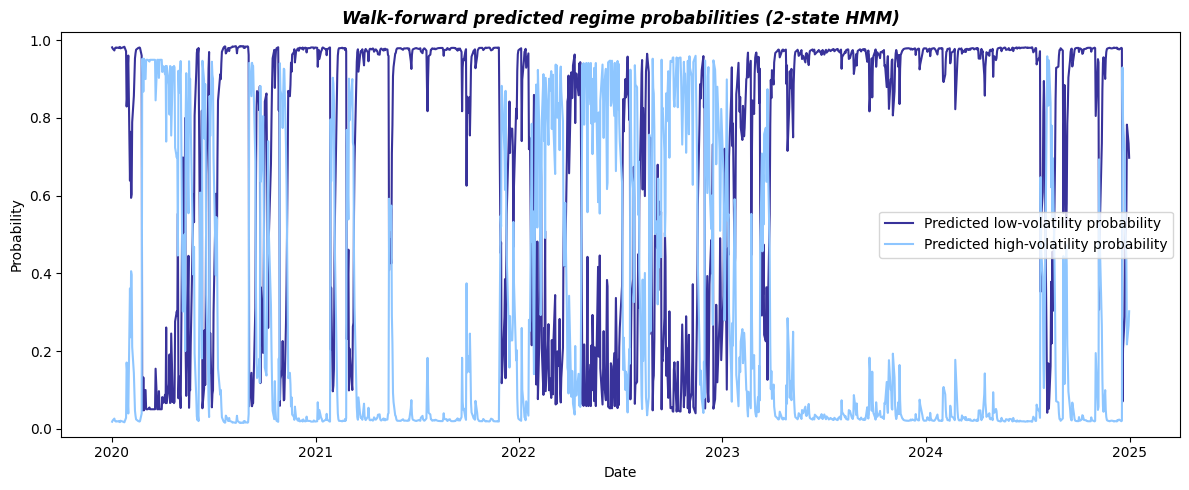

In [16]:
# ---------------------------------------------------------------------
# Plot walk-forward probabilities
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

pred_prob_cols = get_regime_probability_columns(
    walkforward_regime_df,
    prob_type="pred",
)

for col in pred_prob_cols:
    ax.plot(
        walkforward_regime_df["date"],
        walkforward_regime_df[col],
        label=pretty_regime_label(col),
    )

ax.set_title(f"Walk-forward predicted regime probabilities ({N_COMPONENTS}-state HMM)")
ax.set_xlabel("Date")
ax.set_ylabel("Probability")
ax.set_ylim(-0.02, 1.02)
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Regime-switching Black-Scholes PDE

The regime-switching Black-Scholes model prices the option jointly across regimes. For the two-state case, the low-volatility and high-volatility option values satisfy the coupled PDE system

$$
\frac{\partial V_L}{\partial t}
+ \frac{1}{2}\sigma_L^2 S^2 \frac{\partial^2 V_L}{\partial S^2}
+ rS\frac{\partial V_L}{\partial S}
- rV_L
+ q_{LH}(V_H - V_L)
=0,
$$

$$
\frac{\partial V_H}{\partial t}
+ \frac{1}{2}\sigma_H^2 S^2 \frac{\partial^2 V_H}{\partial S^2}
+ rS\frac{\partial V_H}{\partial S}
- rV_H
+ q_{HL}(V_L - V_H)
=0.
$$

At maturity, both regimes share the same payoff. For a call,

$$
V_L(S,T)=V_H(S,T)=\max(S-K,0),
$$

and for a put,

$$
V_L(S,T)=V_H(S,T)=\max(K-S,0).
$$

This PDE approach differs from a simple weighted Black-Scholes approximation. A weighted Black-Scholes approximation only averages fixed-volatility Black-Scholes prices at the valuation date. The coupled PDE instead prices the possibility that the volatility regime may switch during the option's remaining life.

Given the two regime-conditional option values, the final regime-switching model price is obtained by averaging them with the current regime probabilities:

$$
C^{RS}(S,t)
=
p_L(t)V_L(S,t)
+
p_H(t)V_H(S,t),
$$

where $p_L(t)$ and $p_H(t)$ are the probabilities that the market is currently in the low-volatility and high-volatility regimes, respectively. In the empirical implementation, these probabilities are the one-step-ahead predicted HMM probabilities,

$$
p_L(t)=p_{L,t}^{pred},
\qquad
p_H(t)=p_{H,t}^{pred},
$$

with

$$
p_L(t)+p_H(t)=1.
$$

This aggregation works because $V_L(S,t)$ and $V_H(S,t)$ are conditional prices. The value $V_L$ is the option price conditional on the current regime being low volatility, while $V_H$ is the option price conditional on the current regime being high volatility. Since the current regime is latent and therefore not directly observed, the unconditional model price is the expectation of the regime-conditional prices under the current regime probability distribution:

$$
C^{RS}(S,t)
=
\mathbb{E}\left[V_{X_t}(S,t)\mid \mathcal{F}_{t-1}\right].
$$

For the two-state case, this expectation is exactly

$$
C^{RS}(S,t)
=
\mathbb{P}(X_t=L\mid \mathcal{F}_{t-1})V_L(S,t)
+
\mathbb{P}(X_t=H\mid \mathcal{F}_{t-1})V_H(S,t).
$$

The implementation below uses a fully implicit finite-difference scheme. The two regime values are solved jointly at every time step, which incorporates the transition intensities $q_{LH}$ and $q_{HL}$ directly into the pricing equation. After the coupled PDE returns $V_L$ and $V_H$, the final option price is computed using the one-step-ahead predicted probabilities. This timing avoids look-ahead bias, because the date-$t$ option price is computed using only information available before observing the date-$t$ return.

In [17]:
# ---------------------------------------------------------------------
# Finite-difference solver for the coupled 2-state RSBS PDE
# ---------------------------------------------------------------------

def _validate_option_type(option_type):
    option_type = str(option_type).lower().strip()
    if option_type in ["c", "call"]:
        return "call"
    if option_type in ["p", "put"]:
        return "put"
    raise ValueError(f"Unsupported option_type: {option_type}")


def _payoff(S_grid, K, option_type):
    option_type = _validate_option_type(option_type)
    if option_type == "call":
        return np.maximum(S_grid - K, 0.0)
    return np.maximum(K - S_grid, 0.0)


def _boundary_values(tau, Smax, K, r, option_type):
    """
    Boundary values at time-to-maturity tau.
    The same boundary is used for both regimes.
    """
    option_type = _validate_option_type(option_type)

    if option_type == "call":
        lower = 0.0
        upper = Smax - K * np.exp(-r * tau)
    else:
        lower = K * np.exp(-r * tau)
        upper = 0.0

    return float(max(lower, 0.0)), float(max(upper, 0.0))


def solve_rsbs_pde_2state(
    S0,
    K,
    T,
    r,
    sigma_low,
    sigma_high,
    q_lh,
    q_hl,
    option_type="call",
    Smax=None,
    n_S=300,
    n_t=300,
    return_grid=False,
):
    """
    Solve the two-state regime-switching Black-Scholes PDE using a fully
    implicit finite-difference scheme.

    Parameters
    ----------
    S0, K : float
        Spot and strike.
    T : float
        Time to maturity in years.
    r : float
        Continuously compounded risk-free rate.
    sigma_low, sigma_high : float
        Annualized volatilities for the low- and high-volatility regimes.
    q_lh, q_hl : float
        Annualized transition intensities from low to high and high to low.
    option_type : {"call", "put"}
        European option type.
    Smax : float or None
        Upper stock-price grid boundary. If None, a conservative default is used.
    n_S, n_t : int
        Number of stock and time grid steps.
    return_grid : bool
        If True, return the full grid output.

    Returns
    -------
    V_low_0, V_high_0 : float
        Regime-conditional prices at S0.
    Optional third output:
        dictionary with S_grid, V_low, V_high.
    """
    option_type = _validate_option_type(option_type)

    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)
    sigma_low = float(sigma_low)
    sigma_high = float(sigma_high)
    q_lh = max(float(q_lh), 0.0)
    q_hl = max(float(q_hl), 0.0)

    if not np.isfinite(S0) or not np.isfinite(K) or S0 <= 0 or K <= 0:
        raise ValueError("S0 and K must be positive finite numbers.")

    if not np.isfinite(T) or T <= 0:
        intrinsic = float(_payoff(np.array([S0]), K, option_type)[0])
        if return_grid:
            return intrinsic, intrinsic, {"S_grid": np.array([S0]), "V_low": np.array([intrinsic]), "V_high": np.array([intrinsic])}
        return intrinsic, intrinsic

    if sigma_low <= 0 or sigma_high <= 0:
        raise ValueError("Regime volatilities must be positive.")

    if Smax is None:
        Smax = max(3.0 * S0, 2.0 * K)

    Smax = float(Smax)
    n_S = int(n_S)
    n_t = int(n_t)

    if n_S < 50:
        raise ValueError("n_S should be at least 50 for a stable grid.")
    if n_t < 50:
        raise ValueError("n_t should be at least 50 for a stable grid.")

    dS = Smax / n_S
    dt = T / n_t

    S_grid = np.linspace(0.0, Smax, n_S + 1)
    interior_S = S_grid[1:-1]
    m = len(interior_S)

    V_low = _payoff(S_grid, K, option_type)
    V_high = V_low.copy()

    sigmas = [sigma_low, sigma_high]

    # Build finite-difference coefficients for each regime on the interior grid.
    # PDE operator:
    # L V = 0.5 sigma^2 S^2 V_SS + r S V_S
    # Backward implicit step in tau:
    # (I - dt * A) V^{new} - dt * q_ij V_j^{new} = V^{old}
    # where A includes diffusion, drift, discount, and own-state switching terms.
    A_blocks = []

    for sigma, q_out in [(sigma_low, q_lh), (sigma_high, q_hl)]:
        a = 0.5 * sigma**2 * interior_S**2 / dS**2 - 0.5 * r * interior_S / dS
        b = -sigma**2 * interior_S**2 / dS**2 - r - q_out
        c = 0.5 * sigma**2 * interior_S**2 / dS**2 + 0.5 * r * interior_S / dS

        lower = -dt * a[1:]
        diag = 1.0 - dt * b
        upper = -dt * c[:-1]

        A = np.zeros((m, m))
        np.fill_diagonal(A, diag)
        np.fill_diagonal(A[1:], lower)
        np.fill_diagonal(A[:, 1:], upper)

        A_blocks.append((A, a, c))

    A_low, a_low, c_low = A_blocks[0]
    A_high, a_high, c_high = A_blocks[1]

    coupling_low_to_high = -dt * q_lh * np.eye(m)
    coupling_high_to_low = -dt * q_hl * np.eye(m)

    system_matrix = np.block(
        [
            [A_low, coupling_low_to_high],
            [coupling_high_to_low, A_high],
        ]
    )

    # Step forward in time-to-maturity from payoff at tau=0 to price at tau=T.
    for step in range(n_t):
        tau_new = (step + 1) * dt

        low_lower_bc, low_upper_bc = _boundary_values(tau_new, Smax, K, r, option_type)
        high_lower_bc, high_upper_bc = low_lower_bc, low_upper_bc

        rhs_low = V_low[1:-1].copy()
        rhs_high = V_high[1:-1].copy()

        # Boundary contributions from the implicit left-hand side.
        rhs_low[0] += dt * a_low[0] * low_lower_bc
        rhs_low[-1] += dt * c_low[-1] * low_upper_bc

        rhs_high[0] += dt * a_high[0] * high_lower_bc
        rhs_high[-1] += dt * c_high[-1] * high_upper_bc

        rhs = np.concatenate([rhs_low, rhs_high])

        solution = np.linalg.solve(system_matrix, rhs)

        V_low[0] = low_lower_bc
        V_low[-1] = low_upper_bc
        V_low[1:-1] = solution[:m]

        V_high[0] = high_lower_bc
        V_high[-1] = high_upper_bc
        V_high[1:-1] = solution[m:]

    V_low_0 = float(np.interp(S0, S_grid, V_low))
    V_high_0 = float(np.interp(S0, S_grid, V_high))

    if return_grid:
        return V_low_0, V_high_0, {
            "S_grid": S_grid,
            "V_low": V_low,
            "V_high": V_high,
            "Smax": Smax,
            "n_S": n_S,
            "n_t": n_t,
        }

    return V_low_0, V_high_0


def price_rsbs_pde(
    S0,
    K,
    T,
    r,
    sigma_low,
    sigma_high,
    q_lh,
    q_hl,
    p_low,
    p_high,
    option_type="call",
    Smax=None,
    n_S=300,
    n_t=300,
):
    """
    Price a European option using the 2-state regime-switching BS PDE.

    Returns
    -------
    dict
        V_low, V_high, rs_price, and normalized probabilities.
    """
    p = _normalize_prob_vector([p_low, p_high])
    p_low = float(p[0])
    p_high = float(p[1])

    V_low, V_high = solve_rsbs_pde_2state(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        q_lh=q_lh,
        q_hl=q_hl,
        option_type=option_type,
        Smax=Smax,
        n_S=n_S,
        n_t=n_t,
        return_grid=False,
    )

    rs_price = p_low * V_low + p_high * V_high

    return {
        "V_low": V_low,
        "V_high": V_high,
        "rs_price": float(rs_price),
        "p_low": p_low,
        "p_high": p_high,
    }

# ================================================================
# General N-state RSBS PDE solver
# ================================================================

def clean_generator_matrix(Q):
    """
    Ensure a valid continuous-time generator:
    off-diagonal entries non-negative and rows summing to zero.
    """
    Q = np.asarray(Q, dtype=float).copy()
    n_states = Q.shape[0]

    for i in range(n_states):
        for j in range(n_states):
            if i != j:
                Q[i, j] = max(float(Q[i, j]), 0.0)

    for i in range(n_states):
        Q[i, i] = -np.sum(Q[i, np.arange(n_states) != i])

    return Q


def solve_rsbs_pde_nstate(
    S0,
    K,
    T,
    r,
    sigmas,
    Q,
    option_type="call",
    Smax=None,
    n_S=300,
    n_t=300,
    return_grid=False,
):
    """
    Solve the N-state regime-switching Black-Scholes PDE using a fully
    implicit finite-difference scheme.
    """
    option_type = _validate_option_type(option_type)

    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)

    sigmas = np.asarray(sigmas, dtype=float).reshape(-1)
    n_states = len(sigmas)

    Q = clean_generator_matrix(Q)

    if Q.shape != (n_states, n_states):
        raise ValueError("Q must have shape (n_states, n_states).")

    if not np.isfinite(S0) or not np.isfinite(K) or S0 <= 0 or K <= 0:
        raise ValueError("S0 and K must be positive finite numbers.")

    if not np.all(np.isfinite(sigmas)) or np.any(sigmas <= 0):
        raise ValueError("All regime volatilities must be positive finite numbers.")

    if not np.isfinite(T) or T <= 0:
        intrinsic = float(_payoff(np.array([S0]), K, option_type)[0])
        values = np.repeat(intrinsic, n_states)

        if return_grid:
            return values, {
                "S_grid": np.array([S0]),
                "V": values.reshape(n_states, 1),
            }

        return values

    if Smax is None:
        Smax = max(3.0 * S0, 2.0 * K)

    Smax = float(Smax)
    n_S = int(n_S)
    n_t = int(n_t)

    if n_S < 50:
        raise ValueError("n_S should be at least 50 for a stable grid.")
    if n_t < 50:
        raise ValueError("n_t should be at least 50 for a stable grid.")

    dS = Smax / n_S
    dt = T / n_t

    S_grid = np.linspace(0.0, Smax, n_S + 1)
    interior_S = S_grid[1:-1]
    m = len(interior_S)

    payoff = _payoff(S_grid, K, option_type)
    V = np.vstack([payoff.copy() for _ in range(n_states)])

    system_matrix = np.zeros((n_states * m, n_states * m))
    boundary_a = []
    boundary_c = []

    for state in range(n_states):
        sigma = sigmas[state]
        q_out = np.sum(Q[state, np.arange(n_states) != state])

        a = 0.5 * sigma**2 * interior_S**2 / dS**2 - 0.5 * r * interior_S / dS
        b = -sigma**2 * interior_S**2 / dS**2 - r - q_out
        c = 0.5 * sigma**2 * interior_S**2 / dS**2 + 0.5 * r * interior_S / dS

        lower = -dt * a[1:]
        diag = 1.0 - dt * b
        upper = -dt * c[:-1]

        A = np.zeros((m, m))
        np.fill_diagonal(A, diag)
        np.fill_diagonal(A[1:], lower)
        np.fill_diagonal(A[:, 1:], upper)

        row_start = state * m
        row_end = (state + 1) * m

        system_matrix[row_start:row_end, row_start:row_end] = A

        for other_state in range(n_states):
            if other_state == state:
                continue

            col_start = other_state * m
            col_end = (other_state + 1) * m

            system_matrix[row_start:row_end, col_start:col_end] = (
                -dt * Q[state, other_state] * np.eye(m)
            )

        boundary_a.append(a)
        boundary_c.append(c)

    for step in range(n_t):
        tau_new = (step + 1) * dt
        lower_bc, upper_bc = _boundary_values(tau_new, Smax, K, r, option_type)

        rhs_blocks = []

        for state in range(n_states):
            rhs_state = V[state, 1:-1].copy()

            rhs_state[0] += dt * boundary_a[state][0] * lower_bc
            rhs_state[-1] += dt * boundary_c[state][-1] * upper_bc

            rhs_blocks.append(rhs_state)

        rhs = np.concatenate(rhs_blocks)
        solution = np.linalg.solve(system_matrix, rhs)

        for state in range(n_states):
            start = state * m
            end = (state + 1) * m

            V[state, 0] = lower_bc
            V[state, -1] = upper_bc
            V[state, 1:-1] = solution[start:end]

    values_at_S0 = np.array(
        [
            float(np.interp(S0, S_grid, V[state]))
            for state in range(n_states)
        ]
    )

    if return_grid:
        return values_at_S0, {
            "S_grid": S_grid,
            "V": V,
            "Smax": Smax,
            "n_S": n_S,
            "n_t": n_t,
        }

    return values_at_S0


def price_rsbs_pde_nstate(
    S0,
    K,
    T,
    r,
    sigmas,
    Q,
    probabilities,
    option_type="call",
    Smax=None,
    n_S=300,
    n_t=300,
):
    """
    Price a European option using an N-state regime-switching BS PDE.
    """
    sigmas = np.asarray(sigmas, dtype=float).reshape(-1)
    probabilities = _normalize_prob_vector(probabilities)
    Q = np.asarray(Q, dtype=float)

    if len(sigmas) != len(probabilities):
        raise ValueError("sigmas and probabilities must have the same length.")

    values = solve_rsbs_pde_nstate(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigmas=sigmas,
        Q=Q,
        option_type=option_type,
        Smax=Smax,
        n_S=n_S,
        n_t=n_t,
        return_grid=False,
    )

    rs_price = float(np.dot(probabilities, values))

    out = {
        "rs_price": rs_price,
        "probabilities": probabilities,
        "regime_values": values,
    }

    for i, value in enumerate(values):
        out[f"V_state_{i}"] = float(value)
        out[f"p_state_{i}"] = float(probabilities[i])

    return out

# 4. Walk-forward pricing of the ATM SPX option

The ATM dataset contains one observed option price per trading day. The pricing exercise uses the actual observed strike and expiry date when available, while retaining the same walk-forward HMM inputs described above.

For each date $t$, the pricing inputs are $S_t$, $K_t$, $T_t$, $r_t$, the observed market price $C_t^{mkt}$, the regime volatilities, the switching intensities, and the one-step-ahead predicted regime probabilities. The model price is compared directly with the market option price.


In [18]:
# ================================================================
# Walk-forward pricing of the already available ATM 30D option price
# ================================================================

ATM_MATURITY_DAYS = 30
ATM_MATURITY_YEARS = ATM_MATURITY_DAYS / 365
OPTION_TYPE = "call"  # change to "put" if your option_price column refers to puts

## Prepare the ATM option pricing dataframe

The original dataset contains the market option price in `option_price`, together with `strike` and `expiry_date`.

The current implementation uses the actual strike and computes time to maturity from the observed expiry date. If an expiry date is missing or invalid, the row is excluded from the pricing sample. This keeps the notebook consistent with the current thesis implementation and avoids the older approximation $K_t=S_t$, $T=30/365$.


In [19]:
def prepare_atm_option_pricing_df(
    final_df,
    option_price_col="option_price",
    option_type=OPTION_TYPE,
):
    """
    Build the ATM pricing dataframe using the observed strike and expiry date.
    """
    pricing_df = final_df[
        ["date", "spx", "r_3m", "strike", "expiry_date", option_price_col]
    ].copy()

    pricing_df["date"] = pd.to_datetime(pricing_df["date"], errors="coerce")
    pricing_df["expiry_date"] = pd.to_datetime(pricing_df["expiry_date"], errors="coerce")

    for col in ["spx", "r_3m", "strike", option_price_col]:
        pricing_df[col] = pd.to_numeric(pricing_df[col], errors="coerce")

    pricing_df = pricing_df.rename(columns={option_price_col: "market_price"})
    pricing_df["T"] = (pricing_df["expiry_date"] - pricing_df["date"]).dt.days / 365.0
    pricing_df["maturity_days"] = (pricing_df["expiry_date"] - pricing_df["date"]).dt.days
    pricing_df["option_type"] = option_type
    pricing_df["moneyness"] = pricing_df["spx"] / pricing_df["strike"]

    pricing_df = pricing_df.replace([np.inf, -np.inf], np.nan)
    pricing_df = pricing_df.dropna(subset=["date", "spx", "r_3m", "strike", "market_price", "T"])
    pricing_df = pricing_df[
        (pricing_df["spx"] > 0)
        & (pricing_df["strike"] > 0)
        & (pricing_df["market_price"] > 0)
        & (pricing_df["T"] > 0)
    ].copy()

    pricing_df = pricing_df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)

    print("ATM option pricing dataframe")
    print("-" * 80)
    print(f"Rows: {len(pricing_df)}")
    print(f"Date range: {pricing_df['date'].min().date()} to {pricing_df['date'].max().date()}")
    print(f"Mean maturity: {pricing_df['maturity_days'].mean():.2f} calendar days")
    print(f"Mean moneyness S/K: {pricing_df['moneyness'].mean():.4f}")

    return pricing_df


## Merge ATM option prices with walk-forward regime estimates

The walk-forward HMM output contains the model inputs needed by the PDE solver:

$$
\sigma_L,\quad \sigma_H,
$$

$$
q_{LH},\quad q_{HL},
$$

$$
p_{L,t}^{pred},\quad p_{H,t}^{pred}.
$$

The next cell merges these quantities with the ATM option price series by date.

In [20]:
def merge_atm_options_with_walkforward(atm_option_df, walkforward_regime_df):
    """
    Merge ATM option market prices with walk-forward HMM regime estimates.

    Works for both 2-state and 3-state HMM outputs.
    """
    atm = atm_option_df.copy()
    atm["date"] = pd.to_datetime(atm["date"], errors="coerce")

    regimes = walkforward_regime_df.copy()
    regimes["date"] = pd.to_datetime(regimes["date"], errors="coerce")

    if "n_components" not in regimes.columns:
        raise ValueError("walkforward_regime_df must contain 'n_components'.")

    sigma_cols = sorted([col for col in regimes.columns if col.startswith("sigma_state_")])
    prob_cols = sorted([col for col in regimes.columns if col.startswith("p_state_") and col.endswith("_pred")])
    Q_cols = sorted([col for col in regimes.columns if col.startswith("Q_")])

    alias_cols = [
        "sigma_low",
        "sigma_medium",
        "sigma_high",
        "p_low_pred",
        "p_medium_pred",
        "p_high_pred",
    ]

    keep_cols = ["date", "n_components"] + sigma_cols + prob_cols + Q_cols
    keep_cols += [col for col in alias_cols if col in regimes.columns]
    keep_cols = list(dict.fromkeys(keep_cols))

    pricing_df = atm.merge(
        regimes[keep_cols],
        on="date",
        how="inner",
    )

    pricing_df = pricing_df.sort_values("date").reset_index(drop=True)

    return pricing_df

## Price the ATM option with the regime-switching PDE

For each date, the PDE solver computes:

$$
V_L(S_t,t)
$$

and

$$
V_H(S_t,t).
$$

Then the model price is:

$$
C_t^{RS}
=
p_{L,t}^{pred}V_L(S_t,t)
+
p_{H,t}^{pred}V_H(S_t,t).
$$

This is compared with the observed market option price.

In [21]:
def extract_sigmas_probabilities_Q_from_row(row):
    """
    Extract sigmas, predicted probabilities, and Q matrix from a pricing row.
    Works for both 2-state and 3-state rows.
    """
    n_components = int(row["n_components"])

    sigma_cols = [f"sigma_state_{i}" for i in range(n_components)]
    prob_cols = [f"p_state_{i}_pred" for i in range(n_components)]

    sigmas = np.array([float(row[col]) for col in sigma_cols], dtype=float)
    probabilities = np.array([float(row[col]) for col in prob_cols], dtype=float)

    Q = np.zeros((n_components, n_components), dtype=float)

    for i in range(n_components):
        for j in range(n_components):
            col = f"Q_{i}{j}"
            if col not in row.index:
                raise ValueError(f"Missing Q column: {col}")
            Q[i, j] = float(row[col])

    return sigmas, probabilities, Q


def price_atm_options_walkforward(pricing_df, n_S=150, n_t=150, progress_every=50):
    """
    Price the ATM 30D option series using the walk-forward RSBS PDE.

    Works with both 2-state and 3-state HMM outputs.
    """
    rows = []

    for idx, row in pricing_df.iterrows():
        try:
            sigmas, probabilities, Q = extract_sigmas_probabilities_Q_from_row(row)

            out = price_rsbs_pde_nstate(
                S0=float(row["spx"]),
                K=float(row["strike"]),
                T=float(row["T"]),
                r=float(row["r_3m"]),
                sigmas=sigmas,
                Q=Q,
                probabilities=probabilities,
                option_type=row["option_type"],
                n_S=n_S,
                n_t=n_t,
            )

            new_row = row.to_dict()
            new_row["rs_price"] = out["rs_price"]
            new_row["success"] = True
            new_row["error_message"] = ""

            for i in range(len(sigmas)):
                new_row[f"V_state_{i}"] = out[f"V_state_{i}"]
                new_row[f"p_state_{i}_used"] = out[f"p_state_{i}"]

            new_row["V_low"] = out["V_state_0"]

            if len(sigmas) == 2:
                new_row["V_high"] = out["V_state_1"]

            if len(sigmas) == 3:
                new_row["V_medium"] = out["V_state_1"]
                new_row["V_high"] = out["V_state_2"]

        except Exception as exc:
            new_row = row.to_dict()
            new_row["rs_price"] = np.nan
            new_row["success"] = False
            new_row["error_message"] = repr(exc)

        rows.append(new_row)

        if progress_every is not None and progress_every > 0:
            if (idx + 1) % progress_every == 0:
                print(f"Priced {idx + 1} / {len(pricing_df)} observations")

    result = pd.DataFrame(rows)

    result["pricing_error"] = result["rs_price"] - result["market_price"]
    result["abs_error"] = result["pricing_error"].abs()
    result["relative_error"] = result["abs_error"] / result["market_price"]

    return result

## Run the walk-forward ATM option pricing exercise

This cell creates the ATM option pricing dataframe, merges it with the walk-forward HMM estimates, prices each option using the regime-switching PDE, and stores the pricing errors.

For a first run, the PDE grid uses `n_S=150` and `n_t=150`. For final thesis results, you can increase these values after checking runtime.

In [22]:
# ================================================================
# Run walk-forward ATM option pricing
# ================================================================

atm_option_df = prepare_atm_option_pricing_df(
    final_df=final_df,
    option_price_col="option_price",
    option_type=OPTION_TYPE,
)

print("ATM option base dataframe:")
print(atm_option_df.shape)
display(atm_option_df.head())

atm_pricing_df = merge_atm_options_with_walkforward(
    atm_option_df=atm_option_df,
    walkforward_regime_df=walkforward_regime_df,
)

print("ATM pricing dataframe after merging with walk-forward regimes:")
print(atm_pricing_df.shape)

pricing_preview_cols = [
    "date",
    "spx",
    "strike",
    "T",
    "r_3m",
    "market_price",
    "n_components",
    "sigma_low",
    "sigma_medium",
    "sigma_high",
    "p_low_pred",
    "p_medium_pred",
    "p_high_pred",
]

pricing_preview_cols = get_existing_columns(atm_pricing_df, pricing_preview_cols)

display(atm_pricing_df[pricing_preview_cols].head())

example_row = atm_pricing_df.dropna(
    subset=["spx", "strike", "T", "r_3m", "market_price"]
).iloc[-1]

example_sigmas, example_probabilities, example_Q = extract_sigmas_probabilities_Q_from_row(example_row)

example_price = price_rsbs_pde_nstate(
    S0=float(example_row["spx"]),
    K=float(example_row["strike"]),
    T=float(example_row["T"]),
    r=float(example_row["r_3m"]),
    sigmas=example_sigmas,
    Q=example_Q,
    probabilities=example_probabilities,
    option_type=example_row["option_type"],
    n_S=250,
    n_t=250,
)

display(pd.DataFrame([example_price]))

priced_atm_options = price_atm_options_walkforward(
    atm_pricing_df,
    n_S=150,
    n_t=150,
    progress_every=50,
)

print("Priced ATM option dataframe:")
print(priced_atm_options.shape)

priced_preview_cols = [
    "date",
    "spx",
    "strike",
    "T",
    "market_price",
    "V_low",
    "V_medium",
    "V_high",
    "rs_price",
    "pricing_error",
    "abs_error",
    "relative_error",
    "p_low_pred",
    "p_medium_pred",
    "p_high_pred",
    "success",
]

priced_preview_cols = get_existing_columns(priced_atm_options, priced_preview_cols)

display(priced_atm_options[priced_preview_cols].head())

ATM option pricing dataframe
--------------------------------------------------------------------------------
Rows: 2498
Date range: 2015-01-05 to 2024-12-31
Mean maturity: 28.64 calendar days
Mean moneyness S/K: 0.9999
ATM option base dataframe:
(2498, 10)


,date,spx,r_3m,strike,expiry_date,market_price,T,maturity_days,option_type,moneyness
0,2015-01-05,"2,020.577884",0.000300,"2,020.000000",2015-01-30,35.700000,0.068493,25,call,1.000286
1,2015-01-06,"2,002.613588",0.000300,"2,005.000000",2015-01-30,34.950000,0.065753,24,call,0.998810
2,2015-01-07,"2,025.901051",0.000300,"2,025.000000",2015-02-06,36.950000,0.082192,30,call,1.000445
3,2015-01-08,"2,062.143555",0.000300,"2,060.000000",2015-02-06,33.000000,0.079452,29,call,1.001041
4,2015-01-09,"2,044.809900",0.000200,"2,045.000000",2015-02-06,32.500000,0.076712,28,call,0.999907


ATM pricing dataframe after merging with walk-forward regimes:
(1249, 23)


,date,spx,strike,T,r_3m,market_price,n_components,sigma_low,sigma_high,p_low_pred,p_high_pred
0,2020-01-02,"3,257.847787","3,260.000000",0.079452,0.015100,35.350000,2,0.104364,0.260918,0.981368,0.018632
1,2020-01-03,"3,234.848563","3,235.000000",0.076712,0.014900,43.450000,2,0.104364,0.260918,0.978258,0.021742
2,2020-01-06,"3,246.282557","3,245.000000",0.082192,0.015300,43.500000,2,0.104364,0.260918,0.973372,0.026628
3,2020-01-07,"3,237.182452","3,235.000000",0.079452,0.015100,44.000000,2,0.104364,0.260918,0.978970,0.021030
4,2020-01-08,"3,253.045944","3,255.000000",0.082192,0.015100,41.650000,2,0.104364,0.260918,0.980179,0.019821


,rs_price,probabilities,regime_values,V_state_0,p_state_0,V_state_1,p_state_1
0,125.956572,"[0.6973714982039516, 0.3026285017960485]","[99.68855812923503, 186.4880938652144]",99.688558,0.697371,186.488094,0.302629


Priced 50 / 1249 observations
Priced 100 / 1249 observations
Priced 150 / 1249 observations
Priced 200 / 1249 observations
Priced 250 / 1249 observations
Priced 300 / 1249 observations
Priced 350 / 1249 observations
Priced 400 / 1249 observations
Priced 450 / 1249 observations
Priced 500 / 1249 observations
Priced 550 / 1249 observations
Priced 600 / 1249 observations
Priced 650 / 1249 observations
Priced 700 / 1249 observations
Priced 750 / 1249 observations
Priced 800 / 1249 observations
Priced 850 / 1249 observations
Priced 900 / 1249 observations
Priced 950 / 1249 observations
Priced 1000 / 1249 observations
Priced 1050 / 1249 observations
Priced 1100 / 1249 observations
Priced 1150 / 1249 observations
Priced 1200 / 1249 observations
Priced ATM option dataframe:
(1249, 35)


,date,spx,strike,T,market_price,V_low,V_high,rs_price,pricing_error,abs_error,relative_error,p_low_pred,p_high_pred,success
0,2020-01-02,"3,257.847787","3,260.000000",0.079452,35.350000,42.191212,78.252020,42.863111,7.513111,7.513111,0.212535,0.981368,0.018632,True
1,2020-01-03,"3,234.848563","3,235.000000",0.076712,43.450000,41.610530,77.475707,42.390324,-1.059676,1.059676,0.024388,0.978258,0.021742,True
2,2020-01-06,"3,246.282557","3,245.000000",0.082192,43.500000,44.674785,80.653984,45.632854,2.132854,2.132854,0.049031,0.973372,0.026628,True
3,2020-01-07,"3,237.182452","3,235.000000",0.079452,44.000000,44.124882,79.903074,44.877282,0.877282,0.877282,0.019938,0.978970,0.021030,True
4,2020-01-08,"3,253.045944","3,255.000000",0.082192,41.650000,43.183476,79.235785,43.898052,2.248052,2.248052,0.053975,0.980179,0.019821,True


## Pricing error summary

The pricing accuracy is summarized using:

$$
MAE = \frac{1}{N}\sum_{t=1}^{N}|C_t^{RS}-C_t^{mkt}|
$$

$$
RMSE =
\sqrt{
\frac{1}{N}\sum_{t=1}^{N}(C_t^{RS}-C_t^{mkt})^2
}
$$

$$
MeanRelativeError =
\frac{1}{N}\sum_{t=1}^{N}
\frac{|C_t^{RS}-C_t^{mkt}|}{C_t^{mkt}}
$$

In [23]:
valid_atm = priced_atm_options.dropna(subset=["rs_price", "market_price"]).copy()
valid_atm = valid_atm[valid_atm["success"] & (valid_atm["market_price"] > 0)].copy()

atm_summary = pd.DataFrame([
    {
        "n_obs": len(valid_atm),
        "MAE": valid_atm["abs_error"].mean(),
        "RMSE": np.sqrt((valid_atm["pricing_error"] ** 2).mean()),
        "mean_relative_error": valid_atm["relative_error"].mean(),
        "median_relative_error": valid_atm["relative_error"].median(),
        "mean_market_price": valid_atm["market_price"].mean(),
        "mean_model_price": valid_atm["rs_price"].mean(),
        "success_rate": priced_atm_options["success"].mean(),
    }
])

display(atm_summary)

,n_obs,MAE,RMSE,mean_relative_error,median_relative_error,mean_market_price,mean_model_price,success_rate
0,1249,15.206719,21.152657,0.180127,0.156985,83.913571,86.026834,1.000000


## Market option price versus model price

The next figure compares the observed ATM option price with the regime-switching PDE price over time.

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


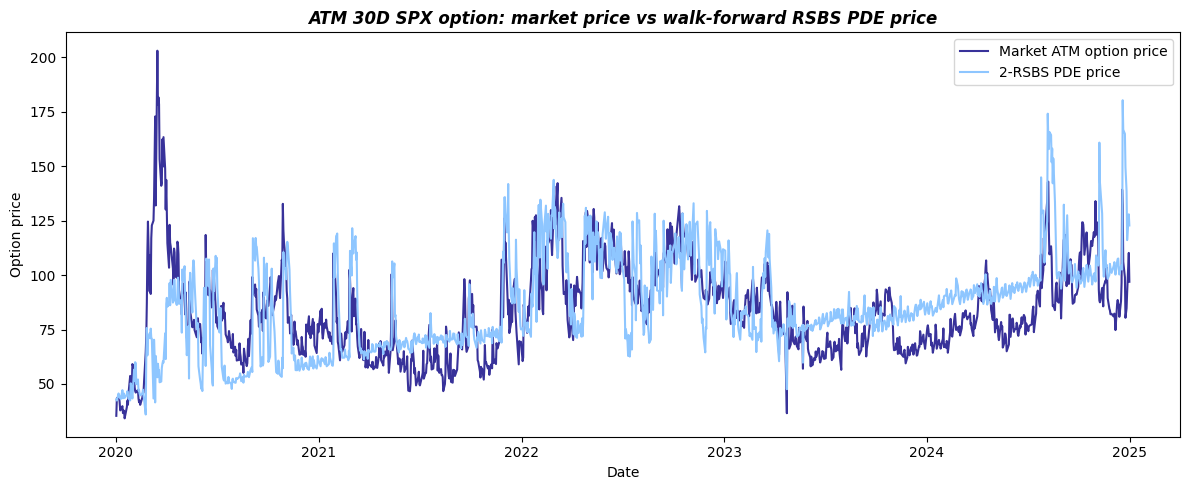

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(valid_atm["date"], valid_atm["market_price"], label="Market ATM option price")
ax.plot(valid_atm["date"], valid_atm["rs_price"], label=f"{N_COMPONENTS}-RSBS PDE price")
ax.set_title("ATM 30D SPX option: market price vs walk-forward RSBS PDE price")
ax.set_xlabel("Date")
ax.set_ylabel("Option price")
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Pricing error over time

This figure plots:

$$
C_t^{RS}-C_t^{mkt}.
$$

Values above zero indicate model overpricing. Values below zero indicate model underpricing.

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


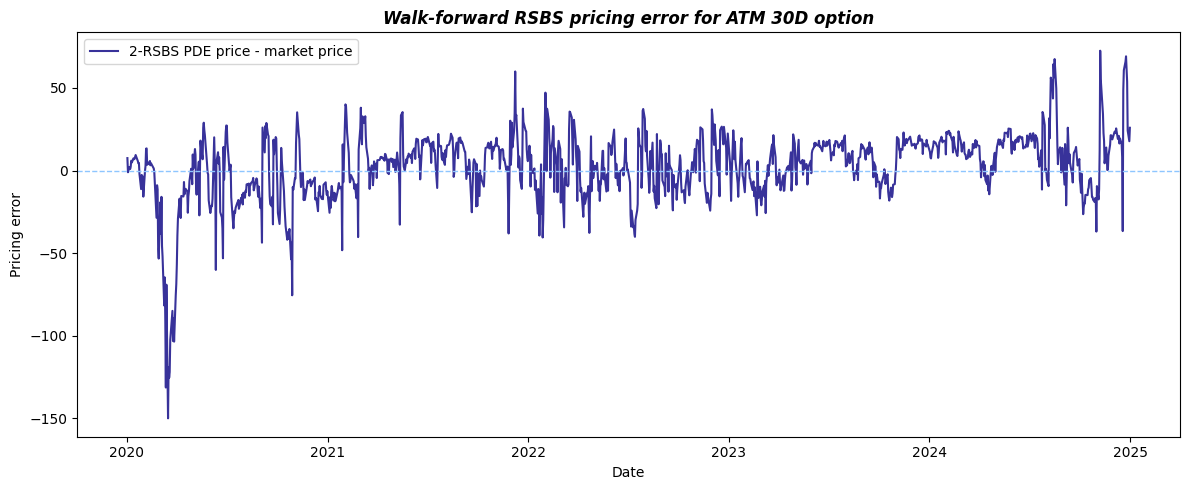

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(valid_atm["date"], valid_atm["pricing_error"], label=f"{N_COMPONENTS}-RSBS PDE price - market price")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Walk-forward RSBS pricing error for ATM 30D option")
ax.set_xlabel("Date")
ax.set_ylabel("Pricing error")
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

# 5. Benchmark comparison: RSBS versus standard Black-Scholes (PDF Chap.4)

To assess whether the regime-switching structure improves pricing performance, the RSBS model is compared with a standard Black-Scholes benchmark. The benchmark uses the same option inputs as the RSBS pricing exercise, namely the observed index level $S_t$, the observed strike $K_t$, the observed time to maturity $T_t$, and the short-term rate $r_t$. The only difference is that the benchmark replaces the regime-switching volatility structure with a single rolling historical volatility estimate.

To avoid look-ahead bias, the rolling volatility used on date $t$ is computed using returns available up to date $t-1$:

$$
\sigma_t^{roll}
=
\operatorname{Std}(R_{t-w},\dots,R_{t-1})\sqrt{252}.
$$

The benchmark Black-Scholes price is denoted by $C_t^{BS}$ and is compared with the regime-switching price $C_t^{RS}$ and the observed market price $C_t^{mkt}$.


In [26]:
# ---------------------------------------------------------------------
# Benchmark comparison: RSBS versus rolling-volatility Black-Scholes
# ---------------------------------------------------------------------

ROLLING_BS_WINDOW = 21

def black_scholes_price(S0, K, T, r, sigma, option_type="call"):
    option_type = _validate_option_type(option_type)

    S0, K, T, r, sigma = map(float, [S0, K, T, r, sigma])

    if S0 <= 0 or K <= 0 or not np.isfinite([S0, K, T, r, sigma]).all():
        return np.nan

    if T <= 0:
        return float(_payoff(np.array([S0]), K, option_type)[0])

    if sigma <= 0:
        return np.nan

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return float(S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))

    return float(K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1))


# Rolling historical volatility with one-day lag to avoid look-ahead bias
bs_vol_df = model_df[["date", "log_return"]].copy()
bs_vol_df["date"] = pd.to_datetime(bs_vol_df["date"])
bs_vol_df["bs_rolling_vol"] = (
    bs_vol_df["log_return"]
    .rolling(ROLLING_BS_WINDOW)
    .std()
    .shift(1)
    * np.sqrt(TRADING_DAYS_PER_YEAR)
)

comparison_df = priced_atm_options.copy()
comparison_df["date"] = pd.to_datetime(comparison_df["date"])

comparison_df = comparison_df.merge(
    bs_vol_df[["date", "bs_rolling_vol"]],
    on="date",
    how="left",
)

comparison_df["bs_price"] = comparison_df.apply(
    lambda row: black_scholes_price(
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        sigma=row["bs_rolling_vol"],
        option_type=row["option_type"],
    ),
    axis=1,
)

comparison_df["rs_error"] = comparison_df["rs_price"] - comparison_df["market_price"]
comparison_df["bs_error"] = comparison_df["bs_price"] - comparison_df["market_price"]

comparison_df["rs_abs_error"] = comparison_df["rs_error"].abs()
comparison_df["bs_abs_error"] = comparison_df["bs_error"].abs()

comparison_df["rs_relative_error"] = comparison_df["rs_abs_error"] / comparison_df["market_price"]
comparison_df["bs_relative_error"] = comparison_df["bs_abs_error"] / comparison_df["market_price"]

valid_comparison = comparison_df.dropna(
    subset=["market_price", "rs_price", "bs_price", "rs_abs_error", "bs_abs_error"]
).copy()

valid_comparison = valid_comparison[
    (valid_comparison["market_price"] > 0) & (valid_comparison["success"])
].copy()

print("Valid comparison observations:", len(valid_comparison))

comparison_preview_cols = [
    "date",
    "market_price",
    "rs_price",
    "bs_price",
    "rs_error",
    "bs_error",
    "rs_abs_error",
    "bs_abs_error",
    "rs_relative_error",
    "bs_relative_error",
    "bs_rolling_vol",
    "p_low_pred",
    "p_medium_pred",
    "p_high_pred",
]

comparison_preview_cols = get_existing_columns(
    valid_comparison,
    comparison_preview_cols,
)

display(valid_comparison[comparison_preview_cols].head())

Valid comparison observations: 1249


,date,market_price,rs_price,bs_price,rs_error,bs_error,rs_abs_error,bs_abs_error,rs_relative_error,bs_relative_error,bs_rolling_vol,p_low_pred,p_high_pred
0,2020-01-02,35.350000,42.863111,28.869917,7.513111,-6.480083,7.513111,6.480083,0.212535,0.183312,0.076405,0.981368,0.018632
1,2020-01-03,43.450000,42.390324,27.120009,-1.059676,-16.329991,1.059676,16.329991,0.024388,0.375834,0.070846,0.978258,0.021742
2,2020-01-06,43.500000,45.632854,29.299272,2.132854,-14.200728,2.132854,14.200728,0.049031,0.326454,0.071522,0.973372,0.026628
3,2020-01-07,44.000000,44.877282,28.644678,0.877282,-15.355322,0.877282,15.355322,0.019938,0.348985,0.070116,0.978970,0.021030
4,2020-01-08,41.650000,43.898052,27.857392,2.248052,-13.792608,2.248052,13.792608,0.053975,0.331155,0.072063,0.980179,0.019821


## Overall pricing performance

The two models are compared using MAE, RMSE, mean error, and relative pricing errors. Lower MAE and RMSE indicate better pricing accuracy. The mean error indicates whether a model tends to overprice or underprice on average.

In [27]:
def summarize_model_errors(df, model_name, price_col, error_col, abs_error_col, rel_error_col):
    return {
        "model": model_name,
        "n_obs": len(df),
        "MAE": df[abs_error_col].mean(),
        "RMSE": np.sqrt((df[error_col] ** 2).mean()),
        "mean_error": df[error_col].mean(),
        "median_error": df[error_col].median(),
        "mean_relative_error": df[rel_error_col].mean(),
        "median_relative_error": df[rel_error_col].median(),
        "mean_model_price": df[price_col].mean(),
        "mean_market_price": df["market_price"].mean(),
    }


model_comparison_summary = pd.DataFrame(
    [
        summarize_model_errors(
            valid_comparison,
            "Regime-Switching BS",
            "rs_price",
            "rs_error",
            "rs_abs_error",
            "rs_relative_error",
        ),
        summarize_model_errors(
            valid_comparison,
            "Rolling-volatility BS",
            "bs_price",
            "bs_error",
            "bs_abs_error",
            "bs_relative_error",
        ),
    ]
)

display(model_comparison_summary)

,model,n_obs,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price
0,Regime-Switching BS,1249,15.206719,21.152657,2.113263,4.872350,0.180127,0.156985,86.026834,83.913571
1,Rolling-volatility BS,1249,17.660729,26.903852,-0.535062,-2.633400,0.203060,0.156003,83.378509,83.913571


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


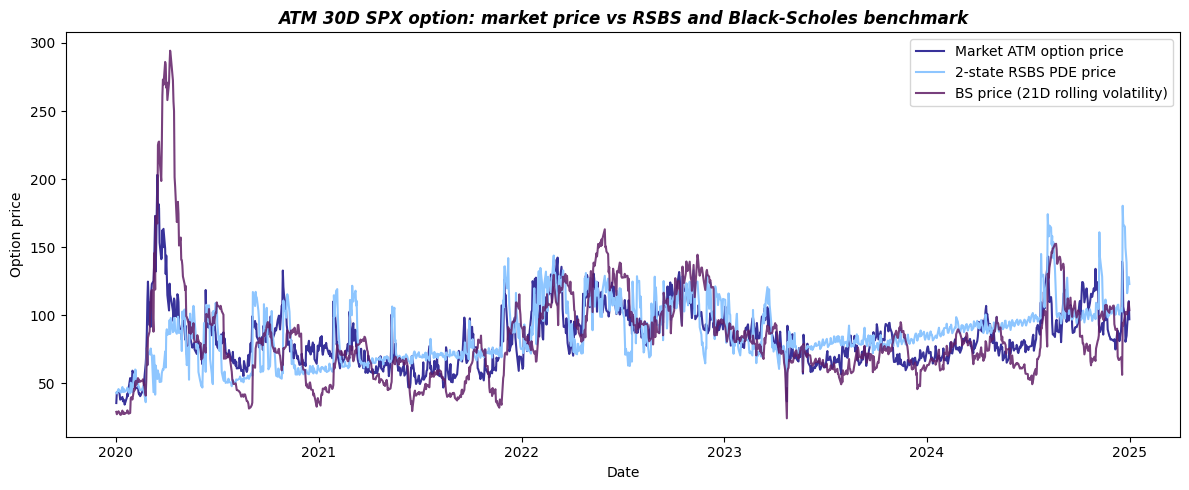

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(valid_comparison["date"], valid_comparison["market_price"], label="Market ATM option price")
ax.plot(valid_comparison["date"], valid_comparison["rs_price"], label=f"{N_COMPONENTS}-state RSBS PDE price")
ax.plot(
    valid_comparison["date"],
    valid_comparison["bs_price"],
    label=f"BS price ({ROLLING_BS_WINDOW}D rolling volatility)",
    alpha=0.85,
)

ax.set_title("ATM 30D SPX option: market price vs RSBS and Black-Scholes benchmark")
ax.set_xlabel("Date")
ax.set_ylabel("Option price")
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Pricing errors over time

The next figure compares the pricing errors of the two models:

$$
Error_t^{RS}=C_t^{RS}-C_t^{mkt},
\qquad
Error_t^{BS}=C_t^{BS}-C_t^{mkt}.
$$

Values above zero indicate overpricing, while values below zero indicate underpricing.

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


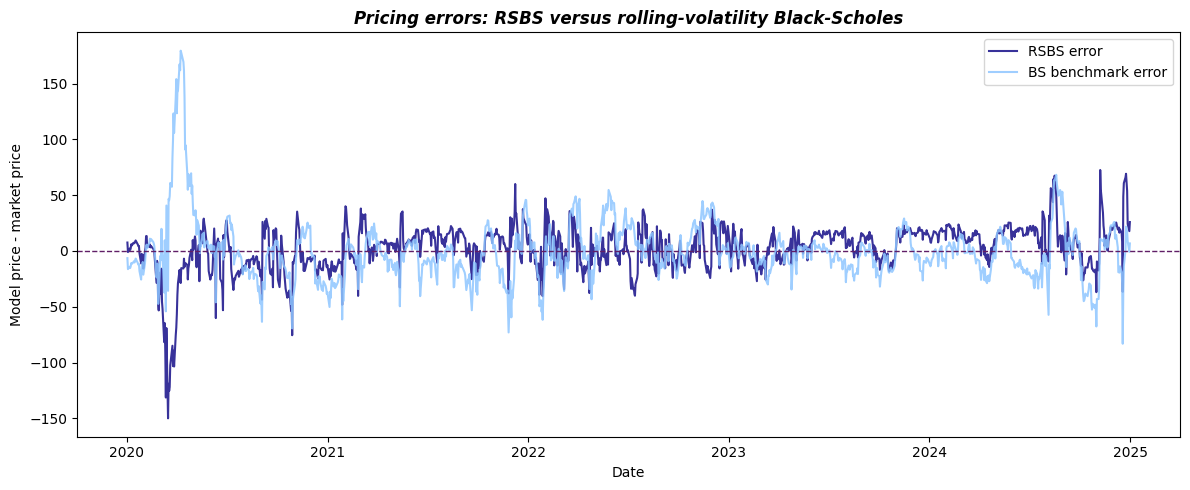

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(valid_comparison["date"], valid_comparison["rs_error"], label="RSBS error")
ax.plot(valid_comparison["date"], valid_comparison["bs_error"], label="BS benchmark error", alpha=0.85)
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Pricing errors: RSBS versus rolling-volatility Black-Scholes")
ax.set_xlabel("Date")
ax.set_ylabel("Model price - market price")
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Rolling average absolute pricing errors

Because daily pricing errors are noisy, the comparison is also shown using a rolling average of absolute errors:

$$
RollingMAE_t
=
\frac{1}{w}
\sum_{j=0}^{w-1}
|C_{t-j}^{model}-C_{t-j}^{mkt}|.
$$

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


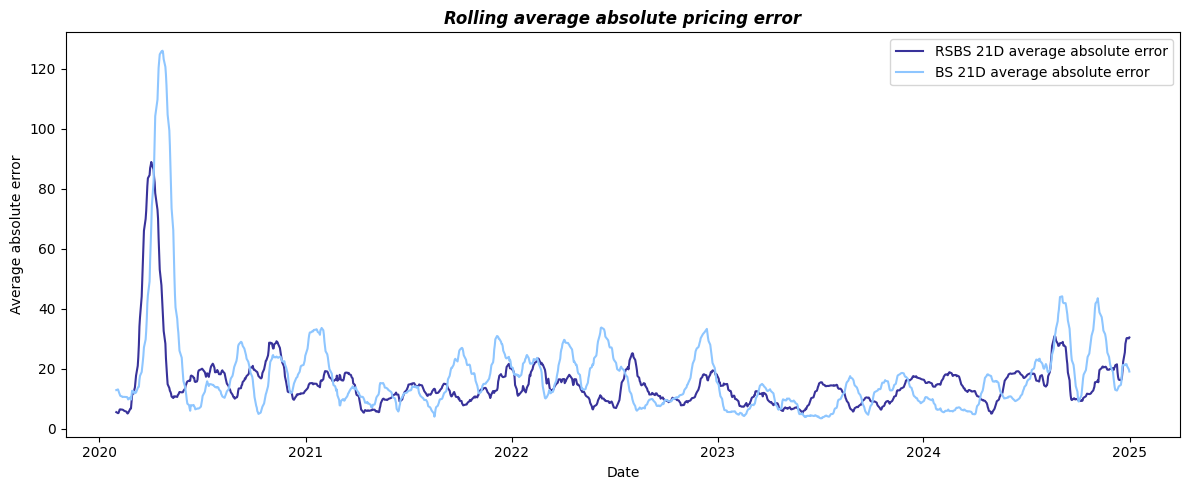

In [30]:
ERROR_ROLLING_WINDOW = 21

valid_comparison["rs_abs_error_roll"] = (
    valid_comparison["rs_abs_error"].rolling(ERROR_ROLLING_WINDOW).mean()
)

valid_comparison["bs_abs_error_roll"] = (
    valid_comparison["bs_abs_error"].rolling(ERROR_ROLLING_WINDOW).mean()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_comparison["date"],
    valid_comparison["rs_abs_error_roll"],
    label=f"RSBS {ERROR_ROLLING_WINDOW}D average absolute error",
)

ax.plot(
    valid_comparison["date"],
    valid_comparison["bs_abs_error_roll"],
    label=f"BS {ERROR_ROLLING_WINDOW}D average absolute error",
)

ax.set_title("Rolling average absolute pricing error")
ax.set_xlabel("Date")
ax.set_ylabel("Average absolute error")
ax.legend()
apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Implied-volatility comparison: market price versus RSBS price

The previous diagnostics compare models in price space. As an additional check, this section converts both the observed market option price and the RSBS model price into Black-Scholes implied volatilities.

For each ATM date $t$, the inversion uses the same option inputs as the pricing exercise:

$$
S_t,\quad K_t,\quad T_t,\quad r_t.
$$

Here $K_t$ is the observed strike and $T_t$ is computed from the observed expiry date, so the comparison is consistent with the ATM pricing dataframe and does not use the older approximation $K_t=S_t$ or a fixed maturity $T=30/365$.

The two implied-volatility series are

$$
\sigma^{mkt,IV}_t
=
BS^{-1}
\left(
C_t^{mkt}; S_t,K_t,T_t,r_t
\right),
$$

and

$$
\sigma^{RSBS,IV}_t
=
BS^{-1}
\left(
C_t^{RSBS}; S_t,K_t,T_t,r_t
\right).
$$

The implied-volatility error is defined as

$$
IVError_t
=
\sigma^{RSBS,IV}_t
-
\sigma^{mkt,IV}_t.
$$

A positive value means that the RSBS price embeds a higher Black-Scholes-equivalent volatility than the market price, while a negative value means that the RSBS price embeds a lower Black-Scholes-equivalent volatility.

In [31]:
from scipy.optimize import brentq


def black_scholes_implied_vol(
    market_price,
    S0,
    K,
    T,
    r,
    option_type="call",
    sigma_lower=1e-6,
    sigma_upper=5.0,
):
    """
    Black-Scholes implied volatility using the same option inputs
    used in the pricing exercise: observed strike and observed maturity.
    """
    if (
        not np.isfinite(market_price)
        or not np.isfinite(S0)
        or not np.isfinite(K)
        or not np.isfinite(T)
        or not np.isfinite(r)
    ):
        return np.nan

    if market_price <= 0 or S0 <= 0 or K <= 0 or T <= 0:
        return np.nan

    intrinsic = float(_payoff(np.array([S0]), K, option_type)[0])
    discounted_upper_bound = float(S0) if _validate_option_type(option_type) == "call" else float(K) * np.exp(-float(r) * float(T))

    if market_price < intrinsic - 1e-8:
        return np.nan

    if market_price > discounted_upper_bound + 1e-8:
        return np.nan

    def objective(sigma):
        return black_scholes_price(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            option_type=option_type,
        ) - market_price

    try:
        low_value = objective(sigma_lower)
        high_value = objective(sigma_upper)

        if (
            not np.isfinite(low_value)
            or not np.isfinite(high_value)
            or low_value * high_value > 0
        ):
            return np.nan

        return brentq(objective, sigma_lower, sigma_upper, maxiter=200)

    except Exception:
        return np.nan

In [32]:
# ================================================================
# Implied-volatility comparison: market price vs RSBS price
# ================================================================

iv_input_check_cols = [
    "date",
    "spx",
    "strike",
    "expiry_date",
    "T",
    "r_3m",
    "market_price",
    "rs_price",
    "option_type",
]

missing_iv_cols = [
    col for col in iv_input_check_cols
    if col not in valid_comparison.columns
]

if missing_iv_cols:
    raise ValueError(
        "The following columns are required for the implied-volatility comparison "
        f"but are missing from valid_comparison: {missing_iv_cols}"
    )

valid_comparison["maturity_days_check"] = (
    pd.to_datetime(valid_comparison["expiry_date"])
    - pd.to_datetime(valid_comparison["date"])
).dt.days

valid_comparison["T_check"] = valid_comparison["maturity_days_check"] / 365.0

max_T_difference = (
    valid_comparison["T"] - valid_comparison["T_check"]
).abs().max()

print("ATM implied-volatility input consistency check")
print("-" * 80)
print("The IV inversion uses the same observed strike and maturity used for ATM pricing.")
print(f"Maximum |T - T_check|: {max_T_difference:.12f}")
print(f"Mean maturity in days: {valid_comparison['maturity_days_check'].mean():.2f}")
print(f"Median maturity in days: {valid_comparison['maturity_days_check'].median():.2f}")

if max_T_difference > 1e-10:
    raise ValueError(
        "Mismatch between stored T and expiry-date-implied T. "
        "Check the ATM pricing dataframe construction."
    )

valid_comparison["market_iv"] = valid_comparison.apply(
    lambda row: black_scholes_implied_vol(
        market_price=row["market_price"],
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        option_type=row["option_type"],
    ),
    axis=1,
)

valid_comparison["rsbs_iv"] = valid_comparison.apply(
    lambda row: black_scholes_implied_vol(
        market_price=row["rs_price"],
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        option_type=row["option_type"],
    ),
    axis=1,
)

iv_comparison_df = valid_comparison.dropna(
    subset=["market_iv", "rsbs_iv"]
).copy()

iv_comparison_df["iv_error"] = (
    iv_comparison_df["rsbs_iv"] - iv_comparison_df["market_iv"]
)

iv_comparison_df["abs_iv_error"] = iv_comparison_df["iv_error"].abs()

print("\nValid implied-volatility comparison observations:", len(iv_comparison_df))

display(
    iv_comparison_df[
        get_existing_columns(
            iv_comparison_df,
            [
                "date",
                "spx",
                "strike",
                "maturity_days_check",
                "T",
                "r_3m",
                "market_price",
                "rs_price",
                "market_iv",
                "rsbs_iv",
                "iv_error",
                "abs_iv_error",
                "sigma_low",
                "sigma_medium",
                "sigma_high",
                "p_low_pred",
                "p_medium_pred",
                "p_high_pred",
            ],
        )
    ].head()
)

ATM implied-volatility input consistency check
--------------------------------------------------------------------------------
The IV inversion uses the same observed strike and maturity used for ATM pricing.
Maximum |T - T_check|: 0.000000000000
Mean maturity in days: 28.85
Median maturity in days: 29.00

Valid implied-volatility comparison observations: 1249


,date,spx,strike,maturity_days_check,T,r_3m,market_price,rs_price,market_iv,rsbs_iv,iv_error,abs_iv_error,sigma_low,sigma_high,p_low_pred,p_high_pred
0,2020-01-02,"3,257.847787","3,260.000000",29,0.079452,0.015100,35.350000,42.863111,0.094104,0.114624,0.020519,0.020519,0.104364,0.260918,0.981368,0.018632
1,2020-01-03,"3,234.848563","3,235.000000",28,0.076712,0.014900,43.450000,42.390324,0.116605,0.113636,-0.002968,0.002968,0.104364,0.260918,0.978258,0.021742
2,2020-01-06,"3,246.282557","3,245.000000",30,0.082192,0.015300,43.500000,45.632854,0.109885,0.115642,0.005758,0.005758,0.104364,0.260918,0.973372,0.026628
3,2020-01-07,"3,237.182452","3,235.000000",29,0.079452,0.015100,44.000000,44.877282,0.112460,0.114876,0.002417,0.002417,0.104364,0.260918,0.978970,0.021030
4,2020-01-08,"3,253.045944","3,255.000000",30,0.082192,0.015100,41.650000,43.898052,0.109161,0.115207,0.006046,0.006046,0.104364,0.260918,0.980179,0.019821


In [33]:
iv_comparison_summary = pd.DataFrame(
    [
        {
            "series": "Market implied volatility",
            "mean": iv_comparison_df["market_iv"].mean(),
            "median": iv_comparison_df["market_iv"].median(),
            "std": iv_comparison_df["market_iv"].std(),
            "min": iv_comparison_df["market_iv"].min(),
            "max": iv_comparison_df["market_iv"].max(),
        },
        {
            "series": "RSBS price-implied volatility",
            "mean": iv_comparison_df["rsbs_iv"].mean(),
            "median": iv_comparison_df["rsbs_iv"].median(),
            "std": iv_comparison_df["rsbs_iv"].std(),
            "min": iv_comparison_df["rsbs_iv"].min(),
            "max": iv_comparison_df["rsbs_iv"].max(),
        },
        {
            "series": "RSBS IV - Market IV",
            "mean": iv_comparison_df["iv_error"].mean(),
            "median": iv_comparison_df["iv_error"].median(),
            "std": iv_comparison_df["iv_error"].std(),
            "min": iv_comparison_df["iv_error"].min(),
            "max": iv_comparison_df["iv_error"].max(),
        },
        {
            "series": "|RSBS IV - Market IV|",
            "mean": iv_comparison_df["abs_iv_error"].mean(),
            "median": iv_comparison_df["abs_iv_error"].median(),
            "std": iv_comparison_df["abs_iv_error"].std(),
            "min": iv_comparison_df["abs_iv_error"].min(),
            "max": iv_comparison_df["abs_iv_error"].max(),
        },
    ]
)

display(iv_comparison_summary)

,series,mean,median,std,min,max
0,Market implied volatility,0.174705,0.158710,0.075600,0.088128,0.830777
1,RSBS price-implied volatility,0.174475,0.144921,0.051035,0.113291,0.328763
2,RSBS IV - Market IV,-0.000231,0.010412,0.058209,-0.616412,0.111588
3,|RSBS IV - Market IV|,0.034686,0.026069,0.046737,0.000039,0.616412


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


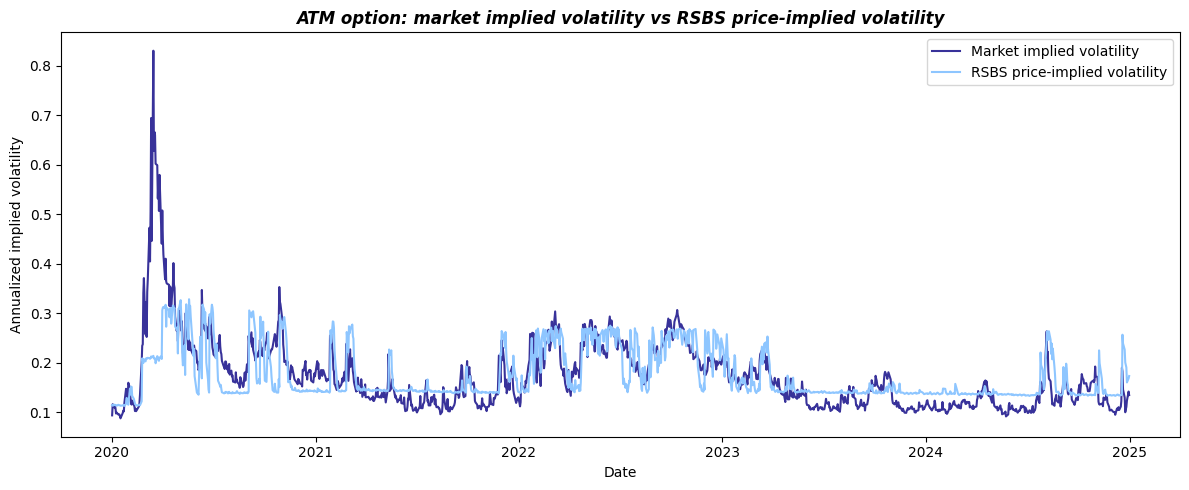

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    iv_comparison_df["date"],
    iv_comparison_df["market_iv"],
    label="Market implied volatility",
)

ax.plot(
    iv_comparison_df["date"],
    iv_comparison_df["rsbs_iv"],
    label="RSBS price-implied volatility",
)

ax.set_title("ATM option: market implied volatility vs RSBS price-implied volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized implied volatility")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## HMM training-window robustness check

This section performs a robustness check on the HMM estimation window used in the walk-forward RSBS pricing exercise. Different rolling windows are tested, ranging from short windows of a few months to longer windows of several years.

For each window, the HMM is re-estimated using only information available before each pricing month. The resulting regime volatilities, transition intensities, and predicted probabilities are then used to price the ATM 30-day option through the RSBS PDE. The models are compared using MAE, RMSE, signed pricing errors, and relative errors.

This allows us to assess whether the pricing results are driven by a specific arbitrary training-window choice or whether a longer and more stable HMM estimation window improves out-of-sample performance.

In [35]:
hmm_window_grid = [
    {"rolling_window": 2, "rolling_window_unit": "years", "min_train_obs": 252},
    {"rolling_window": 3, "rolling_window_unit": "years", "min_train_obs": 252},
    {"rolling_window": 5, "rolling_window_unit": "years", "min_train_obs": 252},
]

hmm_window_results = []

for spec in hmm_window_grid:
    print(f"Testing HMM window: {spec['rolling_window']} {spec['rolling_window_unit']}")

    try:
        wf_test, snapshots_test, failed_test = monthly_walkforward_regime_estimates(
            model_df=model_df,
            start_date="2018-01-01",
            end_date="2024-12-31",
            initial_train_start="2015-01-05",
            random_state=42,
            verbose=False,
            window_type="rolling",
            rolling_window=spec["rolling_window"],
            rolling_window_unit=spec["rolling_window_unit"],
            min_train_obs=spec["min_train_obs"],
            n_components=N_COMPONENTS,
        )

        atm_option_df_test = prepare_atm_option_pricing_df(
            final_df=final_df,
            option_price_col="option_price",
            option_type=OPTION_TYPE,
        )

        atm_pricing_df_test = merge_atm_options_with_walkforward(
            atm_option_df=atm_option_df_test,
            walkforward_regime_df=wf_test,
        )

        priced_test = price_atm_options_walkforward(
            atm_pricing_df_test,
            n_S=150,
            n_t=150,
            progress_every=None,
        )

        valid_test = priced_test.dropna(
            subset=["rs_price", "market_price"]
        ).copy()

        valid_test = valid_test[
            valid_test["success"]
            & (valid_test["market_price"] > 0)
            & (valid_test["T"] > 0)
        ].copy()

        avg_extra_metrics = {}

        for col in get_regime_sigma_columns(valid_test):
            avg_extra_metrics[f"avg_{col}"] = valid_test[col].mean()

        for col in get_regime_probability_columns(valid_test, prob_type="pred"):
            avg_extra_metrics[f"avg_{col}"] = valid_test[col].mean()

        hmm_window_results.append(
            {
                "rolling_window": spec["rolling_window"],
                "rolling_window_unit": spec["rolling_window_unit"],
                "min_train_obs": spec["min_train_obs"],
                "n_obs": len(valid_test),
                "failed_months": len(failed_test),
                "MAE": valid_test["abs_error"].mean(),
                "RMSE": np.sqrt((valid_test["pricing_error"] ** 2).mean()),
                "mean_error": valid_test["pricing_error"].mean(),
                "median_error": valid_test["pricing_error"].median(),
                "mean_relative_error": valid_test["relative_error"].mean(),
                "median_relative_error": valid_test["relative_error"].median(),
                "mean_model_price": valid_test["rs_price"].mean(),
                "mean_market_price": valid_test["market_price"].mean(),
                "mean_T_days": (valid_test["T"] * 365).mean(),
                "median_T_days": (valid_test["T"] * 365).median(),
                "mean_strike": valid_test["strike"].mean(),
                "n_components": N_COMPONENTS,
                **avg_extra_metrics,
            }
        )

    except Exception as exc:
        hmm_window_results.append(
            {
                "rolling_window": spec["rolling_window"],
                "rolling_window_unit": spec["rolling_window_unit"],
                "min_train_obs": spec["min_train_obs"],
                "n_obs": 0,
                "failed_months": np.nan,
                "MAE": np.nan,
                "RMSE": np.nan,
                "mean_error": np.nan,
                "median_error": np.nan,
                "mean_relative_error": np.nan,
                "median_relative_error": np.nan,
                "mean_model_price": np.nan,
                "mean_market_price": np.nan,
                "mean_T_days": np.nan,
                "median_T_days": np.nan,
                "mean_strike": np.nan,
                "error": repr(exc),
                "n_components": N_COMPONENTS,
            }
        )

hmm_window_results_df = (
    pd.DataFrame(hmm_window_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(hmm_window_results_df)

Model is not converging.  Current: 1803.1088707760546 is not greater than 1803.2658489380435. Delta is -0.15697816198894543


Model is not converging.  Current: 1849.7592683827386 is not greater than 1850.0633906277349. Delta is -0.3041222449962788


Testing HMM window: 2 years


Model is not converging.  Current: 1834.4829040473157 is not greater than 1834.4829162863523. Delta is -1.223903655045433e-05
Model is not converging.  Current: 1836.020261489124 is not greater than 1836.020263117813. Delta is -1.6286890058836434e-06
Model is not converging.  Current: 1833.892330057939 is not greater than 1833.8923327619605. Delta is -2.7040214263251983e-06
Model is not converging.  Current: 1608.5286003549218 is not greater than 1608.7554704580286. Delta is -0.22687010310687583
Model is not converging.  Current: 1584.9880513644332 is not greater than 1585.0797849022229. Delta is -0.09173353778965065
Model is not converging.  Current: 1553.3518150926182 is not greater than 1554.002158406568. Delta is -0.6503433139498611
Model is not converging.  Current: 1530.273178197888 is not greater than 1530.9367047922287. Delta is -0.6635265943407376
Model is not converging.  Current: 1527.111664671821 is not greater than 1527.5237710329475. Delta is -0.4121063611264617
Model is 

ATM option pricing dataframe
--------------------------------------------------------------------------------
Rows: 2498
Date range: 2015-01-05 to 2024-12-31
Mean maturity: 28.64 calendar days
Mean moneyness S/K: 0.9999
Testing HMM window: 3 years


Model is not converging.  Current: 2614.6633780861707 is not greater than 2614.7327631785447. Delta is -0.06938509237397739
Model is not converging.  Current: 2685.3646161133693 is not greater than 2685.4295489214996. Delta is -0.06493280813037927
Model is not converging.  Current: 2684.0910631617853 is not greater than 2684.234917825322. Delta is -0.14385466353678567
Model is not converging.  Current: 2690.1416909019777 is not greater than 2690.2897025690254. Delta is -0.14801166704774005
Model is not converging.  Current: 2656.0763672405324 is not greater than 2656.121444980924. Delta is -0.04507774039166179
Model is not converging.  Current: 2655.564894492487 is not greater than 2655.570635928289. Delta is -0.005741435802065098
Model is not converging.  Current: 2660.710235491391 is not greater than 2660.7895786222134. Delta is -0.0793431308225081
Model is not converging.  Current: 2661.342753264448 is not greater than 2661.426586948047. Delta is -0.08383368359864107
Model is not co

ATM option pricing dataframe
--------------------------------------------------------------------------------
Rows: 2498
Date range: 2015-01-05 to 2024-12-31
Mean maturity: 28.64 calendar days
Mean moneyness S/K: 0.9999
Testing HMM window: 5 years


Model is not converging.  Current: 3226.811057484094 is not greater than 3226.8130895291433. Delta is -0.0020320450494182296
Model is not converging.  Current: 4380.005271729218 is not greater than 4380.069426563809. Delta is -0.06415483459113602
Model is not converging.  Current: 4364.139399650141 is not greater than 4364.1758657826. Delta is -0.03646613245928165
Model is not converging.  Current: 3824.938976163216 is not greater than 3824.9407947235627. Delta is -0.001818560346691811
Model is not converging.  Current: 3832.8695771814073 is not greater than 3832.9005070845446. Delta is -0.030929903137348447
Model is not converging.  Current: 3833.233764638106 is not greater than 3833.250390968752. Delta is -0.01662633064597685
Model is not converging.  Current: 3830.0347416250625 is not greater than 3830.040533750161. Delta is -0.005792125098651013
Model is not converging.  Current: 3827.878722010053 is not greater than 3827.927704197092. Delta is -0.04898218703920065
Model is not con

ATM option pricing dataframe
--------------------------------------------------------------------------------
Rows: 2498
Date range: 2015-01-05 to 2024-12-31
Mean maturity: 28.64 calendar days
Mean moneyness S/K: 0.9999


,rolling_window,rolling_window_unit,min_train_obs,n_obs,failed_months,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price,mean_T_days,median_T_days,mean_strike,n_components,avg_sigma_low,avg_sigma_high,avg_p_low_pred,avg_p_high_pred
0,5,years,252,1748,0,17.475912,23.483391,9.116705,8.958678,0.248251,0.206398,80.868221,71.751516,28.910183,29.000000,"3,850.889588",2,0.123107,0.397526,0.786761,0.213239
1,3,years,252,1748,0,21.259267,27.829543,14.237861,12.317524,0.304670,0.246180,85.989377,71.751516,28.910183,29.000000,"3,850.889588",2,0.142238,0.468558,0.858800,0.141200
2,2,years,252,1748,0,22.543853,29.053719,14.378669,12.510671,0.334674,0.270158,86.130185,71.751516,28.910183,29.000000,"3,850.889588",2,0.155574,6.582361,0.913611,0.086389


## Statistical significance of the ATM RSBS versus BS difference

The previous table reports point estimates of MAE and RMSE. A lower MAE for RSBS is economically suggestive, but it does not by itself show whether the improvement is statistically distinguishable from sampling noise.

This section therefore treats the comparison as a paired forecast-accuracy problem. For each date $t$, both models price the same ATM option, so the relevant object is the paired loss differential:

$$
d_t^{MAE} = |e_t^{RSBS}| - |e_t^{BS}|,
$$

where $e_t^{model}=C_t^{model}-C_t^{mkt}$. A negative mean loss differential means that RSBS has lower absolute pricing error than the Black-Scholes benchmark.

Two complementary tests are reported:

1. a paired $t$-test on the absolute-error differential, using the daily paired observations;
2. a Diebold-Mariano-style test with a Newey-West/HAC correction, which is more appropriate when daily loss differentials are serially correlated.

The same Diebold-Mariano calculation is also reported for squared-error loss, so that the RMSE comparison is tested directly.


In [47]:
# ================================================================
# Statistical significance tests: ATM RSBS versus rolling-vol BS
# ================================================================

from scipy.stats import t as student_t


def newey_west_variance_of_mean(x, max_lag=None):
    """
    Newey-West/HAC variance estimate for the sample mean of x.

    Returns Var(mean(x)). Bartlett weights are used. If max_lag is None,
    a common automatic bandwidth floor(4 * (n / 100) ** (2/9)) is used.
    """
    x = pd.Series(x).dropna().astype(float).to_numpy()
    n = len(x)

    if n < 2:
        return np.nan, 0

    demeaned = x - x.mean()

    if max_lag is None:
        max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))

    max_lag = max(0, min(int(max_lag), n - 1))

    gamma_0 = np.mean(demeaned * demeaned)
    long_run_variance = gamma_0

    for lag in range(1, max_lag + 1):
        gamma_lag = np.mean(demeaned[lag:] * demeaned[:-lag])
        weight = 1.0 - lag / (max_lag + 1.0)
        long_run_variance += 2.0 * weight * gamma_lag

    return long_run_variance / n, max_lag


def diebold_mariano_hac_test(loss_model_1, loss_model_2, alternative="two-sided", max_lag=None):
    """
    Diebold-Mariano-style test for equal predictive accuracy.

    The loss differential is d_t = loss_model_1 - loss_model_2.
    Here model_1 is RSBS and model_2 is rolling-volatility BS.
    Therefore, a negative mean differential favours RSBS.
    """
    d = pd.Series(loss_model_1).astype(float) - pd.Series(loss_model_2).astype(float)
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    n = len(d)

    if n < 2:
        return {
            "n_obs": n,
            "mean_loss_diff": np.nan,
            "test_stat": np.nan,
            "p_value": np.nan,
            "hac_lag": np.nan,
        }

    var_mean, used_lag = newey_west_variance_of_mean(d, max_lag=max_lag)

    if not np.isfinite(var_mean) or var_mean <= 0:
        test_stat = np.nan
        p_value = np.nan
    else:
        test_stat = d.mean() / np.sqrt(var_mean)

        if alternative == "less":
            p_value = student_t.cdf(test_stat, df=n - 1)
        elif alternative == "greater":
            p_value = 1.0 - student_t.cdf(test_stat, df=n - 1)
        else:
            p_value = 2.0 * (1.0 - student_t.cdf(abs(test_stat), df=n - 1))

    return {
        "n_obs": n,
        "mean_loss_diff": d.mean(),
        "test_stat": test_stat,
        "p_value": p_value,
        "hac_lag": used_lag,
    }


atm_test_df = valid_comparison.dropna(
    subset=["rs_error", "bs_error", "rs_abs_error", "bs_abs_error", "market_price"]
).copy()

atm_test_df = atm_test_df[
    (atm_test_df["market_price"] > 0) & (atm_test_df["success"])
].copy()

atm_test_df["abs_loss_diff_rs_minus_bs"] = (
    atm_test_df["rs_abs_error"] - atm_test_df["bs_abs_error"]
)

atm_test_df["squared_loss_diff_rs_minus_bs"] = (
    atm_test_df["rs_error"] ** 2 - atm_test_df["bs_error"] ** 2
)

n_atm_tests = len(atm_test_df)
mean_abs_diff = atm_test_df["abs_loss_diff_rs_minus_bs"].mean()
std_abs_diff = atm_test_df["abs_loss_diff_rs_minus_bs"].std(ddof=1)
se_abs_diff = std_abs_diff / np.sqrt(n_atm_tests)
paired_t_stat = mean_abs_diff / se_abs_diff
paired_t_p_two_sided = 2.0 * (1.0 - student_t.cdf(abs(paired_t_stat), df=n_atm_tests - 1))
paired_t_p_less = student_t.cdf(paired_t_stat, df=n_atm_tests - 1)
paired_t_ci_95 = (
    mean_abs_diff - student_t.ppf(0.975, df=n_atm_tests - 1) * se_abs_diff,
    mean_abs_diff + student_t.ppf(0.975, df=n_atm_tests - 1) * se_abs_diff,
)

mae_rsbs = atm_test_df["rs_abs_error"].mean()
mae_bs = atm_test_df["bs_abs_error"].mean()
rmse_rsbs = np.sqrt((atm_test_df["rs_error"] ** 2).mean())
rmse_bs = np.sqrt((atm_test_df["bs_error"] ** 2).mean())
mean_market_price = atm_test_df["market_price"].mean()

mae_improvement = mae_bs - mae_rsbs
mae_improvement_pct_vs_bs = mae_improvement / mae_bs
mae_improvement_pct_vs_market = mae_improvement / mean_market_price
rmse_improvement = rmse_bs - rmse_rsbs
rmse_improvement_pct_vs_bs = rmse_improvement / rmse_bs

mae_dm_two_sided = diebold_mariano_hac_test(
    atm_test_df["rs_abs_error"],
    atm_test_df["bs_abs_error"],
    alternative="two-sided",
)

mae_dm_less = diebold_mariano_hac_test(
    atm_test_df["rs_abs_error"],
    atm_test_df["bs_abs_error"],
    alternative="less",
)

rmse_dm_two_sided = diebold_mariano_hac_test(
    atm_test_df["rs_error"] ** 2,
    atm_test_df["bs_error"] ** 2,
    alternative="two-sided",
)

rmse_dm_less = diebold_mariano_hac_test(
    atm_test_df["rs_error"] ** 2,
    atm_test_df["bs_error"] ** 2,
    alternative="less",
)

atm_statistical_test_summary = pd.DataFrame(
    [
        {
            "comparison": "Economic magnitude",
            "loss": "Absolute error / MAE",
            "n_obs": n_atm_tests,
            "RSBS": mae_rsbs,
            "BS": mae_bs,
            "BS_minus_RSBS": mae_improvement,
            "% improvement vs BS": mae_improvement_pct_vs_bs,
            "% of mean market price": mae_improvement_pct_vs_market,
            "test_stat": np.nan,
            "p_value_two_sided": np.nan,
            "p_value_one_sided_RSBS_better": np.nan,
            "HAC_lag": np.nan,
        },
        {
            "comparison": "Economic magnitude",
            "loss": "Squared error / RMSE",
            "n_obs": n_atm_tests,
            "RSBS": rmse_rsbs,
            "BS": rmse_bs,
            "BS_minus_RSBS": rmse_improvement,
            "% improvement vs BS": rmse_improvement_pct_vs_bs,
            "% of mean market price": rmse_improvement / mean_market_price,
            "test_stat": np.nan,
            "p_value_two_sided": np.nan,
            "p_value_one_sided_RSBS_better": np.nan,
            "HAC_lag": np.nan,
        },
        {
            "comparison": "Paired t-test",
            "loss": "|RSBS error| - |BS error|",
            "n_obs": n_atm_tests,
            "RSBS": mae_rsbs,
            "BS": mae_bs,
            "BS_minus_RSBS": mae_improvement,
            "% improvement vs BS": mae_improvement_pct_vs_bs,
            "% of mean market price": mae_improvement_pct_vs_market,
            "test_stat": paired_t_stat,
            "p_value_two_sided": paired_t_p_two_sided,
            "p_value_one_sided_RSBS_better": paired_t_p_less,
            "HAC_lag": np.nan,
        },
        {
            "comparison": "Diebold-Mariano HAC",
            "loss": "Absolute error",
            "n_obs": mae_dm_two_sided["n_obs"],
            "RSBS": mae_rsbs,
            "BS": mae_bs,
            "BS_minus_RSBS": mae_improvement,
            "% improvement vs BS": mae_improvement_pct_vs_bs,
            "% of mean market price": mae_improvement_pct_vs_market,
            "test_stat": mae_dm_two_sided["test_stat"],
            "p_value_two_sided": mae_dm_two_sided["p_value"],
            "p_value_one_sided_RSBS_better": mae_dm_less["p_value"],
            "HAC_lag": mae_dm_two_sided["hac_lag"],
        },
        {
            "comparison": "Diebold-Mariano HAC",
            "loss": "Squared error",
            "n_obs": rmse_dm_two_sided["n_obs"],
            "RSBS": rmse_rsbs,
            "BS": rmse_bs,
            "BS_minus_RSBS": rmse_improvement,
            "% improvement vs BS": rmse_improvement_pct_vs_bs,
            "% of mean market price": rmse_improvement / mean_market_price,
            "test_stat": rmse_dm_two_sided["test_stat"],
            "p_value_two_sided": rmse_dm_two_sided["p_value"],
            "p_value_one_sided_RSBS_better": rmse_dm_less["p_value"],
            "HAC_lag": rmse_dm_two_sided["hac_lag"],
        },
    ]
)

print("ATM RSBS versus rolling-volatility BS statistical comparison")
print("-" * 80)
print(
    "Loss differential is RSBS loss minus BS loss. "
    "Negative values favour RSBS."
)
print(
    f"Paired 95% CI for mean absolute-error differential: "
    f"[{paired_t_ci_95[0]:.4f}, {paired_t_ci_95[1]:.4f}]"
)

display(atm_statistical_test_summary)

ATM RSBS versus rolling-volatility BS statistical comparison
--------------------------------------------------------------------------------
Loss differential is RSBS loss minus BS loss. Negative values favour RSBS.
Paired 95% CI for mean absolute-error differential: [-3.6231, -1.2849]


,comparison,loss,n_obs,RSBS,BS,BS_minus_RSBS,% improvement vs BS,% of mean market price,test_stat,p_value_two_sided,p_value_one_sided_RSBS_better,HAC_lag
0,Economic magnitude,Absolute error / MAE,1249,15.206719,17.660729,2.454011,0.138953,0.029245,NaN,NaN,NaN,NaN
1,Economic magnitude,Squared error / RMSE,1249,21.152657,26.903852,5.751195,0.213768,0.068537,NaN,NaN,NaN,NaN
2,Paired t-test,|RSBS error| - |BS error|,1249,15.206719,17.660729,2.454011,0.138953,0.029245,-4.118155,0.000041,0.000020,NaN
3,Diebold-Mariano HAC,Absolute error,1249,15.206719,17.660729,2.454011,0.138953,0.029245,-1.735999,0.082811,0.041405,7.000000
4,Diebold-Mariano HAC,Squared error,1249,21.152657,26.903852,5.751195,0.213768,0.068537,-1.462862,0.143757,0.071878,7.000000


# 6. Out-of-the-money option pricing analysis

This section repeats the pricing exercise for out-of-the-money SPX call options with target moneyness

$$
\frac{S_t}{K_t} \approx 0.90.
$$

Since these are call options, the strike is above the spot index level and the option is out of the money at the valuation date.

The goal is to test whether the historical regime-switching framework remains informative for options that are more sensitive to tail movements, volatility skew, and risk-neutral expectations. The same walk-forward HMM regime estimates are used as in the ATM analysis.


In [36]:
OTM_DATA_FILE = find_data_file("option_price_otm_90.csv")
OTM_LABEL = "OTM 90%"
USE_ACTUAL_EXPIRY_OTM = False  # baseline thesis setting: fixed 30-day maturity

print(f"OTM data file: {OTM_DATA_FILE}")

otm_df = pd.read_csv(
    OTM_DATA_FILE,
    sep=";",
    decimal=","
).copy()

otm_df["date"] = pd.to_datetime(otm_df["date"], errors="coerce")
otm_df["expiry_date"] = pd.to_datetime(otm_df["expiry_date"], errors="coerce")

for col in ["spx", "r_3m", "strike", "option_price"]:
    otm_df[col] = pd.to_numeric(otm_df[col], errors="coerce")

otm_df = (
    otm_df[["date", "spx", "r_3m", "strike", "expiry_date", "option_price"]]
    .dropna()
    .sort_values("date")
    .drop_duplicates(subset=["date"], keep="last")
    .reset_index(drop=True)
)

otm_df["moneyness"] = otm_df["spx"] / otm_df["strike"]
otm_df["days_to_expiry"] = (otm_df["expiry_date"] - otm_df["date"]).dt.days

print("OTM dataset:")
print(otm_df.shape)
display(otm_df.head())

display(
    otm_df[["option_price", "moneyness", "days_to_expiry"]].describe()
)


OTM data file: dataset/option_price_otm_90.csv
OTM dataset:
(2498, 8)


,date,spx,r_3m,strike,expiry_date,option_price,moneyness,days_to_expiry
0,2015-01-05,"2,020.577884",0.000300,"2,225.000000",2015-01-30,0.120000,0.908125,25
1,2015-01-06,"2,002.613588",0.000300,"2,225.000000",2015-01-30,0.120000,0.900051,24
2,2015-01-07,"2,025.901051",0.000300,"2,250.000000",2015-02-06,0.180000,0.900400,30
3,2015-01-08,"2,062.143555",0.000300,"2,275.000000",2015-02-06,0.100000,0.906437,29
4,2015-01-09,"2,044.809900",0.000200,"2,250.000000",2015-02-06,0.150000,0.908804,28


,option_price,moneyness,days_to_expiry
count,"2,498.000000","2,498.000000","2,498.000000"
mean,1.084816,0.908414,28.649720
std,4.065116,0.009755,1.408610
min,0.050000,0.900002,23.000000
25%,0.100000,0.901625,28.000000
50%,0.220000,0.905208,29.000000
75%,0.600000,0.911395,30.000000
max,88.550000,0.969426,30.000000


## Preparing OTM option inputs

The pricing dataframe is constructed in the same way as in the ATM exercise. For each date, the model uses the observed index level, strike, short-term interest rate, and market option price.

The baseline OTM thesis specification fixes maturity at 30 calendar days (`USE_ACTUAL_EXPIRY_OTM = False`). The switch is left in the notebook so the exercise can be rerun with the observed `expiry_date` if required.


In [37]:
def prepare_option_pricing_df(
    df,
    option_price_col="option_price",
    option_type=OPTION_TYPE,
    use_actual_expiry=False,
    maturity_days=ATM_MATURITY_DAYS,
):
    pricing_df = df[
        ["date", "spx", "r_3m", "strike", "expiry_date", option_price_col]
    ].copy()

    pricing_df["date"] = pd.to_datetime(pricing_df["date"], errors="coerce")
    pricing_df["expiry_date"] = pd.to_datetime(pricing_df["expiry_date"], errors="coerce")

    for col in ["spx", "r_3m", "strike", option_price_col]:
        pricing_df[col] = pd.to_numeric(pricing_df[col], errors="coerce")

    pricing_df["market_price"] = pricing_df[option_price_col]

    if use_actual_expiry:
        pricing_df["days_to_expiry"] = (
            pricing_df["expiry_date"] - pricing_df["date"]
        ).dt.days
        pricing_df["T"] = pricing_df["days_to_expiry"] / 365
    else:
        pricing_df["days_to_expiry"] = maturity_days
        pricing_df["T"] = maturity_days / 365

    pricing_df["option_type"] = option_type
    pricing_df["moneyness"] = pricing_df["spx"] / pricing_df["strike"]

    pricing_df = pricing_df[
        pricing_df["date"].notna()
        & (pricing_df["spx"] > 0)
        & (pricing_df["strike"] > 0)
        & (pricing_df["T"] > 0)
        & pricing_df["r_3m"].notna()
        & (pricing_df["market_price"] > 0)
    ].copy()

    return pricing_df.sort_values("date").reset_index(drop=True)


otm_option_df = prepare_option_pricing_df(
    df=otm_df,
    option_price_col="option_price",
    option_type=OPTION_TYPE,
    use_actual_expiry=USE_ACTUAL_EXPIRY_OTM,
    maturity_days=ATM_MATURITY_DAYS,
)

otm_pricing_df = merge_atm_options_with_walkforward(
    atm_option_df=otm_option_df,
    walkforward_regime_df=walkforward_regime_df,
)

print("OTM option dataframe:")
print(otm_option_df.shape)

print("OTM pricing dataframe after merging with walk-forward regimes:")
print(otm_pricing_df.shape)

display(
    otm_pricing_df[
        get_existing_columns(
            otm_pricing_df,
            [
                "date",
                "spx",
                "strike",
                "moneyness",
                "T",
                "r_3m",
                "market_price",
                "sigma_low",
                "sigma_high",
                "p_low_pred",
                "p_high_pred",
            ],
        )
    ].head()
)

OTM option dataframe:
(2498, 11)
OTM pricing dataframe after merging with walk-forward regimes:
(1249, 24)


,date,spx,strike,moneyness,T,r_3m,market_price,sigma_low,sigma_high,p_low_pred,p_high_pred
0,2020-01-02,"3,257.847787","3,600.000000",0.904958,0.082192,0.015100,0.050000,0.104364,0.260918,0.981368,0.018632
1,2020-01-03,"3,234.848563","3,550.000000",0.911225,0.082192,0.014900,0.050000,0.104364,0.260918,0.978258,0.021742
2,2020-01-06,"3,246.282557","3,425.000000",0.947820,0.082192,0.015300,0.320000,0.104364,0.260918,0.973372,0.026628
3,2020-01-07,"3,237.182452","3,450.000000",0.938314,0.082192,0.015100,0.150000,0.104364,0.260918,0.978970,0.021030
4,2020-01-08,"3,253.045944","3,600.000000",0.903624,0.082192,0.015100,0.050000,0.104364,0.260918,0.980179,0.019821


## Original RSBS and rolling-volatility Black-Scholes pricing

The first OTM pricing exercise uses exactly the same regime-switching Black-Scholes machinery as before. The HMM regime volatilities, transition intensities, and one-step-ahead predicted regime probabilities are merged with the OTM option data by date.

The original regime-switching price is then compared with a rolling-volatility Black-Scholes benchmark. This benchmark uses the same strike, spot, maturity, and interest rate, but replaces the regime-switching structure with the 21-day lagged historical volatility.

In [38]:
priced_otm_options = price_atm_options_walkforward(
    otm_pricing_df,
    n_S=150,
    n_t=150,
    progress_every=50,
)

display(
    priced_otm_options[
        get_existing_columns(
            priced_otm_options,
            [
                "date",
                "spx",
                "strike",
                "moneyness",
                "T",
                "market_price",
                "rs_price",
                "pricing_error",
                "abs_error",
                "relative_error",
                "success",
            ],
        )
    ].head()
)


otm_comparison_df = priced_otm_options.copy()
otm_comparison_df["date"] = pd.to_datetime(otm_comparison_df["date"])

otm_comparison_df = otm_comparison_df.merge(
    bs_vol_df[["date", "bs_rolling_vol"]],
    on="date",
    how="left",
)

otm_comparison_df["bs_price"] = otm_comparison_df.apply(
    lambda row: black_scholes_price(
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        sigma=row["bs_rolling_vol"],
        option_type=row["option_type"],
    ),
    axis=1,
)

otm_comparison_df["rs_error"] = (
    otm_comparison_df["rs_price"] - otm_comparison_df["market_price"]
)
otm_comparison_df["bs_error"] = (
    otm_comparison_df["bs_price"] - otm_comparison_df["market_price"]
)

otm_comparison_df["rs_abs_error"] = otm_comparison_df["rs_error"].abs()
otm_comparison_df["bs_abs_error"] = otm_comparison_df["bs_error"].abs()

otm_comparison_df["rs_relative_error"] = (
    otm_comparison_df["rs_abs_error"] / otm_comparison_df["market_price"]
)
otm_comparison_df["bs_relative_error"] = (
    otm_comparison_df["bs_abs_error"] / otm_comparison_df["market_price"]
)

valid_otm_comparison = otm_comparison_df.dropna(
    subset=["market_price", "rs_price", "bs_price"]
).copy()

valid_otm_comparison = valid_otm_comparison[
    valid_otm_comparison["success"]
    & (valid_otm_comparison["market_price"] > 0)
].copy()

print("Valid OTM comparison observations:", len(valid_otm_comparison))
display(valid_otm_comparison.head())


otm_summary = pd.DataFrame(
    [
        summarize_model_errors(
            valid_otm_comparison,
            "Regime-Switching BS",
            "rs_price",
            "rs_error",
            "rs_abs_error",
            "rs_relative_error",
        ),
        summarize_model_errors(
            valid_otm_comparison,
            "Rolling-volatility BS",
            "bs_price",
            "bs_error",
            "bs_abs_error",
            "bs_relative_error",
        ),
    ]
)

display(otm_summary)


otm_extra_summary = pd.DataFrame(
    [
        {
            "dataset": OTM_LABEL,
            "n_obs": len(valid_otm_comparison),
            "mean_moneyness": valid_otm_comparison["moneyness"].mean(),
            "median_moneyness": valid_otm_comparison["moneyness"].median(),
            "mean_T_days": (valid_otm_comparison["T"] * 365).mean(),
            "median_T_days": (valid_otm_comparison["T"] * 365).median(),
            "mean_market_price": valid_otm_comparison["market_price"].mean(),
            "mean_RSBS_price": valid_otm_comparison["rs_price"].mean(),
            "mean_BS_price": valid_otm_comparison["bs_price"].mean(),
            "RSBS_MAE": valid_otm_comparison["rs_abs_error"].mean(),
            "BS_MAE": valid_otm_comparison["bs_abs_error"].mean(),
            "RSBS_RMSE": np.sqrt((valid_otm_comparison["rs_error"] ** 2).mean()),
            "BS_RMSE": np.sqrt((valid_otm_comparison["bs_error"] ** 2).mean()),
        }
    ]
)

display(otm_extra_summary)

Priced 50 / 1249 observations
Priced 100 / 1249 observations
Priced 150 / 1249 observations
Priced 200 / 1249 observations
Priced 250 / 1249 observations
Priced 300 / 1249 observations
Priced 350 / 1249 observations
Priced 400 / 1249 observations
Priced 450 / 1249 observations
Priced 500 / 1249 observations
Priced 550 / 1249 observations
Priced 600 / 1249 observations
Priced 650 / 1249 observations
Priced 700 / 1249 observations
Priced 750 / 1249 observations
Priced 800 / 1249 observations
Priced 850 / 1249 observations
Priced 900 / 1249 observations
Priced 950 / 1249 observations
Priced 1000 / 1249 observations
Priced 1050 / 1249 observations
Priced 1100 / 1249 observations
Priced 1150 / 1249 observations
Priced 1200 / 1249 observations


,date,spx,strike,moneyness,T,market_price,rs_price,pricing_error,abs_error,relative_error,success
0,2020-01-02,"3,257.847787","3,600.000000",0.904958,0.082192,0.050000,0.729588,0.679588,0.679588,13.591755,True
1,2020-01-03,"3,234.848563","3,550.000000",0.911225,0.082192,0.050000,0.961118,0.911118,0.911118,18.222354,True
2,2020-01-06,"3,246.282557","3,425.000000",0.947820,0.082192,0.320000,5.049876,4.729876,4.729876,14.780862,True
3,2020-01-07,"3,237.182452","3,450.000000",0.938314,0.082192,0.150000,3.153110,3.003110,3.003110,20.020730,True
4,2020-01-08,"3,253.045944","3,600.000000",0.903624,0.082192,0.050000,0.701236,0.651236,0.651236,13.024719,True


Valid OTM comparison observations: 1249


,date,spx,r_3m,strike,expiry_date,option_price,market_price,days_to_expiry,T,option_type,moneyness,n_components,sigma_state_0,sigma_state_1,p_state_0_pred,p_state_1_pred,Q_00,Q_01,Q_10,Q_11,sigma_low,sigma_high,p_low_pred,p_high_pred,rs_price,success,error_message,V_state_0,p_state_0_used,V_state_1,p_state_1_used,V_low,V_high,pricing_error,abs_error,relative_error,bs_rolling_vol,bs_price,rs_error,bs_error,rs_abs_error,bs_abs_error,rs_relative_error,bs_relative_error
0,2020-01-02,"3,257.847787",0.015100,"3,600.000000",2020-01-31,0.050000,0.050000,30,0.082192,call,0.904958,2,0.104364,0.260918,0.981368,0.018632,-2.724127,2.724127,12.433389,-12.433389,0.104364,0.260918,0.981368,0.018632,0.729588,True,,0.622273,0.981368,6.381861,0.018632,0.622273,6.381861,0.679588,0.679588,13.591755,0.076405,0.000051,0.679588,-0.049949,0.679588,0.049949,13.591755,0.998972
1,2020-01-03,"3,234.848563",0.014900,"3,550.000000",2020-01-31,0.050000,0.050000,30,0.082192,call,0.911225,2,0.104364,0.260918,0.978258,0.021742,-2.724127,2.724127,12.433389,-12.433389,0.104364,0.260918,0.978258,0.021742,0.961118,True,,0.810305,0.978258,7.746665,0.021742,0.810305,7.746665,0.911118,0.911118,18.222354,0.070846,0.000044,0.911118,-0.049956,0.911118,0.049956,18.222354,0.999121
2,2020-01-06,"3,246.282557",0.015300,"3,425.000000",2020-02-05,0.320000,0.320000,30,0.082192,call,0.947820,2,0.104364,0.260918,0.973372,0.026628,-2.724127,2.724127,12.433389,-12.433389,0.104364,0.260918,0.973372,0.026628,5.049876,True,,4.545014,0.973372,23.504530,0.026628,4.545014,23.504530,4.729876,4.729876,14.780862,0.071522,0.116324,4.729876,-0.203676,4.729876,0.203676,14.780862,0.636486
3,2020-01-07,"3,237.182452",0.015100,"3,450.000000",2020-02-05,0.150000,0.150000,30,0.082192,call,0.938314,2,0.104364,0.260918,0.978970,0.021030,-2.724127,2.724127,12.433389,-12.433389,0.104364,0.260918,0.978970,0.021030,3.153110,True,,2.835314,0.978970,17.947155,0.021030,2.835314,17.947155,3.003110,3.003110,20.020730,0.070116,0.017573,3.003110,-0.132427,3.003110,0.132427,20.020730,0.882845
4,2020-01-08,"3,253.045944",0.015100,"3,600.000000",2020-02-07,0.050000,0.050000,30,0.082192,call,0.903624,2,0.104364,0.260918,0.980179,0.019821,-2.724127,2.724127,12.433389,-12.433389,0.104364,0.260918,0.980179,0.019821,0.701236,True,,0.591604,0.980179,6.122814,0.019821,0.591604,6.122814,0.651236,0.651236,13.024719,0.072063,0.000009,0.651236,-0.049991,0.651236,0.049991,13.024719,0.999829


,model,n_obs,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price
0,Regime-Switching BS,1249,7.924672,10.541422,6.968310,4.813464,14.431261,11.268359,8.951401,1.983090
1,Rolling-volatility BS,1249,6.070275,20.525231,5.723489,0.253188,2.854425,0.995982,7.706580,1.983090


,dataset,n_obs,mean_moneyness,median_moneyness,mean_T_days,median_T_days,mean_market_price,mean_RSBS_price,mean_BS_price,RSBS_MAE,BS_MAE,RSBS_RMSE,BS_RMSE
0,OTM 90%,1249,0.908165,0.904734,30.000000,30.000000,1.983090,8.951401,7.706580,7.924672,6.070275,10.541422,20.525231


## Price and error diagnostics

The next plots compare the observed OTM market price with the original RSBS price and the rolling-volatility Black-Scholes benchmark.

Because OTM options often have low market prices, relative errors can become mechanically large. For this reason, the analysis focuses not only on relative errors, but also on absolute errors and rolling average absolute errors.

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


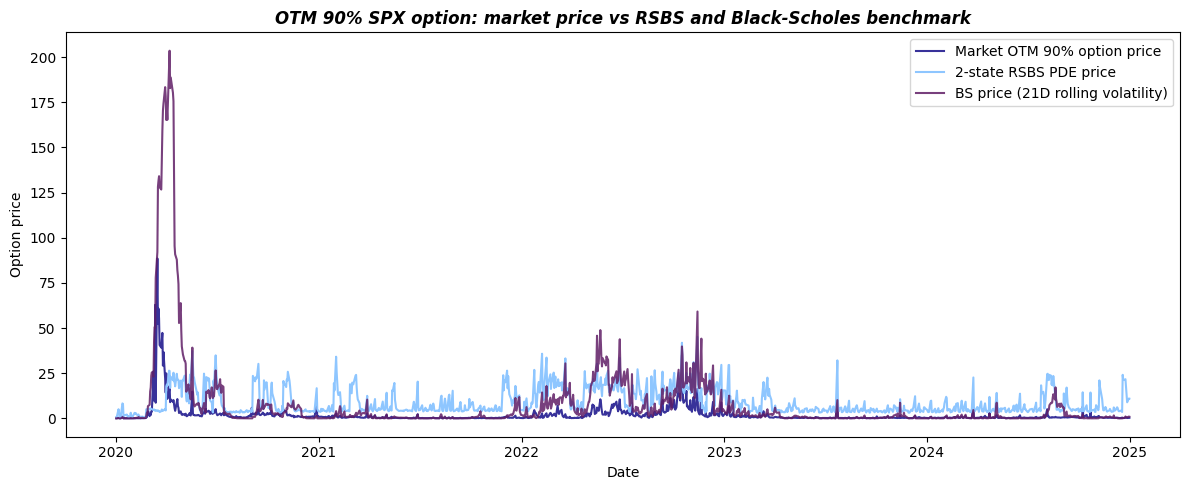

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


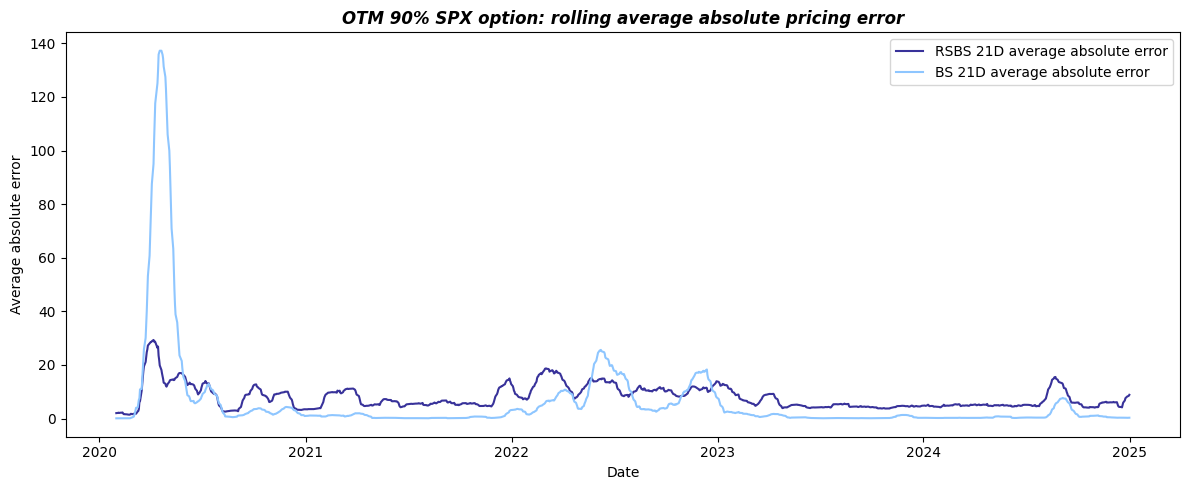

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_otm_comparison["date"],
    valid_otm_comparison["market_price"],
    label=f"Market {OTM_LABEL} option price",
)

ax.plot(
    valid_otm_comparison["date"],
    valid_otm_comparison["rs_price"],
    label=f"{N_COMPONENTS}-state RSBS PDE price",
)

ax.plot(
    valid_otm_comparison["date"],
    valid_otm_comparison["bs_price"],
    label=f"BS price ({ROLLING_BS_WINDOW}D rolling volatility)",
    alpha=0.85,
)

ax.set_title(f"{OTM_LABEL} SPX option: market price vs RSBS and Black-Scholes benchmark")
ax.set_xlabel("Date")
ax.set_ylabel("Option price")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()


valid_otm_comparison["rs_abs_error_roll"] = (
    valid_otm_comparison["rs_abs_error"]
    .rolling(ERROR_ROLLING_WINDOW)
    .mean()
)

valid_otm_comparison["bs_abs_error_roll"] = (
    valid_otm_comparison["bs_abs_error"]
    .rolling(ERROR_ROLLING_WINDOW)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_otm_comparison["date"],
    valid_otm_comparison["rs_abs_error_roll"],
    label=f"RSBS {ERROR_ROLLING_WINDOW}D average absolute error",
)

ax.plot(
    valid_otm_comparison["date"],
    valid_otm_comparison["bs_abs_error_roll"],
    label=f"BS {ERROR_ROLLING_WINDOW}D average absolute error",
)

ax.set_title(f"{OTM_LABEL} SPX option: rolling average absolute pricing error")
ax.set_xlabel("Date")
ax.set_ylabel("Average absolute error")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Threshold analysis for low-priced OTM options

Very cheap OTM options can generate mechanically large relative errors. The table below repeats the RSBS versus rolling-volatility Black-Scholes comparison after excluding observations with market prices below 0.5, 1.0, and 2.0 index points.


In [40]:
threshold_results = []

for threshold in [0.5, 1.0, 2.0]:
    tmp = valid_otm_comparison[
        valid_otm_comparison["market_price"] >= threshold
    ].copy()

    threshold_results.append(
        summarize_model_errors(
            tmp,
            f"RSBS, market >= {threshold}",
            "rs_price",
            "rs_error",
            "rs_abs_error",
            "rs_relative_error",
        )
    )

    threshold_results.append(
        summarize_model_errors(
            tmp,
            f"Rolling BS, market >= {threshold}",
            "bs_price",
            "bs_error",
            "bs_abs_error",
            "bs_relative_error",
        )
    )

threshold_otm_summary = pd.DataFrame(threshold_results)
display(threshold_otm_summary)


,model,n_obs,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price
0,"RSBS, market >= 0.5",643,10.735256,13.545959,8.877564,8.628793,6.877922,4.896560,12.492665,3.615101
1,"Rolling BS, market >= 0.5",643,11.150852,28.550417,10.671902,2.596509,3.172202,1.430029,14.287003,3.615101
2,"RSBS, market >= 1.0",429,12.399688,15.260637,9.615316,10.871229,4.791058,3.569745,14.685549,5.070233
3,"Rolling BS, market >= 1.0",429,15.822115,34.869787,15.335366,5.484654,3.451243,2.026241,20.405599,5.070233
4,"RSBS, market >= 2.0",273,13.669090,16.896272,9.293648,11.478909,3.328720,2.524502,16.439436,7.145788
5,"Rolling BS, market >= 2.0",273,22.259014,43.375192,21.681069,10.080077,3.623293,2.152325,28.826856,7.145788


## Implied-volatility comparison: market price versus RSBS price

The final OTM diagnostic compares the Black-Scholes implied volatility backed out from the observed market price with the Black-Scholes implied volatility backed out from the regime-switching Black-Scholes price.

For each date $t$, the implied volatility is computed by inverting the Black-Scholes formula using the same option inputs used in the OTM pricing exercise:

$$
S_t,\quad K_t,\quad T_t,\quad r_t.
$$

In the baseline OTM specification, $T_t$ is fixed at 30 calendar days because `USE_ACTUAL_EXPIRY_OTM = False`. If the switch is set to `True`, the same code instead uses the observed maturity implied by `expiry_date`.

The two implied-volatility series are therefore

$$
\sigma^{mkt,IV}_t
=
BS^{-1}
\left(
C_t^{mkt}; S_t,K_t,T_t,r_t
\right),
$$

and

$$
\sigma^{RSBS,IV}_t
=
BS^{-1}
\left(
C_t^{RSBS}; S_t,K_t,T_t,r_t
\right).
$$

This diagnostic evaluates whether the RSBS price embeds too much or too little volatility relative to the market price. The rolling-volatility Black-Scholes benchmark is also shown as a reference, but the main comparison is between market implied volatility and RSBS price-implied volatility.

OTM implied-volatility input consistency check
--------------------------------------------------------------------------------
The IV inversion uses the same S, K, T, and r used for OTM pricing.
USE_ACTUAL_EXPIRY_OTM: False
Maximum |T - days_to_expiry / 365|: 0.000000000000
Mean selected maturity in days: 30.00
Median selected maturity in days: 30.00
Mean actual expiry maturity in days: 28.86
Median actual expiry maturity in days: 29.00

Valid OTM implied-volatility comparison observations: 1249


,date,spx,strike,moneyness,days_to_expiry,actual_days_to_expiry,T,r_3m,market_price,rs_price,bs_price,market_iv_otm,rsbs_iv_otm,bs_iv_otm,iv_error_otm,abs_iv_error_otm
0,2020-01-02,"3,257.847787","3,600.000000",0.904958,30,29,0.082192,0.015100,0.050000,0.729588,0.000051,0.116190,0.155788,0.076405,0.039598,0.039598
1,2020-01-03,"3,234.848563","3,550.000000",0.911225,30,28,0.082192,0.014900,0.050000,0.961118,0.000044,0.108875,0.152481,0.070846,0.043606,0.043606
2,2020-01-06,"3,246.282557","3,425.000000",0.947820,30,30,0.082192,0.015300,0.320000,5.049876,0.116324,0.080858,0.133683,0.071522,0.052825,0.052825
3,2020-01-07,"3,237.182452","3,450.000000",0.938314,30,29,0.082192,0.015100,0.150000,3.153110,0.017573,0.086043,0.137262,0.070116,0.051219,0.051219
4,2020-01-08,"3,253.045944","3,600.000000",0.903624,30,30,0.082192,0.015100,0.050000,0.701236,0.000009,0.117782,0.156964,0.072063,0.039182,0.039182


,series,mean,median,std,min,max
0,Market implied volatility,0.151854,0.137512,0.049178,0.073329,0.669076
1,RSBS price-implied volatility,0.218460,0.202257,0.044075,0.125339,0.348292
2,Rolling BS volatility,0.176763,0.143589,0.122862,0.054180,0.975554
3,RSBS IV - Market IV,0.066606,0.064551,0.043718,-0.438494,0.162752
4,|RSBS IV - Market IV|,0.072327,0.065020,0.033404,0.000373,0.438494


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


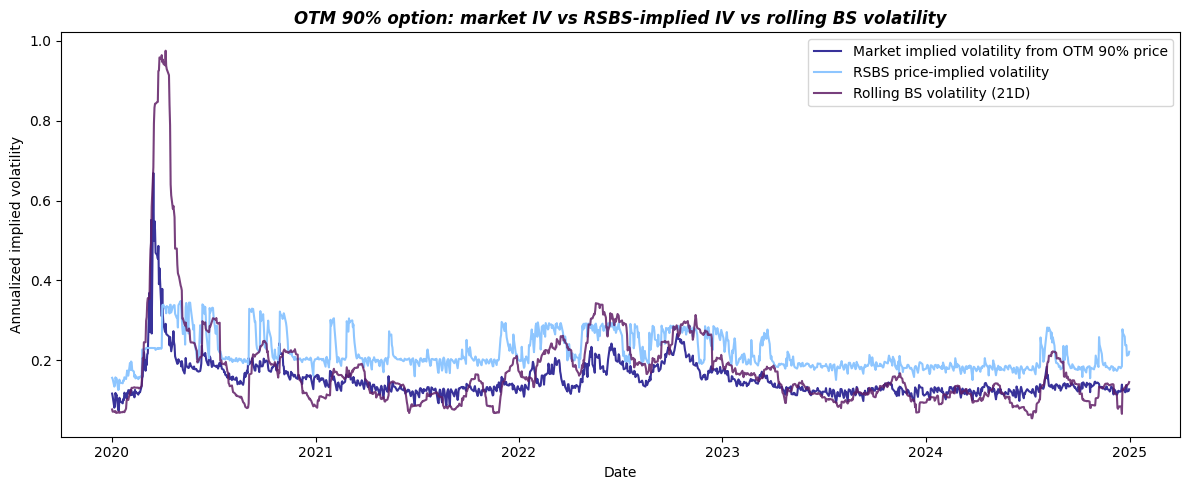

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


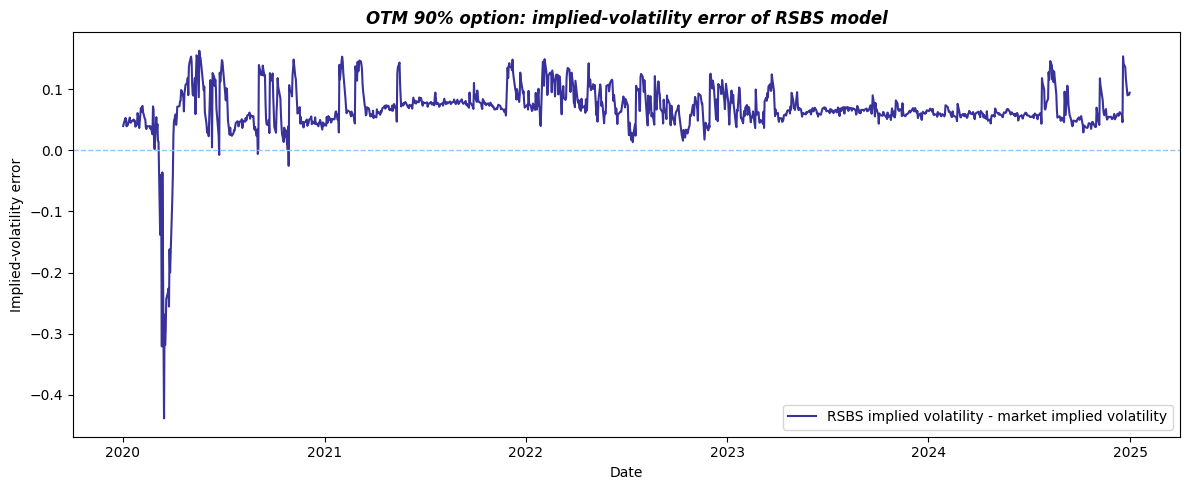

In [41]:
required_otm_iv_cols = [
    "date",
    "spx",
    "strike",
    "T",
    "r_3m",
    "market_price",
    "rs_price",
    "bs_price",
    "bs_rolling_vol",
    "option_type",
]

missing_otm_iv_cols = [
    col for col in required_otm_iv_cols
    if col not in valid_otm_comparison.columns
]

if missing_otm_iv_cols:
    raise ValueError(
        "The following columns are required for the OTM IV comparison "
        f"but are missing from valid_otm_comparison: {missing_otm_iv_cols}"
    )

valid_otm_comparison = valid_otm_comparison.copy()
valid_otm_comparison["date"] = pd.to_datetime(valid_otm_comparison["date"], errors="coerce")

# Check that the IV inversion uses the same maturity T used in OTM pricing.
if "days_to_expiry" in valid_otm_comparison.columns:
    valid_otm_comparison["T_from_days_to_expiry"] = (
        valid_otm_comparison["days_to_expiry"] / 365.0
    )

    max_T_difference = (
        valid_otm_comparison["T"] - valid_otm_comparison["T_from_days_to_expiry"]
    ).abs().max()

    print("OTM implied-volatility input consistency check")
    print("-" * 80)
    print("The IV inversion uses the same S, K, T, and r used for OTM pricing.")
    print(f"USE_ACTUAL_EXPIRY_OTM: {USE_ACTUAL_EXPIRY_OTM}")
    print(f"Maximum |T - days_to_expiry / 365|: {max_T_difference:.12f}")
    print(f"Mean selected maturity in days: {valid_otm_comparison['days_to_expiry'].mean():.2f}")
    print(f"Median selected maturity in days: {valid_otm_comparison['days_to_expiry'].median():.2f}")

    if max_T_difference > 1e-10:
        raise ValueError(
            "Mismatch between stored T and days_to_expiry / 365. "
            "Check prepare_option_pricing_df."
        )

if "expiry_date" in valid_otm_comparison.columns:
    valid_otm_comparison["expiry_date"] = pd.to_datetime(
        valid_otm_comparison["expiry_date"],
        errors="coerce",
    )

    valid_otm_comparison["actual_days_to_expiry"] = (
        valid_otm_comparison["expiry_date"] - valid_otm_comparison["date"]
    ).dt.days

    print(f"Mean actual expiry maturity in days: {valid_otm_comparison['actual_days_to_expiry'].mean():.2f}")
    print(f"Median actual expiry maturity in days: {valid_otm_comparison['actual_days_to_expiry'].median():.2f}")

valid_otm_comparison["market_iv_otm"] = valid_otm_comparison.apply(
    lambda row: black_scholes_implied_vol(
        market_price=row["market_price"],
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        option_type=row["option_type"],
    ),
    axis=1,
)

valid_otm_comparison["rsbs_iv_otm"] = valid_otm_comparison.apply(
    lambda row: black_scholes_implied_vol(
        market_price=row["rs_price"],
        S0=row["spx"],
        K=row["strike"],
        T=row["T"],
        r=row["r_3m"],
        option_type=row["option_type"],
    ),
    axis=1,
)

valid_otm_comparison["bs_iv_otm"] = valid_otm_comparison["bs_rolling_vol"]

iv_plot_df = valid_otm_comparison.dropna(
    subset=[
        "market_iv_otm",
        "rsbs_iv_otm",
        "bs_iv_otm",
    ]
).copy()

iv_plot_df["iv_error_otm"] = (
    iv_plot_df["rsbs_iv_otm"] - iv_plot_df["market_iv_otm"]
)

iv_plot_df["abs_iv_error_otm"] = iv_plot_df["iv_error_otm"].abs()

print("\nValid OTM implied-volatility comparison observations:", len(iv_plot_df))

display(
    iv_plot_df[
        get_existing_columns(
            iv_plot_df,
            [
                "date",
                "spx",
                "strike",
                "moneyness",
                "days_to_expiry",
                "actual_days_to_expiry",
                "T",
                "r_3m",
                "market_price",
                "rs_price",
                "bs_price",
                "market_iv_otm",
                "rsbs_iv_otm",
                "bs_iv_otm",
                "iv_error_otm",
                "abs_iv_error_otm",
            ],
        )
    ].head()
)

otm_iv_summary = pd.DataFrame(
    [
        {
            "series": "Market implied volatility",
            "mean": iv_plot_df["market_iv_otm"].mean(),
            "median": iv_plot_df["market_iv_otm"].median(),
            "std": iv_plot_df["market_iv_otm"].std(),
            "min": iv_plot_df["market_iv_otm"].min(),
            "max": iv_plot_df["market_iv_otm"].max(),
        },
        {
            "series": "RSBS price-implied volatility",
            "mean": iv_plot_df["rsbs_iv_otm"].mean(),
            "median": iv_plot_df["rsbs_iv_otm"].median(),
            "std": iv_plot_df["rsbs_iv_otm"].std(),
            "min": iv_plot_df["rsbs_iv_otm"].min(),
            "max": iv_plot_df["rsbs_iv_otm"].max(),
        },
        {
            "series": "Rolling BS volatility",
            "mean": iv_plot_df["bs_iv_otm"].mean(),
            "median": iv_plot_df["bs_iv_otm"].median(),
            "std": iv_plot_df["bs_iv_otm"].std(),
            "min": iv_plot_df["bs_iv_otm"].min(),
            "max": iv_plot_df["bs_iv_otm"].max(),
        },
        {
            "series": "RSBS IV - Market IV",
            "mean": iv_plot_df["iv_error_otm"].mean(),
            "median": iv_plot_df["iv_error_otm"].median(),
            "std": iv_plot_df["iv_error_otm"].std(),
            "min": iv_plot_df["iv_error_otm"].min(),
            "max": iv_plot_df["iv_error_otm"].max(),
        },
        {
            "series": "|RSBS IV - Market IV|",
            "mean": iv_plot_df["abs_iv_error_otm"].mean(),
            "median": iv_plot_df["abs_iv_error_otm"].median(),
            "std": iv_plot_df["abs_iv_error_otm"].std(),
            "min": iv_plot_df["abs_iv_error_otm"].min(),
            "max": iv_plot_df["abs_iv_error_otm"].max(),
        },
    ]
)

display(otm_iv_summary)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    iv_plot_df["date"],
    iv_plot_df["market_iv_otm"],
    label=f"Market implied volatility from {OTM_LABEL} price",
)

ax.plot(
    iv_plot_df["date"],
    iv_plot_df["rsbs_iv_otm"],
    label="RSBS price-implied volatility",
)

ax.plot(
    iv_plot_df["date"],
    iv_plot_df["bs_iv_otm"],
    label=f"Rolling BS volatility ({ROLLING_BS_WINDOW}D)",
    alpha=0.85,
)

ax.set_title(f"{OTM_LABEL} option: market IV vs RSBS-implied IV vs rolling BS volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized implied volatility")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    iv_plot_df["date"],
    iv_plot_df["iv_error_otm"],
    label="RSBS implied volatility - market implied volatility",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title(f"{OTM_LABEL} option: implied-volatility error of RSBS model")
ax.set_xlabel("Date")
ax.set_ylabel("Implied-volatility error")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()


## Walk-forward OTM volatility adjustment

The implied-volatility comparison above indicates whether the original RSBS price embeds too much or too little volatility relative to the OTM market price.

To test this directly, this section introduces a simple walk-forward volatility adjustment. For each month, the adjustment coefficient is computed as the median ratio between market implied volatility and RSBS price-implied volatility observed in the previous month:

$$
\alpha_m
=
\operatorname{median}_{t \in m-1}
\left(
\frac{\sigma^{mkt,IV}_t}{\sigma^{RSBS,IV}_t}
\right).
$$

The adjustment is then applied multiplicatively to all HMM regime volatilities during month $m$:

$$
\sigma^{adj}_{i,t}
=
\alpha_m \sigma_{i,t}.
$$

The one-month lag avoids look-ahead bias. The clipping interval prevents the adjustment from becoming too unstable in months with noisy OTM implied-volatility estimates.

In [42]:
# ================================================================
# Walk-forward OTM volatility adjustment
# ================================================================

valid_otm_comparison["month"] = valid_otm_comparison["date"].dt.to_period("M")

alpha_monthly = (
    valid_otm_comparison
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["market_iv_otm", "rsbs_iv_otm"])
    .assign(alpha_raw=lambda x: x["market_iv_otm"] / x["rsbs_iv_otm"])
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["alpha_raw"])
    .groupby("month")["alpha_raw"]
    .median()
    .shift(1)
    .clip(lower=0.50, upper=1.20)
    .rename("alpha_otm")
    .reset_index()
)

display(alpha_monthly.head())


otm_comparison_df = otm_comparison_df.copy()
otm_comparison_df["date"] = pd.to_datetime(otm_comparison_df["date"], errors="coerce")
otm_comparison_df["month"] = otm_comparison_df["date"].dt.to_period("M")

otm_comparison_alpha_df = otm_comparison_df.merge(
    alpha_monthly,
    on="month",
    how="left",
)

otm_comparison_alpha_df["alpha_otm"] = (
    otm_comparison_alpha_df["alpha_otm"]
    .fillna(1.0)
)

def price_otm_options_alpha_adjusted(pricing_df, n_S=150, n_t=150, progress_every=50):
    rows = []

    for idx, row in pricing_df.iterrows():
        try:
            sigmas, probabilities, Q = extract_sigmas_probabilities_Q_from_row(row)

            alpha = float(row["alpha_otm"])
            adjusted_sigmas = alpha * sigmas

            out = price_rsbs_pde_nstate(
                S0=float(row["spx"]),
                K=float(row["strike"]),
                T=float(row["T"]),
                r=float(row["r_3m"]),
                sigmas=adjusted_sigmas,
                Q=Q,
                probabilities=probabilities,
                option_type=row["option_type"],
                n_S=n_S,
                n_t=n_t,
            )

            new_row = row.to_dict()
            new_row["rs_price_alpha"] = out["rs_price"]
            new_row["alpha_otm_used"] = alpha
            new_row["success_alpha"] = True
            new_row["error_message_alpha"] = ""

            for i in range(len(adjusted_sigmas)):
                new_row[f"sigma_state_{i}_alpha"] = adjusted_sigmas[i]
                new_row[f"V_state_{i}_alpha"] = out[f"V_state_{i}"]

        except Exception as exc:
            new_row = row.to_dict()
            new_row["rs_price_alpha"] = np.nan
            new_row["alpha_otm_used"] = np.nan
            new_row["success_alpha"] = False
            new_row["error_message_alpha"] = repr(exc)

        rows.append(new_row)

        if progress_every is not None and progress_every > 0:
            if (idx + 1) % progress_every == 0:
                print(f"Alpha-adjusted priced {idx + 1} / {len(pricing_df)} observations")

    result = pd.DataFrame(rows)

    result["rs_error_alpha"] = result["rs_price_alpha"] - result["market_price"]
    result["rs_abs_error_alpha"] = result["rs_error_alpha"].abs()
    result["rs_relative_error_alpha"] = result["rs_abs_error_alpha"] / result["market_price"]

    return result


otm_alpha_df = price_otm_options_alpha_adjusted(
    otm_comparison_alpha_df,
    n_S=150,
    n_t=150,
    progress_every=50,
)

valid_otm_alpha = otm_alpha_df.dropna(
    subset=[
        "market_price",
        "rs_price",
        "rs_price_alpha",
        "bs_price",
        "rs_abs_error",
        "rs_abs_error_alpha",
        "bs_abs_error",
    ]
).copy()

valid_otm_alpha = valid_otm_alpha[
    valid_otm_alpha["success"]
    & valid_otm_alpha["success_alpha"]
    & (valid_otm_alpha["market_price"] > 0)
].copy()

print("Valid alpha-adjusted OTM observations:", len(valid_otm_alpha))

display(
    valid_otm_alpha[
        get_existing_columns(
            valid_otm_alpha,
            [
                "date",
                "market_price",
                "rs_price",
                "rs_price_alpha",
                "bs_price",
                "alpha_otm_used",
                "rs_error",
                "rs_error_alpha",
                "bs_error",
                "rs_abs_error",
                "rs_abs_error_alpha",
                "bs_abs_error",
            ],
        )
    ].head()
)


,month,alpha_otm
0,2020-01,NaN
1,2020-02,0.691701
2,2020-03,0.745071
3,2020-04,1.200000
4,2020-05,0.747450


Alpha-adjusted priced 50 / 1249 observations
Alpha-adjusted priced 100 / 1249 observations
Alpha-adjusted priced 150 / 1249 observations
Alpha-adjusted priced 200 / 1249 observations
Alpha-adjusted priced 250 / 1249 observations
Alpha-adjusted priced 300 / 1249 observations
Alpha-adjusted priced 350 / 1249 observations
Alpha-adjusted priced 400 / 1249 observations
Alpha-adjusted priced 450 / 1249 observations
Alpha-adjusted priced 500 / 1249 observations
Alpha-adjusted priced 550 / 1249 observations
Alpha-adjusted priced 600 / 1249 observations
Alpha-adjusted priced 650 / 1249 observations
Alpha-adjusted priced 700 / 1249 observations
Alpha-adjusted priced 750 / 1249 observations
Alpha-adjusted priced 800 / 1249 observations
Alpha-adjusted priced 850 / 1249 observations
Alpha-adjusted priced 900 / 1249 observations
Alpha-adjusted priced 950 / 1249 observations
Alpha-adjusted priced 1000 / 1249 observations
Alpha-adjusted priced 1050 / 1249 observations
Alpha-adjusted priced 1100 / 1249

,date,market_price,rs_price,rs_price_alpha,bs_price,alpha_otm_used,rs_error,rs_error_alpha,bs_error,rs_abs_error,rs_abs_error_alpha,bs_abs_error
0,2020-01-02,0.050000,0.729588,0.729588,0.000051,1.000000,0.679588,0.679588,-0.049949,0.679588,0.679588,0.049949
1,2020-01-03,0.050000,0.961118,0.961118,0.000044,1.000000,0.911118,0.911118,-0.049956,0.911118,0.911118,0.049956
2,2020-01-06,0.320000,5.049876,5.049876,0.116324,1.000000,4.729876,4.729876,-0.203676,4.729876,4.729876,0.203676
3,2020-01-07,0.150000,3.153110,3.153110,0.017573,1.000000,3.003110,3.003110,-0.132427,3.003110,3.003110,0.132427
4,2020-01-08,0.050000,0.701236,0.701236,0.000009,1.000000,0.651236,0.651236,-0.049991,0.651236,0.651236,0.049991


## Original versus alpha-adjusted RSBS

The adjusted model is compared with both the original RSBS price and the rolling-volatility Black-Scholes benchmark.

This comparison separates two effects. The original RSBS model tests whether historical regime-switching volatility alone is sufficient for OTM pricing. The alpha-adjusted version tests whether a simple lagged correction based on option-implied information can improve OTM pricing without using same-day market prices.


,model,n_obs,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price
0,Original RSBS,1249,7.924672,10.541422,6.968310,4.813464,14.431261,11.268359,8.951401,1.983090
1,Alpha-adjusted RSBS,1249,2.408170,6.398731,0.937121,0.637869,2.655494,1.828030,2.920212,1.983090
2,Rolling-volatility BS,1249,6.070275,20.525231,5.723489,0.253188,2.854425,0.995982,7.706580,1.983090


findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


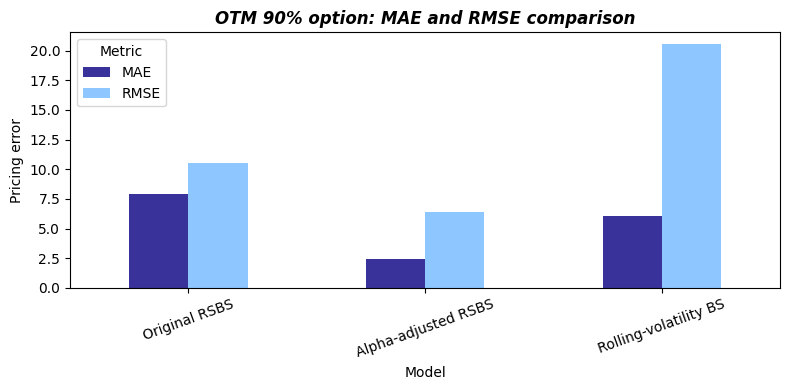

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


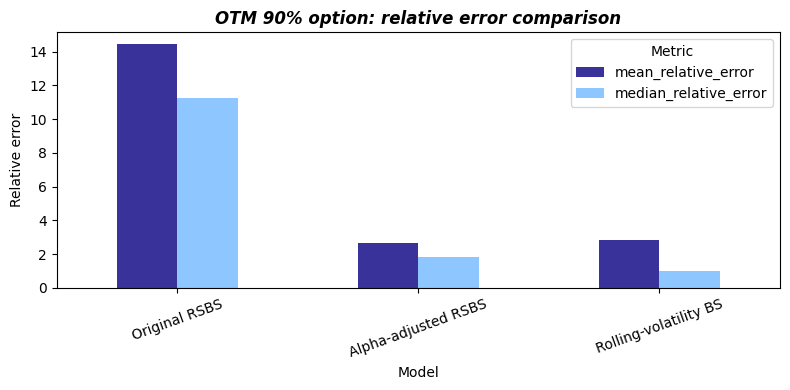

In [43]:
otm_alpha_summary = pd.DataFrame(
    [
        summarize_model_errors(
            valid_otm_alpha,
            "Original RSBS",
            "rs_price",
            "rs_error",
            "rs_abs_error",
            "rs_relative_error",
        ),
        summarize_model_errors(
            valid_otm_alpha,
            "Alpha-adjusted RSBS",
            "rs_price_alpha",
            "rs_error_alpha",
            "rs_abs_error_alpha",
            "rs_relative_error_alpha",
        ),
        summarize_model_errors(
            valid_otm_alpha,
            "Rolling-volatility BS",
            "bs_price",
            "bs_error",
            "bs_abs_error",
            "bs_relative_error",
        ),
    ]
)

display(otm_alpha_summary)


main_error_metrics = otm_alpha_summary.set_index("model")[["MAE", "RMSE"]]

fig, ax = plt.subplots(figsize=(8, 4))

main_error_metrics.plot(kind="bar", ax=ax)

ax.set_title(f"{OTM_LABEL} option: MAE and RMSE comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Pricing error")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metric")

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()


relative_error_metrics = otm_alpha_summary.set_index("model")[
    ["mean_relative_error", "median_relative_error"]
]

fig, ax = plt.subplots(figsize=(8, 4))

relative_error_metrics.plot(kind="bar", ax=ax)

ax.set_title(f"{OTM_LABEL} option: relative error comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Relative error")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metric")

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


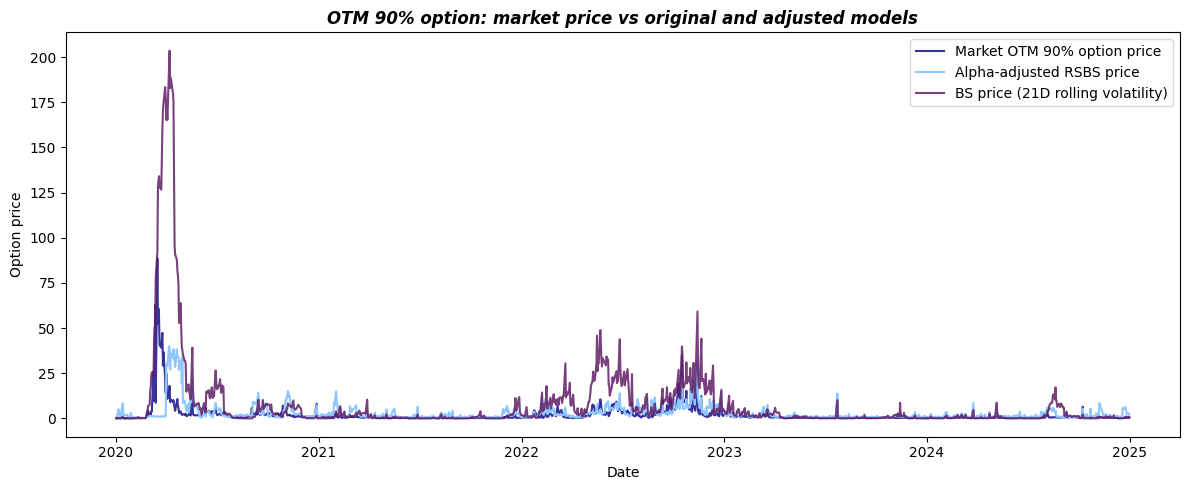

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.
findfont: Font family 'Gill Sans MT' not found.


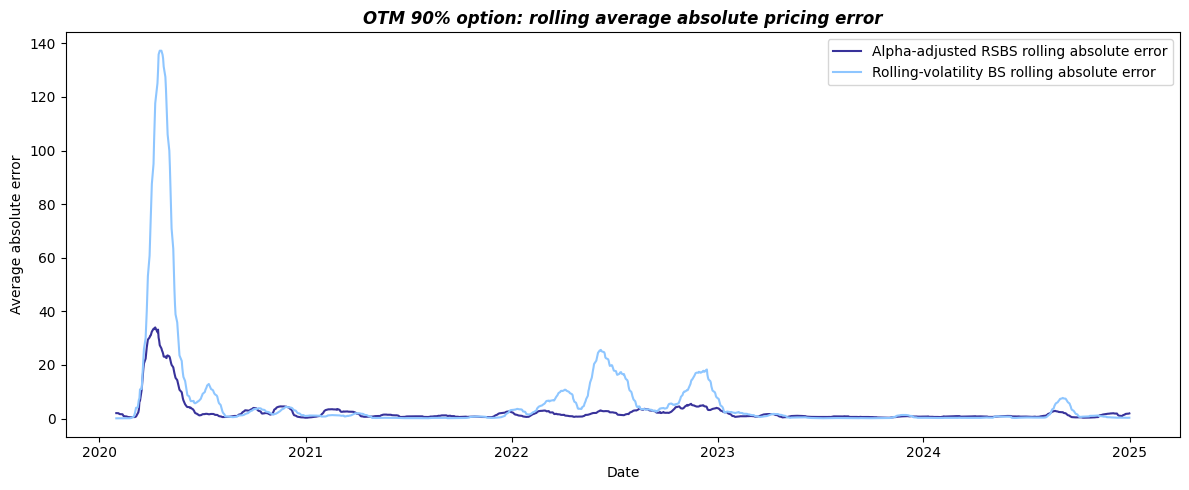

findfont: Font family 'Gill Sans MT' not found.
findfont: Font family ['Gill Sans MT'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Gill Sans MT' not found.


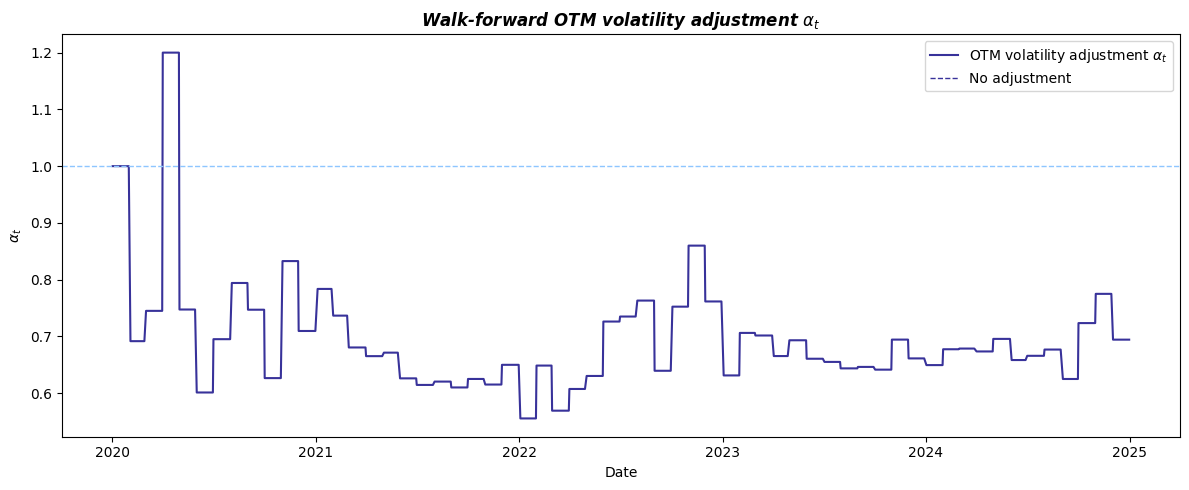

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["market_price"],
    label=f"Market {OTM_LABEL} option price",
)

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["rs_price_alpha"],
    label="Alpha-adjusted RSBS price",
)

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["bs_price"],
    label=f"BS price ({ROLLING_BS_WINDOW}D rolling volatility)",
    alpha=0.85,
)

ax.set_title(f"{OTM_LABEL} option: market price vs original and adjusted models")
ax.set_xlabel("Date")
ax.set_ylabel("Option price")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

valid_otm_alpha["rs_abs_error_alpha_roll"] = (
    valid_otm_alpha["rs_abs_error_alpha"]
    .rolling(ERROR_ROLLING_WINDOW)
    .mean()
)

valid_otm_alpha["bs_abs_error_roll"] = (
    valid_otm_alpha["bs_abs_error"]
    .rolling(ERROR_ROLLING_WINDOW)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["rs_abs_error_alpha_roll"],
    label="Alpha-adjusted RSBS rolling absolute error",
)

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["bs_abs_error_roll"],
    label="Rolling-volatility BS rolling absolute error",
)

ax.set_title(f"{OTM_LABEL} option: rolling average absolute pricing error")
ax.set_xlabel("Date")
ax.set_ylabel("Average absolute error")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    valid_otm_alpha["date"],
    valid_otm_alpha["alpha_otm_used"],
    label=r"OTM volatility adjustment $\alpha_t$",
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="No adjustment",
)

ax.set_title(r"Walk-forward OTM volatility adjustment $\alpha_t$")
ax.set_xlabel("Date")
ax.set_ylabel(r"$\alpha_t$")
ax.legend()

apply_bsic_colors_only(fig, ax)
plt.tight_layout()
plt.show()

## Threshold analysis

Since many OTM options have very low prices, relative errors can become extremely large even when the absolute error is small. As a robustness check, the comparison is repeated after excluding options whose market price is below different thresholds.

This helps distinguish genuine model misspecification from the mechanical effect of dividing by very small market prices.

In [45]:
threshold_results = []

for threshold in [0.5, 1.0, 2.0]:
    tmp = valid_otm_alpha[
        valid_otm_alpha["market_price"] >= threshold
    ].copy()

    threshold_results.append(
        summarize_model_errors(
            tmp,
            f"Original RSBS, market >= {threshold}",
            "rs_price",
            "rs_error",
            "rs_abs_error",
            "rs_relative_error",
        )
    )

    threshold_results.append(
        summarize_model_errors(
            tmp,
            f"Alpha-adjusted RSBS, market >= {threshold}",
            "rs_price_alpha",
            "rs_error_alpha",
            "rs_abs_error_alpha",
            "rs_relative_error_alpha",
        )
    )

    threshold_results.append(
        summarize_model_errors(
            tmp,
            f"Rolling BS, market >= {threshold}",
            "bs_price",
            "bs_error",
            "bs_abs_error",
            "bs_relative_error",
        )
    )

threshold_summary = pd.DataFrame(threshold_results)

display(threshold_summary)

,model,n_obs,MAE,RMSE,mean_error,median_error,mean_relative_error,median_relative_error,mean_model_price,mean_market_price
0,"Original RSBS, market >= 0.5",643,10.735256,13.545959,8.877564,8.628793,6.877922,4.896560,12.492665,3.615101
1,"Alpha-adjusted RSBS, market >= 0.5",643,3.917847,8.850322,1.060630,0.880953,1.586545,0.860329,4.675731,3.615101
2,"Rolling BS, market >= 0.5",643,11.150852,28.550417,10.671902,2.596509,3.172202,1.430029,14.287003,3.615101
3,"Original RSBS, market >= 1.0",429,12.399688,15.260637,9.615316,10.871229,4.791058,3.569745,14.685549,5.070233
4,"Alpha-adjusted RSBS, market >= 1.0",429,5.150959,10.724030,0.876241,0.886201,1.305355,0.679052,5.946474,5.070233
5,"Rolling BS, market >= 1.0",429,15.822115,34.869787,15.335366,5.484654,3.451243,2.026241,20.405599,5.070233
6,"Original RSBS, market >= 2.0",273,13.669090,16.896272,9.293648,11.478909,3.328720,2.524502,16.439436,7.145788
7,"Alpha-adjusted RSBS, market >= 2.0",273,6.686438,13.171442,0.058107,0.020697,1.065952,0.565777,7.203895,7.145788
8,"Rolling BS, market >= 2.0",273,22.259014,43.375192,21.681069,10.080077,3.623293,2.152325,28.826856,7.145788
